# Natural Language Processing (CS5803)
# PROJECT - MULTILABEL EMOTION CLASSIFIER
# GROUP MEMBERS
# RACHIT DESHPANDE (AI24MTECH11003)
# ADITYA SHINDE (AI24MTECH11004)
# SAURABH GANGWAR (AI24MTECh11008)

In this cell, we install all the necessary Python libraries required for the project. These include deep learning frameworks like PyTorch and Transformers, as well as essential tools for data manipulation (Pandas, NumPy) and machine learning (scikit-learn). Additionally, visualization libraries (Matplotlib, Seaborn), progress tracking (tqdm), model explainability (LIME), and HTTP requests handling (Requests) are also installed to ensure a smooth workflow.

In [5]:
pip install torch transformers pandas numpy scikit-learn matplotlib seaborn tqdm lime requests # Installing required modules

In this cell, we import all the essential libraries and modules necessary for model development, evaluation, and visualization. These include core libraries such as NumPy, Pandas, and OS, along with deep learning frameworks like PyTorch and Transformers. Additionally, utilities for data preprocessing, evaluation metrics, visualization, model interpretability (LIME), and various system operations are also imported to support a comprehensive and streamlined workflow.

In [6]:
import os  # Import os module for file operations
import pandas as pd  # Import pandas for data handling
import numpy as np  # Import numpy for numerical operations
import torch  # Import PyTorch for deep learning
import torch.nn as nn  # Import neural network modules
import torch.nn.functional as F  # Import functional operations
from torch.utils.data import Dataset, DataLoader  # Import dataset utilities
from sklearn.model_selection import train_test_split  # Import data splitting
from sklearn.metrics import f1_score, precision_score, recall_score, classification_report, hamming_loss, jaccard_score  # Import evaluation metrics
from torch.optim import AdamW  # Import AdamW optimizer
from transformers import AutoTokenizer, AutoModel, get_scheduler  # Import transformer utilities
import matplotlib.pyplot as plt  # Import plotting library
import seaborn as sns  # Import visualization library
from tqdm import tqdm  # Import progress bar
import lime  # Import LIME for explanations
from lime.lime_text import LimeTextExplainer  # Import text explainer
import random  # Import random utilities
import re  # Import regex module
import requests  # Import HTTP requests
from io import BytesIO  # Import byte stream
from zipfile import ZipFile  # Import ZIP handling
import torch.nn.init as init  # Import weight initialization
from matplotlib.colors import LinearSegmentedColormap  # Import colormap utilities
import warnings  # Import warning control
import shutil  # Import file operations
warnings.filterwarnings("ignore")  # Suppress warnings

In this cell, we define and invoke a function to set random seeds across various libraries to ensure reproducibility of results. We also configure PyTorch settings to enforce deterministic behavior for consistent model training. Additionally, we check for the availability of a GPU and set the computing device accordingly, displaying the selected device for verification.

In [7]:
# Set seeds for reproducibility
def set_seed(seed=42):  # Define seed function
    random.seed(seed)  # Set random seed
    np.random.seed(seed)  # Set numpy seed
    torch.manual_seed(seed)  # Set torch seed
    if torch.cuda.is_available():  # Check CUDA availability
        torch.cuda.manual_seed_all(seed)  # Set CUDA seed
    torch.backends.cudnn.deterministic = True  # Ensure deterministic
    torch.backends.cudnn.benchmark = False  # Disable benchmark

set_seed(42)  # Initialize seed

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # Select device
print(f"Using device: {device}")  # Display device

Using device: cuda


In this cell, we define a function to verify the structure and contents of a given ZIP file. The function checks whether all required CSV files for different data splits and languages are present within the archive. It provides detailed feedback on any missing files or confirms successful verification, ensuring that the dataset is correctly organized before further processing.

In [8]:
# Function to verify ZIP contents
def verify_zip_structure(zip_path):  # Define ZIP verification
    print(f"Verifying ZIP structure: {zip_path}")  # Log ZIP path
    required_files = [  # List required files
        f"SemEval2025-Task11-main/task-dataset/semeval-2025-task11-dataset/track_a/{split}/{lang}.csv"
        for split in ["train", "dev", "test"]  # Iterate splits
        for lang in ["eng", "hin", "mar"]  # Iterate languages
    ]

    try:  # Handle exceptions
        with ZipFile(zip_path, 'r') as zip_ref:  # Open ZIP file
            zip_files = zip_ref.namelist()  # Get file list
            missing_files = [f for f in required_files if f not in zip_files]  # Find missing files

            if missing_files:  # Check missing files
                print("\nMissing files in ZIP:")  # Log missing files
                for f in missing_files:  # Iterate missing files
                    print(f"  {f}")  # Display missing file
                return False  # Return failure
            else:  # All files present
                print("\nAll required CSV files found in ZIP:")  # Log success
                for f in required_files:  # Iterate required files
                    print(f"  {f}")  # Display found file
                return True  # Return success
    except Exception as e:  # Catch errors
        print(f"Error reading ZIP: {e}")  # Log error
        return False  # Return failure

In this cell, we define a function to verify the structure of the extracted dataset directory. The function checks whether all necessary CSV files for each split and language exist and are non-empty within the specified base directory. It provides clear feedback on any missing or empty files, helping ensure the dataset is correctly extracted and ready for further processing.

In [9]:
# Function to verify extracted directory structure
def verify_extracted_structure(base_dir="./data/track_a"):  # Define structure verification
    print(f"Verifying extracted dataset structure in {base_dir}...")  # Log base directory
    required_files = [  # List required files
        f"{base_dir}/{split}/{lang}/data.csv"
        for split in ["train", "dev", "test"]  # Iterate splits
        for lang in ["en", "hi", "mr"]  # Iterate languages
    ]

    missing_files = [f for f in required_files if not (os.path.exists(f) and os.path.getsize(f) > 0)]  # Find missing files

    if missing_files:  # Check missing files
        print("\nMissing or empty files:")  # Log missing files
        for f in missing_files:  # Iterate missing files
            print(f"  {f}")  # Display missing file
        return False  # Return failure
    else:  # All files present
        print("\nExtracted dataset structure is correct!")  # Log success
        print("Found files:")  # Log found files
        for f in required_files:  # Iterate required files
            print(f"  {f}")  # Display found file
        return True  # Return success

In this cell, we define a function to extract the required dataset files from a given ZIP archive. The function first verifies the ZIP structure, then extracts the contents to a temporary location, reorganizes the files according to the expected directory structure, and copies them to their appropriate locations. It also performs a final verification to ensure the extraction was successful and removes any temporary files created during the process.

In [10]:
# Function to extract CSV files from ZIP
def extract_dataset_from_zip(zip_path):  # Define ZIP extraction
    print(f"Extracting dataset from {zip_path}...")  # Log ZIP path
    try:  # Handle exceptions
        if not verify_zip_structure(zip_path):  # Verify ZIP structure
            print("ZIP file is missing required files.")  # Log missing files
            return False  # Return failure

        with ZipFile(zip_path, 'r') as zip_ref:  # Open ZIP file
            zip_ref.extractall("./data/tmp")  # Extract to temporary folder

        src_base = "./data/tmp/SemEval2025-Task11-main/task-dataset/semeval-2025-task11-dataset/track_a"  # Source path
        dst_base = "./data/track_a"  # Destination path

        lang_map = {"eng": "en", "hin": "hi", "mar": "mr"}  # Language mapping
        splits = ["train", "dev", "test"]  # Define splits

        for split in splits:  # Iterate splits
            for src_lang, dst_lang in lang_map.items():  # Iterate languages
                src_file = os.path.join(src_base, split, f"{src_lang}.csv")  # Source file path
                dst_dir = os.path.join(dst_base, split, dst_lang)  # Destination directory
                dst_file = os.path.join(dst_dir, "data.csv")  # Destination file path

                if os.path.exists(src_file):  # Check file existence
                    os.makedirs(dst_dir, exist_ok=True)  # Create directory
                    shutil.copy2(src_file, dst_file)  # Copy file
                    print(f"Copied {src_file} to {dst_file}")  # Log copy operation
                else:  # File not found
                    print(f"Warning: {src_file} not found in ZIP")  # Log warning

        shutil.rmtree("./data/tmp")  # Remove temporary folder
        print("Dataset extracted successfully!")  # Log success

        if not verify_extracted_structure():  # Verify extracted structure
            print("Extracted structure is incomplete.")  # Log incomplete structure
            return False  # Return failure
        return True  # Return success
    except Exception as e:  # Catch errors
        print(f"Failed to extract dataset: {e}")  # Log error
        return False  # Return failure

In this cell, we define a function to ensure that the required dataset files are properly available for a specified language. The function checks for the existence and completeness of the necessary CSV files and, if missing, attempts to extract them from the provided ZIP archive. It also handles verification of the extracted structure and provides clear prompts if manual intervention is needed, ensuring a smooth dataset preparation process.

In [11]:
# Check and extract dataset
def ensure_dataset(zip_path, language='en'):  # Define dataset check
    required_files = [  # List required files
        f"./data/track_a/{split}/{language}/data.csv"
        for split in ["train", "dev", "test"]  # Iterate splits
    ]
    all_files_exist = all(os.path.exists(f) and os.path.getsize(f) > 0 for f in required_files)  # Check file existence

    if not all_files_exist:  # Files missing
        print(f"Some dataset files for language {language} are missing or empty.")  # Log missing files
        if not os.path.exists(zip_path):  # Check ZIP existence
            print(f"ZIP file not found at {zip_path}. Please download SemEval2025-Task11-main.zip from "
                  "https://github.com/emotion-analysis-project/SemEval2025-Task11 and specify the correct path.")  # Log download instruction
            return False  # Return failure
        success = extract_dataset_from_zip(zip_path)  # Extract dataset
        if not success:  # Extraction failed
            print("Dataset extraction failed.")  # Log failure
            return False  # Return failure
    else:  # Files exist
        if not verify_extracted_structure():  # Verify structure
            print("Existing dataset structure is incomplete. Attempting to re-extract...")  # Log incomplete structure
            success = extract_dataset_from_zip(zip_path)  # Re-extract dataset
            if not success:  # Extraction failed
                print("Dataset extraction failed.")  # Log failure
                return False  # Return failure
    return True  # Return success

In this cell, we define functions to load and prepare the emotion classification dataset across different languages. The translate_text function ensures that texts are left unchanged for Hindi and Marathi while marking translations for other languages. The load_dataset function loads the dataset for the specified language, handles missing or non-numeric emotion labels, aligns the data structure across languages by adding missing emotion columns if needed, and optionally augments the dataset with translated English data. It concludes by displaying the dataset's shape, column names, and class distribution, ensuring that the data is ready for model training.

In [12]:
# Modified translate_text function to fix Hindi output
def translate_text(text, source_lang, target_lang):  # Define text translation
    if source_lang == target_lang or target_lang in ['hi', 'mr']:  # Check language match
        return text  # Return original text
    return f"[{target_lang}] {text}"  # Add language tag

# Modified load_dataset to handle emotion columns per language
def load_dataset(language='en', augment_with_translations=False, languages=None, all_emotion_cols=None):  # Define dataset loader
    splits = ["train", "dev"]  # Define splits
    all_dfs = []  # Initialize dataframes list

    for split in splits:  # Iterate splits
        csv_file = f"./data/track_a/{split}/{language}/data.csv"  # Define CSV path
        if not os.path.exists(csv_file):  # Check file existence
            print(f"File not found: {csv_file}")  # Log missing file
            return None  # Return None

        df = pd.read_csv(csv_file)  # Read CSV file
        all_dfs.append(df)  # Append dataframe

    combined_df = pd.concat(all_dfs, ignore_index=True)  # Concatenate dataframes

    # Extract emotion columns
    emotion_cols = [col for col in combined_df.columns if col not in ['id', 'text']]  # Identify emotion columns

    # Handle NaN and non-numeric values
    for col in emotion_cols:  # Iterate emotion columns
        if combined_df[col].isna().any():  # Check for NaN
            print(f"Warning: NaN values found in {col} for language {language}. Filling with 0.")  # Log NaN warning
            combined_df[col] = combined_df[col].fillna(0)  # Fill NaN with 0
        if not pd.api.types.is_numeric_dtype(combined_df[col]):  # Check numeric type
            print(f"Warning: Non-numeric values in {col} for language {language}. Converting to numeric.")  # Log non-numeric warning
            combined_df[col] = pd.to_numeric(combined_df[col], errors='coerce').fillna(0)  # Convert to numeric
        combined_df[col] = combined_df[col].clip(0, 1).astype(int)  # Clip and convert to int

    if all_emotion_cols:  # Check for predefined emotions
        for col in all_emotion_cols:  # Iterate all emotions
            if col not in combined_df.columns:  # Check missing column
                print(f"Adding missing emotion {col} for language {language} with zeros.")  # Log missing emotion
                combined_df[col] = 0  # Add zero column
        emotion_cols = all_emotion_cols  # Update emotion columns
        combined_df = combined_df[['id', 'text'] + emotion_cols]  # Reorder columns

    if augment_with_translations and language != 'en' and languages:  # Check augmentation
        en_df = []  # Initialize English dataframes
        for split in splits:  # Iterate splits
            en_csv = f"./data/track_a/{split}/en/data.csv"  # Define English CSV
            if os.path.exists(en_csv):  # Check file existence
                df = pd.read_csv(en_csv)  # Read English CSV
                for col in emotion_cols:  # Iterate emotion columns
                    if col in df.columns:  # Check column existence
                        if df[col].isna().any():  # Check for NaN
                            print(f"Warning: NaN values in {col} for English augmentation. Filling with 0.")  # Log NaN warning
                            df[col] = df[col].fillna(0)  # Fill NaN with 0
                        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).clip(0, 1).astype(int)  # Convert and clip
                    else:  # Missing column
                        df[col] = 0  # Add zero column
                en_df.append(df)  # Append dataframe
        if en_df:  # Check English data
            en_df = pd.concat(en_df, ignore_index=True)  # Concatenate English data
            en_df['text'] = en_df['text'].apply(lambda x: translate_text(x, 'en', language))  # Translate text
            for col in emotion_cols:  # Iterate emotion columns
                if col not in en_df.columns:  # Check missing column
                    en_df[col] = 0  # Add zero column
            en_df = en_df[['id', 'text'] + emotion_cols]  # Reorder columns
            combined_df = pd.concat([combined_df, en_df], ignore_index=True)  # Combine dataframes

    print(f"\nDataset for language '{language}':")  # Log dataset info
    print(f"Shape: {combined_df.shape}")  # Log dataset shape
    print("Columns:", combined_df.columns.tolist())  # Log column names
    print("\nClass distribution:")  # Log class distribution
    for emotion in emotion_cols:  # Iterate emotions
        count = combined_df[emotion].sum()  # Calculate count
        print(f"{emotion}: {count} ({count/len(combined_df):.2%})")  # Log distribution

    return combined_df, emotion_cols  # Return dataset and emotions

In this cell, we define the EmotionDataset class to prepare text and emotion label data for model training. The class tokenizes the input texts using the provided tokenizer, ensures that each input is padded or truncated to a fixed maximum length, and returns the input IDs, attention masks, and labels as PyTorch tensors. This structured format makes it easy to efficiently batch and load the data during training and evaluation.

In [13]:
# Custom Dataset class
class EmotionDataset(Dataset):  # Define dataset class
    def __init__(self, texts, labels, tokenizer, max_length=128):  # Initialize dataset
        self.texts = texts  # Store texts
        self.labels = labels  # Store labels
        self.tokenizer = tokenizer  # Store tokenizer
        self.max_length = max_length  # Store max length

    def __len__(self):  # Define length
        return len(self.texts)  # Return text count

    def __getitem__(self, idx):  # Define item access
        text = str(self.texts[idx])  # Get text
        label = self.labels[idx]  # Get label

        encoding = self.tokenizer(  # Tokenize text
            text,
            add_special_tokens=True,  # Add special tokens
            max_length=self.max_length,  # Set max length
            padding='max_length',  # Pad to max length
            truncation=True,  # Truncate if needed
            return_attention_mask=True,  # Return attention mask
            return_tensors='pt'  # Return PyTorch tensors
        )

        return {  # Return encoded data
            'input_ids': encoding['input_ids'].flatten().to(device),  # Flatten input IDs
            'attention_mask': encoding['attention_mask'].flatten().to(device),  # Flatten attention mask
            'labels': torch.FloatTensor(label).to(device)  # Convert labels to tensor
        }

In this cell, the EmotionClassifier model is defined for multilabel emotion classification. The model leverages a pretrained transformer (like BERT or RoBERTa) for extracting contextualized embeddings from the input text. These embeddings are passed through a bidirectional LSTM layer to capture sequential dependencies, followed by an attention mechanism to weigh important parts of the sequence. The output of the attention mechanism is passed through a classifier to predict emotion labels. Dropout layers are included to prevent overfitting, and the model is initialized with Xavier initialization for better convergence.

In [14]:
# Modified transformers model for multilabel classification
class EmotionClassifier(nn.Module):  # Define classifier model
    def __init__(self, model_name, num_labels, dropout_prob=0.1):  # Initialize model
        super(EmotionClassifier, self).__init__()  # Initialize parent class
        self.transformer = AutoModel.from_pretrained(model_name).to(device)  # Load transformer
        self.dropout = nn.Dropout(dropout_prob)  # Add dropout layer

        hidden_size = self.transformer.config.hidden_size  # Get hidden size

        self.lstm = nn.LSTM(  # Define LSTM layer
            input_size=hidden_size,  # Set input size
            hidden_size=hidden_size // 2,  # Set hidden size
            num_layers=2,  # Set number of layers
            batch_first=True,  # Set batch first
            bidirectional=True,  # Enable bidirectional
            dropout=dropout_prob if 2 > 1 else 0  # Add dropout
        ).to(device)  # Move to device

        self.attention = nn.Sequential(  # Define attention mechanism
            nn.Linear(hidden_size, hidden_size),  # Linear layer
            nn.Tanh(),  # Tanh activation
            nn.Linear(hidden_size, 1, bias=False),  # Linear layer
            nn.Softmax(dim=1)  # Softmax activation
        ).to(device)  # Move to device

        self.classifier = nn.Sequential(  # Define classifier
            nn.Linear(hidden_size, hidden_size // 2),  # Linear layer
            nn.ReLU(),  # ReLU activation
            nn.Dropout(dropout_prob),  # Add dropout
            nn.Linear(hidden_size // 2, num_labels)  # Output layer
        ).to(device)  # Move to device

        self._init_weights(self.classifier)  # Initialize classifier weights
        self._init_weights(self.attention)  # Initialize attention weights

    def _init_weights(self, module):  # Define weight initialization
        if isinstance(module, nn.Linear):  # Check linear layer
            init.xavier_uniform_(module.weight)  # Apply Xavier initialization
            if module.bias is not None:  # Check for bias
                init.zeros_(module.bias)  # Initialize bias to zero

    def forward(self, input_ids, attention_mask, return_attentions=False):  # Define forward pass
        outputs = self.transformer(  # Run transformer
            input_ids=input_ids,  # Pass input IDs
            attention_mask=attention_mask  # Pass attention mask
        )

        hidden_states = outputs.last_hidden_state  # Get hidden states

        lstm_out, _ = self.lstm(hidden_states)  # Run LSTM

        attention_weights = self.attention(lstm_out)  # Compute attention weights
        context_vector = torch.sum(attention_weights * lstm_out, dim=1)  # Compute context vector

        pooled_output = self.dropout(context_vector)  # Apply dropout
        logits = self.classifier(pooled_output)  # Compute logits

        if return_attentions:  # Check for attentions
            return logits, attention_weights, None  # Return with attentions

        return logits  # Return logits

In this cell, we define the FocalLoss class, which is designed to handle class imbalance in binary classification tasks. By modifying the standard binary cross-entropy (BCE) loss, it applies a modulating factor that focuses more on hard-to-classify examples, especially when they are underrepresented. The class allows tuning via the alpha and gamma parameters, where alpha adjusts the weight of each class and gamma determines how much emphasis to place on misclassified examples. This implementation helps improve model performance in scenarios with highly imbalanced data.

In [15]:
# Custom Focal Loss
class FocalLoss(nn.Module):  # Define focal loss
    def __init__(self, alpha=1, gamma=2, reduction='mean'):  # Initialize loss
        super(FocalLoss, self).__init__()  # Initialize parent class
        self.alpha = alpha  # Store alpha
        self.gamma = gamma  # Store gamma
        self.reduction = reduction  # Store reduction
        self.eps = 1e-8  # Store epsilon

    def forward(self, inputs, targets):  # Define forward pass
        BCE_loss = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')  # Compute BCE loss
        pt = torch.exp(-BCE_loss)  # Compute probability
        F_loss = self.alpha * (1 - pt + self.eps) ** self.gamma * BCE_loss  # Compute focal loss
        F_loss = torch.clamp(F_loss, min=-1e10, max=1e10)  # Clamp loss values
        if torch.isnan(F_loss).any():  # Check for NaN
            print("Warning: NaN detected in FocalLoss")  # Log NaN warning
        if self.reduction == 'mean':  # Check mean reduction
            return F_loss.mean()  # Return mean loss
        elif self.reduction == 'sum':  # Check sum reduction
            return F_loss.sum()  # Return sum loss
        else:  # No reduction
            return F_loss  # Return loss

In this cell, we define the WeightedBCELoss class, which modifies the standard binary cross-entropy (BCE) loss to handle class imbalances by introducing class-specific weights. The weights are computed based on the number of samples per class, ensuring that underrepresented classes are given more importance during training. This weighted approach helps the model focus more on minority classes, improving the model's ability to correctly classify examples from those classes. By normalizing the weights, we ensure that the total loss remains balanced.

In [16]:
# Weighted BCE Loss
class WeightedBCELoss(nn.Module):  # Define weighted BCE
    def __init__(self, samples_per_class):  # Initialize loss
        super(WeightedBCELoss, self).__init__()  # Initialize parent class
        weights = torch.tensor([1.0 / (s + 1e-10) for s in samples_per_class], dtype=torch.float32).to(device)  # Compute weights
        self.weights = weights / (weights.sum() + 1e-10) * len(samples_per_class)  # Normalize weights
        self.eps = 1e-8  # Store epsilon

    def forward(self, inputs, targets):  # Define forward pass
        bce = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')  # Compute BCE loss
        weighted_bce = bce * self.weights[None, :]  # Apply weights
        weighted_bce = torch.clamp(weighted_bce, min=-1e10, max=1e10)  # Clamp loss values
        if torch.isnan(weighted_bce).any():  # Check for NaN
            print("Warning: NaN detected in WeightedBCELoss")  # Log NaN warning
        return weighted_bce.mean()  # Return mean loss

In this cell, the CometInspiredLoss class is defined, inspired by the COMET (Cross-lingual Emotion Transfer) framework. It combines focal loss with weighted loss based on class distribution across multiple languages. The loss adapts to imbalances by applying a language-specific weight, which is calculated by considering the sample count for each class in each language. The focal loss term is used to focus more on hard-to-classify examples, and the weighted loss ensures that the model places appropriate emphasis on different languages and their respective class distributions. This helps improve the model's performance across diverse linguistic contexts.

In [17]:
# COMET-inspired Multilingual Loss
class CometInspiredLoss(nn.Module):  # Define COMET loss
    def __init__(self, samples_per_class_per_lang, languages, alpha=2, gamma=2):  # Initialize loss
        super(CometInspiredLoss, self).__init__()  # Initialize parent class
        self.focal_loss = FocalLoss(alpha=alpha, gamma=gamma)  # Initialize focal loss
        self.languages = languages  # Store languages
        self.eps = 1e-8  # Store epsilon
        weights = []  # Initialize weights list
        for lang_samples in samples_per_class_per_lang:  # Iterate language samples
            lang_weights = torch.tensor([1.0 / (s + self.eps) for s in lang_samples], dtype=torch.float32)  # Compute weights
            weights.append(lang_weights / (lang_weights.sum() + self.eps) * len(lang_samples))  # Normalize weights
        self.weights = torch.stack(weights).mean(dim=0).to(device)  # Average weights
        self.weights = torch.clamp(self.weights, min=self.eps, max=1e10)  # Clamp weights

    def forward(self, inputs, targets):  # Define forward pass
        focal_loss = self.focal_loss(inputs, targets)  # Compute focal loss
        weighted_loss = focal_loss * self.weights[None, :]  # Apply weights
        if torch.isnan(weighted_loss).any():  # Check for NaN
            print("Warning: NaN detected in CometInspiredLoss")  # Log NaN warning
        return weighted_loss.mean()  # Return mean loss

In this cell, the AsymmetricFocalLoss class is introduced, designed to address class imbalance in binary classification tasks, particularly in the case of English language data. The loss function is asymmetric, meaning it applies different levels of focus on positive and negative examples through distinct gamma_pos and gamma_neg values. The alpha parameter allows for scaling the positive class, helping to further balance the contribution of the positive and negative samples. The loss combines two components: one for the positive class and one for the negative class, with each part weighted differently based on the parameters. This specialized loss helps the model focus more on hard-to-classify negative samples while balancing the contribution of positive examples.

In [18]:
# Asymmetric Focal Loss for English
class AsymmetricFocalLoss(nn.Module):  # Define asymmetric loss
    def __init__(self, gamma_pos=1, gamma_neg=3, alpha=0.25, reduction='mean'):  # Initialize loss
        super(AsymmetricFocalLoss, self).__init__()  # Initialize parent class
        self.gamma_pos = gamma_pos  # Store positive gamma
        self.gamma_neg = gamma_neg  # Store negative gamma
        self.alpha = alpha  # Store alpha
        self.reduction = reduction  # Store reduction
        self.eps = 1e-8  # Store epsilon

    def forward(self, inputs, targets):  # Define forward pass
        probs = torch.sigmoid(inputs)  # Compute probabilities
        probs = torch.clamp(probs, min=self.eps, max=1 - self.eps)  # Clamp probabilities
        loss_pos = -self.alpha * (1 - probs) ** self.gamma_pos * targets * torch.log(probs)  # Positive loss
        loss_neg = -(1 - self.alpha) * probs ** self.gamma_neg * (1 - targets) * torch.log(1 - probs)  # Negative loss
        loss = loss_pos + loss_neg  # Combine losses
        loss = torch.clamp(loss, min=-1e10, max=1e10)  # Clamp loss values
        if torch.isnan(loss).any():  # Check for NaN
            print("Warning: NaN detected in AsymmetricFocalLoss")  # Log NaN warning
        if self.reduction == 'mean':  # Check mean reduction
            return loss.mean()  # Return mean loss
        elif self.reduction == 'sum':  # Check sum reduction
            return loss.sum()  # Return sum loss
        else:  # No reduction
            return loss  # Return loss

In this cell, the train_epoch function is implemented to train the model for one epoch. It sets the model to training mode and initializes a progress bar to track the training process. For each batch in the data loader, it performs the following steps: it clears the gradients, retrieves the inputs (input IDs, attention mask) and labels, performs a forward pass through the model, computes the loss, and checks for any NaN values in the loss (skipping the batch if NaN is detected). Then, it performs backpropagation, clips gradients to avoid exploding gradients, updates the model parameters, and steps through the learning rate scheduler. The function returns the average loss for the epoch, providing an indication of how well the model is learning.

In [19]:
# Training function
def train_epoch(model, data_loader, optimizer, scheduler, loss_fn):  # Define training epoch
    model.train()  # Set training mode
    total_loss = 0  # Initialize total loss
    progress_bar = tqdm(data_loader, desc="Training")  # Initialize progress bar
    for batch in progress_bar:  # Iterate batches
        optimizer.zero_grad()  # Clear gradients

        input_ids = batch['input_ids'].to(device)  # Get input IDs
        attention_mask = batch['attention_mask'].to(device)  # Get attention mask
        labels = batch['labels'].to(device)  # Get labels

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)  # Forward pass
        loss = loss_fn(outputs, labels)  # Compute loss

        if torch.isnan(loss):  # Check for NaN
            print("Warning: NaN loss detected, skipping batch")  # Log NaN warning
            continue  # Skip batch

        total_loss += loss.item()  # Accumulate loss
        loss.backward()  # Backpropagate
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # Clip gradients
        optimizer.step()  # Update weights
        scheduler.step()  # Update scheduler

        progress_bar.set_postfix({'loss': loss.item()})  # Update progress bar

    return total_loss / len(data_loader)  # Return average loss

In this cell, the evaluate function is defined to assess the model's performance on a validation or test dataset. The model is switched to evaluation mode, and gradients are turned off for efficiency. For each batch, the function computes the forward pass, calculates the loss, and collects the predictions and true labels. After processing the entire dataset, several evaluation metrics such as F1 score, precision, recall, Hamming loss, and Jaccard score are computed. A classification report is generated, and the function returns these metrics, the classification report, and the predictions and labels for further analysis.

In [20]:
# Evaluation function
def evaluate(model, data_loader, loss_fn, emotion_labels):  # Define evaluation
    model.eval()  # Set evaluation mode
    val_loss = 0  # Initialize validation loss
    all_preds = []  # Initialize predictions
    all_labels = []  # Initialize labels

    with torch.no_grad():  # Disable gradients
        for batch in tqdm(data_loader, desc="Evaluating"):  # Iterate batches
            input_ids = batch['input_ids'].to(device)  # Get input IDs
            attention_mask = batch['attention_mask'].to(device)  # Get attention mask
            labels = batch['labels'].to(device)  # Get labels

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)  # Forward pass
            loss = loss_fn(outputs, labels)  # Compute loss
            val_loss += loss.item()  # Accumulate loss

            probs = torch.sigmoid(outputs)  # Compute probabilities
            preds = (probs >= 0.5).float().cpu().numpy()  # Binarize predictions
            labels_np = labels.cpu().numpy()  # Convert labels to numpy

            all_preds.extend(preds)  # Append predictions
            all_labels.extend(labels_np)  # Append labels

    all_preds = np.array(all_preds)  # Convert to array
    all_labels = np.array(all_labels)  # Convert to array

    if np.isnan(all_labels).any():  # Check for NaN
        print("Error: NaN values in true labels during evaluation")  # Log NaN error
        raise ValueError("Input y_true contains NaN")  # Raise error

    f1_macro = f1_score(all_labels, all_preds, average='macro')  # Compute F1 score
    precision_macro = precision_score(all_labels, all_preds, average='macro', zero_division=0)  # Compute precision
    recall_macro = recall_score(all_labels, all_preds, average='macro', zero_division=0)  # Compute recall
    hamming = hamming_loss(all_labels, all_preds)  # Compute Hamming loss
    jaccard = jaccard_score(all_labels, all_preds, average='samples')  # Compute Jaccard score

    report = classification_report(all_labels, all_preds, target_names=emotion_labels, zero_division=0)  # Generate report

    metrics = {  # Define metrics dictionary
        'val_loss': val_loss / len(data_loader),  # Store validation loss
        'f1_macro': f1_macro,  # Store F1 score
        'precision_macro': precision_macro,  # Store precision
        'recall_macro': recall_macro,  # Store recall
        'hamming_loss': hamming,  # Store Hamming loss
        'jaccard_score': jaccard  # Store Jaccard score
    }

    return metrics, report, all_preds, all_labels  # Return results

In this cell, the explain_with_lime function is defined to provide explanations for a model's predictions using LIME (Local Interpretable Model-agnostic Explanations). It takes a text input, tokenizes it, and uses a custom predict_proba function to predict probabilities for each emotion label. LIME then generates an explanation for the model's prediction by highlighting the most important features (e.g., words or tokens) for each label. The function returns the explanations as a dictionary, with each emotion label associated with its corresponding explanation, and the LIME explanation object for further analysis.

In [21]:
# LIME explainer
def explain_with_lime(model, tokenizer, text, emotion_labels, num_features=10):  # Define LIME explainer
    def predict_proba(texts):  # Define prediction function
        model.eval()  # Set evaluation mode
        results = []  # Initialize results

        for text in texts:  # Iterate texts
            encoding = tokenizer(  # Tokenize text
                text,
                add_special_tokens=True,  # Add special tokens
                max_length=128,  # Set max length
                padding='max_length',  # Pad to max length
                truncation=True,  # Truncate if needed
                return_attention_mask=True,  # Return attention mask
                return_tensors='pt'  # Return tensors
            )

            input_ids = encoding['input_ids'].to(device)  # Get input IDs
            attention_mask = encoding['attention_mask'].to(device)  # Get attention mask

            with torch.no_grad():  # Disable gradients
                outputs = model(input_ids=input_ids, attention_mask=attention_mask)  # Forward pass
                probs = torch.sigmoid(outputs).cpu().numpy()[0]  # Compute probabilities

                result = np.stack([(1 - probs), probs], axis=1)  # Stack probabilities
                results.append(result.flatten())  # Append result

        return np.array(results)  # Return probabilities

    explainer = LimeTextExplainer(class_names=emotion_labels)  # Initialize explainer

    exp = explainer.explain_instance(  # Explain instance
        text,
        predict_proba,
        num_features=num_features,  # Set number of features
        num_samples=500,  # Set number of samples
        labels=range(len(emotion_labels))  # Set labels
    )

    explanations = {}  # Initialize explanations
    for i, emotion in enumerate(emotion_labels):  # Iterate emotions
        explanations[emotion] = exp.as_list(label=i)  # Store explanation

    return explanations, exp  # Return results

In this cell, the visualize_attention function is defined to visualize the attention weights of a transformer model for a given input text. It first tokenizes and encodes the text using the tokenizer, and then passes the encoded input through the model to obtain the attention weights. A heatmap is generated to show the attention weights for each token in the input text, with the color intensity indicating the level of attention. The plot is annotated with the predicted probabilities for each emotion label. This visualization helps in understanding how the model attends to different tokens while making predictions.

In [22]:
# Attention visualization
def visualize_attention(model, tokenizer, text, emotion_labels):  # Define attention visualization
    tokens = tokenizer.tokenize(tokenizer.decode(tokenizer.encode(text)))  # Tokenize text

    encoding = tokenizer(  # Encode text
        text,
        add_special_tokens=True,  # Add special tokens
        max_length=128,  # Set max length
        padding='max_length',  # Pad to max length
        truncation=True,  # Truncate if needed
        return_attention_mask=True,  # Return attention mask
        return_tensors='pt'  # Return tensors
    )

    input_ids = encoding['input_ids'].to(device)  # Get input IDs
    attention_mask = encoding['attention_mask'].to(device)  # Get attention mask

    model.eval()  # Set evaluation mode
    with torch.no_grad():  # Disable gradients
        logits, attn_weights, _ = model(  # Forward pass
            input_ids=input_ids,
            attention_mask=attention_mask,
            return_attentions=True  # Return attentions
        )

        probs = torch.sigmoid(logits).cpu().numpy()[0]  # Compute probabilities

    fig, ax = plt.subplots(figsize=(10, 5))  # Create figure
    colors = [(1, 1, 1), (0, 0, 1)]  # Define colors
    cmap = LinearSegmentedColormap.from_list("white_to_blue", colors, N=100)  # Create colormap

    attn = attn_weights.cpu().numpy()[0][:len(tokens)]  # Get attention weights

    df = pd.DataFrame({'Token': tokens, 'Weight': attn.flatten()})  # Create dataframe
    df = df.set_index('Token')  # Set index

    sns.heatmap(df.T, cmap=cmap, ax=ax, cbar=True)  # Plot heatmap
    ax.set_title(f"Attention Weights (Probabilities: {', '.join([f'{e}: {p:.2f}' for e, p in zip(emotion_labels, probs)])})")  # Set title
    ax.set_xlabel('Tokens')  # Set x-label
    ax.set_yticklabels([])  # Clear y-ticks

    plt.tight_layout()  # Adjust layout
    return fig  # Return figure

The train_multilingual function trains a transformer model on multiple languages, ensuring the dataset for each language is loaded and augmented with translations if necessary. It splits the data into training, validation, and test sets, using custom datasets and data loaders. The function supports different loss functions like focal, weighted BCE, and COMET-inspired. After training, it evaluates the model on the test set, logs metrics, and visualizes training progress, confusion matrices, and attention weights. Interpretability is further explored using LIME for selected sample texts. The best model is saved based on the highest F1 score.

In [23]:
# Modified multilingual training function
def train_multilingual(languages, model_name="bert-base-multilingual-uncased", num_epochs=5, batch_size=16, learning_rate=2e-5, loss_type='focal'):  # Define multilingual training
    print(f"\n{'='*50}")  # Print separator
    print(f"Training multilingual model for languages: {', '.join(languages)}")  # Log languages
    print(f"Using model: {model_name}")  # Log model name
    print(f"Loss function: {loss_type}")  # Log loss type
    print(f"{'='*50}")  # Print separator

    ZIP_PATH = "/content/SemEval2025-Task11-main.zip"  # Define ZIP path
    combined_data = []  # Initialize combined data
    all_emotion_cols = set()  # Initialize emotion set
    samples_per_class_per_lang = []  # Initialize samples list

    for language in languages:  # Iterate languages
        if not ensure_dataset(ZIP_PATH, language):  # Ensure dataset
            return None  # Return None
        data, emotion_cols = load_dataset(language, augment_with_translations=False)  # Load dataset
        if data is None:  # Check data
            return None  # Return None
        all_emotion_cols.update(emotion_cols)  # Update emotions

    all_emotion_cols = sorted(list(all_emotion_cols))  # Sort emotions

    for language in languages:  # Iterate languages
        data, _ = load_dataset(  # Load dataset
            language,
            augment_with_translations=True,  # Enable augmentation
            languages=languages,  # Pass languages
            all_emotion_cols=all_emotion_cols  # Pass emotions
        )
        if data is None:  # Check data
            return None  # Return None
        combined_data.append(data)  # Append data
        samples_per_class = [data[emotion].sum() for emotion in all_emotion_cols]  # Compute samples
        samples_per_class_per_lang.append(samples_per_class)  # Append samples

    data = pd.concat(combined_data, ignore_index=True)  # Concatenate data

    train_df, test_df = train_test_split(data, test_size=0.2, random_state=42)  # Split train-test
    train_df, val_df = train_test_split(train_df, test_size=0.1, random_state=42)  # Split train-val

    print(f"Training set: {len(train_df)} samples")  # Log train size
    print(f"Validation set: {len(val_df)} samples")  # Log validation size
    print(f"Test set: {len(test_df)} samples")  # Log test size

    samples_per_class = [train_df[emotion].sum() for emotion in all_emotion_cols]  # Compute samples

    tokenizer = AutoTokenizer.from_pretrained(model_name)  # Load tokenizer

    train_dataset = EmotionDataset(  # Create train dataset
        train_df['text'].values,
        train_df[all_emotion_cols].values,
        tokenizer
    )

    val_dataset = EmotionDataset(  # Create validation dataset
        val_df['text'].values,
        val_df[all_emotion_cols].values,
        tokenizer
    )

    test_dataset = EmotionDataset(  # Create test dataset
        test_df['text'].values,
        test_df[all_emotion_cols].values,
        tokenizer
    )

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)  # Create train loader
    val_loader = DataLoader(val_dataset, batch_size=batch_size)  # Create validation loader
    test_loader = DataLoader(test_dataset, batch_size=batch_size)  # Create test loader

    model = EmotionClassifier(model_name, len(all_emotion_cols)).to(device)  # Initialize model

    optimizer = AdamW(model.parameters(), lr=learning_rate, weight_decay=0.01)  # Initialize optimizer

    total_steps = len(train_loader) * num_epochs  # Compute total steps

    scheduler = get_scheduler(  # Initialize scheduler
        "linear",
        optimizer=optimizer,
        num_warmup_steps=int(0.1 * total_steps),  # Set warmup steps
        num_training_steps=total_steps  # Set total steps
    )

    if loss_type == 'focal':  # Check focal loss
        loss_fn = FocalLoss(alpha=2, gamma=2)  # Initialize focal loss
    elif loss_type == 'weighted_bce':  # Check weighted BCE
        loss_fn = WeightedBCELoss(samples_per_class)  # Initialize weighted BCE
    elif loss_type == 'comet':  # Check COMET loss
        loss_fn = CometInspiredLoss(samples_per_class_per_lang, languages)  # Initialize COMET loss
    else:  # Unknown loss
        raise ValueError(f"Unknown loss type: {loss_type}")  # Raise error

    best_f1 = 0  # Initialize best F1
    best_model_state = None  # Initialize best model
    training_history = {'train_loss': [], 'val_loss': [], 'f1_macro': [], 'precision_macro': [], 'recall_macro': [], 'hamming_loss': [], 'jaccard_score': []}  # Initialize history

    for epoch in range(num_epochs):  # Iterate epochs
        print(f"\nEpoch {epoch+1}/{num_epochs}")  # Log epoch
        train_loss = train_epoch(model, train_loader, optimizer, scheduler, loss_fn)  # Train epoch
        training_history['train_loss'].append(train_loss)  # Store train loss

        val_metrics, val_report, _, _ = evaluate(model, val_loader, loss_fn, all_emotion_cols)  # Evaluate

        training_history['val_loss'].append(val_metrics['val_loss'])  # Store validation loss
        training_history['f1_macro'].append(val_metrics['f1_macro'])  # Store F1 score
        training_history['precision_macro'].append(val_metrics['precision_macro'])  # Store precision
        training_history['recall_macro'].append(val_metrics['recall_macro'])  # Store recall
        training_history['hamming_loss'].append(val_metrics['hamming_loss'])  # Store Hamming loss
        training_history['jaccard_score'].append(val_metrics['jaccard_score'])  # Store Jaccard score

        print(f"Train Loss: {train_loss:.4f}")  # Log train loss
        print(f"Val Loss: {val_metrics['val_loss']:.4f}")  # Log validation loss
        print(f"F1 Macro: {val_metrics['f1_macro']:.4f}")  # Log F1 score
        print(f"Precision Macro: {val_metrics['precision_macro']:.4f}")  # Log precision
        print(f"Recall Macro: {val_metrics['recall_macro']:.4f}")  # Log recall
        print(f"Hamming Loss: {val_metrics['hamming_loss']:.4f}")  # Log Hamming loss
        print(f"Jaccard Score: {val_metrics['jaccard_score']:.4f}")  # Log Jaccard score

        if val_metrics['f1_macro'] > best_f1:  # Check best F1
            best_f1 = val_metrics['f1_macro']  # Update best F1
            best_model_state = model.state_dict().copy()  # Save model state
            print(f"New best model saved with F1 Macro: {best_f1:.4f}")  # Log best model

    if best_model_state:  # Check best model
        model.load_state_dict(best_model_state)  # Load best model

    test_metrics, test_report, test_predictions, test_labels = evaluate(model, test_loader, loss_fn, all_emotion_cols)  # Evaluate test

    print("\nTest Results:")  # Log test results
    print(f"F1 Macro: {test_metrics['f1_macro']:.4f}")  # Log F1 score
    print(f"Precision Macro: {test_metrics['precision_macro']:.4f}")  # Log precision
    print(f"Recall Macro: {test_metrics['recall_macro']:.4f}")  # Log recall
    print(f"Hamming Loss: {test_metrics['hamming_loss']:.4f}")  # Log Hamming loss
    print(f"Jaccard Score: {test_metrics['jaccard_score']:.4f}")  # Log Jaccard score
    print("\nDetailed Classification Report:")  # Log report
    print(test_report)  # Print report

    plt.figure(figsize=(12, 4))  # Create figure
    plt.subplot(1, 2, 1)  # Create subplot
    plt.plot(training_history['train_loss'], label='Train Loss')  # Plot train loss
    plt.plot(training_history['val_loss'], label='Val Loss')  # Plot validation loss
    plt.title('Loss History')  # Set title
    plt.xlabel('Epoch')  # Set x-label
    plt.ylabel('Loss')  # Set y-label
    plt.legend()  # Add legend

    plt.subplot(1, 2, 2)  # Create subplot
    plt.plot(training_history['f1_macro'], label='F1 Macro')  # Plot F1 score
    plt.plot(training_history['precision_macro'], label='Precision Macro')  # Plot precision
    plt.plot(training_history['recall_macro'], label='Recall Macro')  # Plot recall
    plt.title('Metrics History')  # Set title
    plt.xlabel('Epoch')  # Set x-label
    plt.ylabel('Score')  # Set y-label
    plt.legend()  # Add legend
    plt.tight_layout()  # Adjust layout
    plt.show()  # Display plot

    plt.figure(figsize=(15, 10))  # Create figure
    n_emotions = len(all_emotion_cols)  # Get emotion count
    rows = (n_emotions + 1) // 2  # Compute rows
    cols = 2 if n_emotions > 1 else 1  # Compute columns

    for i, emotion in enumerate(all_emotion_cols):  # Iterate emotions
        plt.subplot(rows, cols, i+1)  # Create subplot
        true_pos = ((test_predictions[:, i] == 1) & (test_labels[:, i] == 1)).sum()  # Compute true positives
        false_pos = ((test_predictions[:, i] == 1) & (test_labels[:, i] == 0)).sum()  # Compute false positives
        true_neg = ((test_predictions[:, i] == 0) & (test_labels[:, i] == 0)).sum()  # Compute true negatives
        false_neg = ((test_predictions[:, i] == 0) & (test_labels[:, i] == 1)).sum()  # Compute false negatives

        cm = np.array([[true_neg, false_pos], [false_neg, true_pos]])  # Create confusion matrix
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',  # Plot heatmap
                   xticklabels=['Negative', 'Positive'],  # Set x-ticks
                   yticklabels=['Negative', 'Positive'])  # Set y-ticks
        plt.title(f'Confusion Matrix - {emotion}')  # Set title
        plt.ylabel('True Label')  # Set y-label
        plt.xlabel('Predicted Label')  # Set x-label

    plt.tight_layout()  # Adjust layout
    plt.show()  # Display plot

    sample_indices = []  # Initialize sample indices
    for i in range(n_emotions):  # Iterate emotions
        indices = np.where(test_labels[:, i] == 1)[0]  # Find positive indices
        if len(indices) > 0:  # Check indices
            sample_indices.append(random.choice(indices))  # Append random index

    sample_texts = test_df.iloc[sample_indices]['text'].values  # Get sample texts

    for i, text in enumerate(sample_texts[:5]):  # Iterate samples
        print(f"\nAnalyzing sample text for interpretability (LIME):")  # Log analysis
        print(f"Text: {text}")  # Log text
        emotion_idx = i % n_emotions  # Compute emotion index
        emotion = all_emotion_cols[emotion_idx]  # Get emotion
        print(f"Target emotion: {emotion}")  # Log emotion

        explanations, exp = explain_with_lime(model, tokenizer, text, all_emotion_cols)  # Explain with LIME
        for emotion, explanation in explanations.items():  # Iterate explanations
            print(f"\nExplanation for {emotion}:")  # Log explanation
            for word, score in explanation:  # Iterate words
                print(f"  {word}: {score:.4f}")  # Log word score

        plt.figure(figsize=(10, 4))  # Create figure
        exp.as_pyplot_figure(label=emotion_idx)  # Plot explanation
        plt.title(f"LIME explanation for {emotion}")  # Set title
        plt.show()  # Display plot

        print("\nVisualizing attention weights:")  # Log attention
        fig = visualize_attention(model, tokenizer, text, all_emotion_cols)  # Visualize attention
        plt.show()  # Display plot

    return model, tokenizer, test_df, all_emotion_cols  # Return results

The train_and_evaluate function trains a model for emotion classification in a single language. It starts by loading and preparing the dataset, splitting it into training, validation, and test sets. A tokenizer is loaded for the specified model, and custom datasets are created for each set. The model, optimizer, and loss function (chosen based on user input, such as focal loss or weighted BCE) are initialized. The training loop runs for the specified number of epochs, logging losses and metrics such as F1 score, precision, and recall. After training, the best model is saved based on the F1 score. The test set is then evaluated, and various metrics, including confusion matrices and loss/metric histories, are visualized. For interpretability, LIME explanations and attention weight visualizations are provided for selected sample texts.

In [24]:
# Single-language training function
def train_and_evaluate(language, model_name, num_epochs=5, batch_size=16, learning_rate=2e-5, loss_type='focal'):  # Define single-language training
    print(f"\n{'='*50}")  # Print separator
    print(f"Training model for language: {language}")  # Log language
    print(f"Using model: {model_name}")  # Log model name
    print(f"Loss function: {loss_type}")  # Log loss type
    print(f"{'='*50}")  # Print separator

    ZIP_PATH = "/content/SemEval2025-Task11-main.zip"  # Define ZIP path
    if not ensure_dataset(ZIP_PATH, language):  # Ensure dataset
        return None  # Return None

    data_result = load_dataset(language)  # Load dataset
    if data_result is None:  # Check data
        return None  # Return None

    data, emotion_labels = data_result  # Unpack data

    train_df, test_df = train_test_split(data, test_size=0.2, random_state=42)  # Split train-test
    train_df, val_df = train_test_split(train_df, test_size=0.1, random_state=42)  # Split train-val

    print(f"Training set: {len(train_df)} samples")  # Log train size
    print(f"Validation set: {len(val_df)} samples")  # Log validation size
    print(f"Test set: {len(test_df)} samples")  # Log test size

    samples_per_class = [train_df[emotion].sum() for emotion in emotion_labels]  # Compute samples

    tokenizer = AutoTokenizer.from_pretrained(model_name)  # Load tokenizer

    train_dataset = EmotionDataset(  # Create train dataset
        train_df['text'].values,
        train_df[emotion_labels].values,
        tokenizer
    )

    val_dataset = EmotionDataset(  # Create validation dataset
        val_df['text'].values,
        val_df[emotion_labels].values,
        tokenizer
    )

    test_dataset = EmotionDataset(  # Create test dataset
        test_df['text'].values,
        test_df[emotion_labels].values,
        tokenizer
    )

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)  # Create train loader
    val_loader = DataLoader(val_dataset, batch_size=batch_size)  # Create validation loader
    test_loader = DataLoader(test_dataset, batch_size=batch_size)  # Create test loader

    model = EmotionClassifier(model_name, len(emotion_labels))  # Initialize model
    optimizer = AdamW(model.parameters(), lr=learning_rate, weight_decay=0.01)  # Initialize optimizer

    total_steps = len(train_loader) * num_epochs  # Compute total steps

    scheduler = get_scheduler(  # Initialize scheduler
        "linear",
        optimizer=optimizer,
        num_warmup_steps=int(0.1 * total_steps),  # Set warmup steps
        num_training_steps=total_steps  # Set total steps
    )

    if loss_type == 'focal':  # Check focal loss
        loss_fn = FocalLoss(alpha=2, gamma=2)  # Initialize focal loss
    elif loss_type == 'weighted_bce':  # Check weighted BCE
        loss_fn = WeightedBCELoss(samples_per_class)  # Initialize weighted BCE
    elif loss_type == 'asymmetric_focal':  # Check asymmetric focal
        loss_fn = AsymmetricFocalLoss(gamma_pos=1, gamma_neg=3, alpha=0.25)  # Initialize asymmetric loss
    else:  # Unknown loss
        raise ValueError(f"Unknown loss type: {loss_type}")  # Raise error

    best_f1 = 0  # Initialize best F1
    best_model_state = None  # Initialize best model
    training_history = {'train_loss': [], 'val_loss': [], 'f1_macro': [], 'precision_macro': [], 'recall_macro': [], 'hamming_loss': [], 'jaccard_score': []}  # Initialize history

    for epoch in range(num_epochs):  # Iterate epochs
        print(f"\nEpoch {epoch+1}/{num_epochs}")  # Log epoch
        train_loss = train_epoch(model, train_loader, optimizer, scheduler, loss_fn)  # Train epoch
        training_history['train_loss'].append(train_loss)  # Store train loss

        val_metrics, val_report, _, _ = evaluate(model, val_loader, loss_fn, emotion_labels)  # Evaluate

        training_history['val_loss'].append(val_metrics['val_loss'])  # Store validation loss
        training_history['f1_macro'].append(val_metrics['f1_macro'])  # Store F1 score
        training_history['precision_macro'].append(val_metrics['precision_macro'])  # Store precision
        training_history['recall_macro'].append(val_metrics['recall_macro'])  # Store recall
        training_history['hamming_loss'].append(val_metrics['hamming_loss'])  # Store Hamming loss
        training_history['jaccard_score'].append(val_metrics['jaccard_score'])  # Store Jaccard score

        print(f"Train Loss: {train_loss:.4f}")  # Log train loss
        print(f"Val Loss: {val_metrics['val_loss']:.4f}")  # Log validation loss
        print(f"F1 Macro: {val_metrics['f1_macro']:.4f}")  # Log F1 score
        print(f"Precision Macro: {val_metrics['precision_macro']:.4f}")  # Log precision
        print(f"Recall Macro: {val_metrics['recall_macro']:.4f}")  # Log recall
        print(f"Hamming Loss: {val_metrics['hamming_loss']:.4f}")  # Log Hamming loss
        print(f"Jaccard Score: {val_metrics['jaccard_score']:.4f}")  # Log Jaccard score

        if val_metrics['f1_macro'] > best_f1:  # Check best F1
            best_f1 = val_metrics['f1_macro']  # Update best F1
            best_model_state = model.state_dict().copy()  # Save model state
            print(f"New best model saved with F1 Macro: {best_f1:.4f}")  # Log best model

    if best_model_state:  # Check best model
        model.load_state_dict(best_model_state)  # Load best model

    test_metrics, test_report, test_predictions, test_labels = evaluate(model, test_loader, loss_fn, emotion_labels)  # Evaluate test

    print("\nTest Results:")  # Log test results
    print(f"F1 Macro: {test_metrics['f1_macro']:.4f}")  # Log F1 score
    print(f"Precision Macro: {test_metrics['precision_macro']:.4f}")  # Log precision
    print(f"Recall Macro: {test_metrics['recall_macro']:.4f}")  # Log recall
    print(f"Hamming Loss: {test_metrics['hamming_loss']:.4f}")  # Log Hamming loss
    print(f"Jaccard Score: {test_metrics['jaccard_score']:.4f}")  # Log Jaccard score
    print("\nDetailed Classification Report:")  # Log report
    print(test_report)  # Print report

    plt.figure(figsize=(12, 4))  # Create figure
    plt.subplot(1, 2, 1)  # Create subplot
    plt.plot(training_history['train_loss'], label='Train Loss')  # Plot train loss
    plt.plot(training_history['val_loss'], label='Val Loss')  # Plot validation loss
    plt.title('Loss History')  # Set title
    plt.xlabel('Epoch')  # Set x-label
    plt.ylabel('Loss')  # Set y-label
    plt.legend()  # Add legend

    plt.subplot(1, 2, 2)  # Create subplot
    plt.plot(training_history['f1_macro'], label='F1 Macro')  # Plot F1 score
    plt.plot(training_history['precision_macro'], label='Precision Macro')  # Plot precision
    plt.plot(training_history['recall_macro'], label='Recall Macro')  # Plot recall
    plt.title('Metrics History')  # Set title
    plt.xlabel('Epoch')  # Set x-label
    plt.ylabel('Score')  # Set y-label
    plt.legend()  # Add legend
    plt.tight_layout()  # Adjust layout
    plt.show()  # Display plot

    plt.figure(figsize=(15, 10))  # Create figure
    n_emotions = len(emotion_labels)  # Get emotion count
    rows = (n_emotions + 1) // 2  # Compute rows
    cols = 2 if n_emotions > 1 else 1  # Compute columns

    for i, emotion in enumerate(emotion_labels):  # Iterate emotions
        plt.subplot(rows, cols, i+1)  # Create subplot
        true_pos = ((test_predictions[:, i] == 1) & (test_labels[:, i] == 1)).sum()  # Compute true positives
        false_pos = ((test_predictions[:, i] == 1) & (test_labels[:, i] == 0)).sum()  # Compute false positives
        true_neg = ((test_predictions[:, i] == 0) & (test_labels[:, i] == 0)).sum()  # Compute true negatives
        false_neg = ((test_predictions[:, i] == 0) & (test_labels[:, i] == 1)).sum()  # Compute false negatives

        cm = np.array([[true_neg, false_pos], [false_neg, true_pos]])  # Create confusion matrix
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',  # Plot heatmap
                   xticklabels=['Negative', 'Positive'],  # Set x-ticks
                   yticklabels=['Negative', 'Positive'])  # Set y-ticks
        plt.title(f'Confusion Matrix - {emotion}')  # Set title
        plt.ylabel('True Label')  # Set y-label
        plt.xlabel('Predicted Label')  # Set x-label

    plt.tight_layout()  # Adjust layout
    plt.show()  # Display plot

    sample_indices = []  # Initialize sample indices
    for i in range(n_emotions):  # Iterate emotions
        indices = np.where(test_labels[:, i] == 1)[0]  # Find positive indices
        if len(indices) > 0:  # Check indices
            sample_indices.append(random.choice(indices))  # Append random index

    sample_texts = test_df.iloc[sample_indices]['text'].values  # Get sample texts

    for i, text in enumerate(sample_texts[:5]):  # Iterate samples
        print(f"\nAnalyzing sample text for interpretability (LIME):")  # Log analysis
        print(f"Text: {text}")  # Log text
        emotion_idx = i % n_emotions  # Compute emotion index
        emotion = emotion_labels[emotion_idx]  # Get emotion
        print(f"Target emotion: {emotion}")  # Log emotion

        explanations, exp = explain_with_lime(model, tokenizer, text, emotion_labels)  # Explain with LIME
        for emotion, explanation in explanations.items():  # Iterate explanations
            print(f"\nExplanation for {emotion}:")  # Log explanation
            for word, score in explanation:  # Iterate words
                print(f"  {word}: {score:.4f}")  # Log word score

        plt.figure(figsize=(10, 4))  # Create figure
        exp.as_pyplot_figure(label=emotion_idx)  # Plot explanation
        plt.title(f"LIME explanation for {emotion}")  # Set title
        plt.show()  # Display plot

        print("\nVisualizing attention weights:")  # Log attention
        fig = visualize_attention(model, tokenizer, text, emotion_labels)  # Visualize attention
        plt.show()  # Display plot

    return model, tokenizer, test_df, emotion_labels  # Return results

In this cell, the main execution block is responsible for training and evaluating emotion classification models for English and multilingual datasets (Hindi and Marathi). It first ensures that the necessary packages are installed and suggests running the code in Google Colab with GPU. The code trains separate models for English using different loss functions and multilingual models for Hindi and Marathi. Once trained, the models are evaluated on a sample of texts from the test dataset, with special handling for native Hindi and Marathi texts. Each text is encoded and passed through the model, and the predicted emotions and their probabilities are displayed. Finally, the execution concludes with a success message.

Ensure all required packages are installed: torch, transformers, pandas, numpy, sklearn, matplotlib, seaborn, tqdm, lime
Run in Google Colab with GPU enabled for best performance.

Training model for language: en
Using model: distilbert-base-uncased
Loss function: focal
Some dataset files for language en are missing or empty.
Extracting dataset from /content/SemEval2025-Task11-main.zip...
Verifying ZIP structure: /content/SemEval2025-Task11-main.zip

All required CSV files found in ZIP:
  SemEval2025-Task11-main/task-dataset/semeval-2025-task11-dataset/track_a/train/eng.csv
  SemEval2025-Task11-main/task-dataset/semeval-2025-task11-dataset/track_a/train/hin.csv
  SemEval2025-Task11-main/task-dataset/semeval-2025-task11-dataset/track_a/train/mar.csv
  SemEval2025-Task11-main/task-dataset/semeval-2025-task11-dataset/track_a/dev/eng.csv
  SemEval2025-Task11-main/task-dataset/semeval-2025-task11-dataset/track_a/dev/hin.csv
  SemEval2025-Task11-main/task-dataset/semeval-2025-task11-dataset/

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

...

Train Loss: 0.1292
Val Loss: 0.2248
F1 Macro: 0.7218
Precision Macro: 0.7896
Recall Macro: 0.6855
Hamming Loss: 0.1481
Jaccard Score: 0.5985
New best model saved with F1 Macro: 0.7218

Epoch 5/5


Evaluating: 100%|██████████| 15/15 [00:01<00:00, 13.34it/s]


Train Loss: 0.1081
Val Loss: 0.2239
F1 Macro: 0.7089
Precision Macro: 0.7827
Recall Macro: 0.6565
Hamming Loss: 0.1532
Jaccard Score: 0.5794


Evaluating: 100%|██████████| 37/37 [00:02<00:00, 13.49it/s]



Test Results:
F1 Macro: 0.6197
Precision Macro: 0.6669
Recall Macro: 0.5868
Hamming Loss: 0.1882
Jaccard Score: 0.5451

Detailed Classification Report:
              precision    recall  f1-score   support

       anger       0.47      0.28      0.35        69
        fear       0.78      0.82      0.80       348
         joy       0.62      0.59      0.60       123
     sadness       0.69      0.61      0.65       189
    surprise       0.77      0.64      0.70       200

   micro avg       0.73      0.67      0.70       929
   macro avg       0.67      0.59      0.62       929
weighted avg       0.72      0.67      0.69       929
 samples avg       0.66      0.62      0.61       929



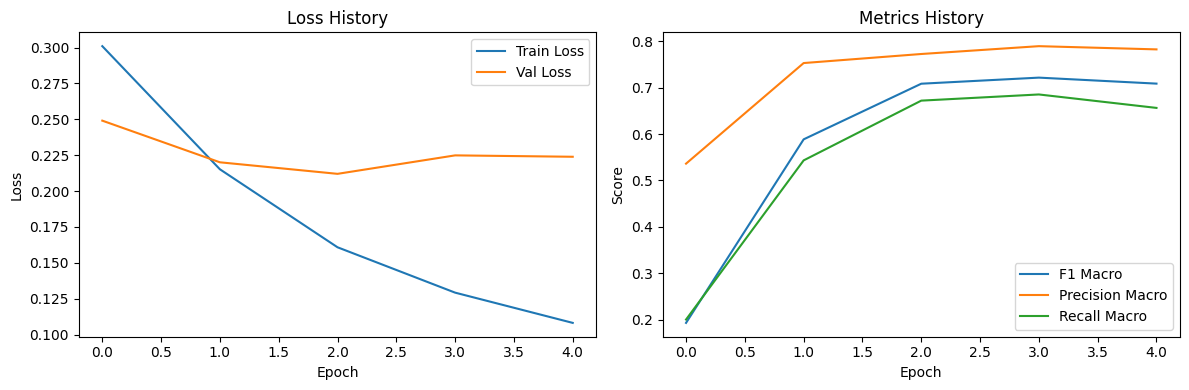

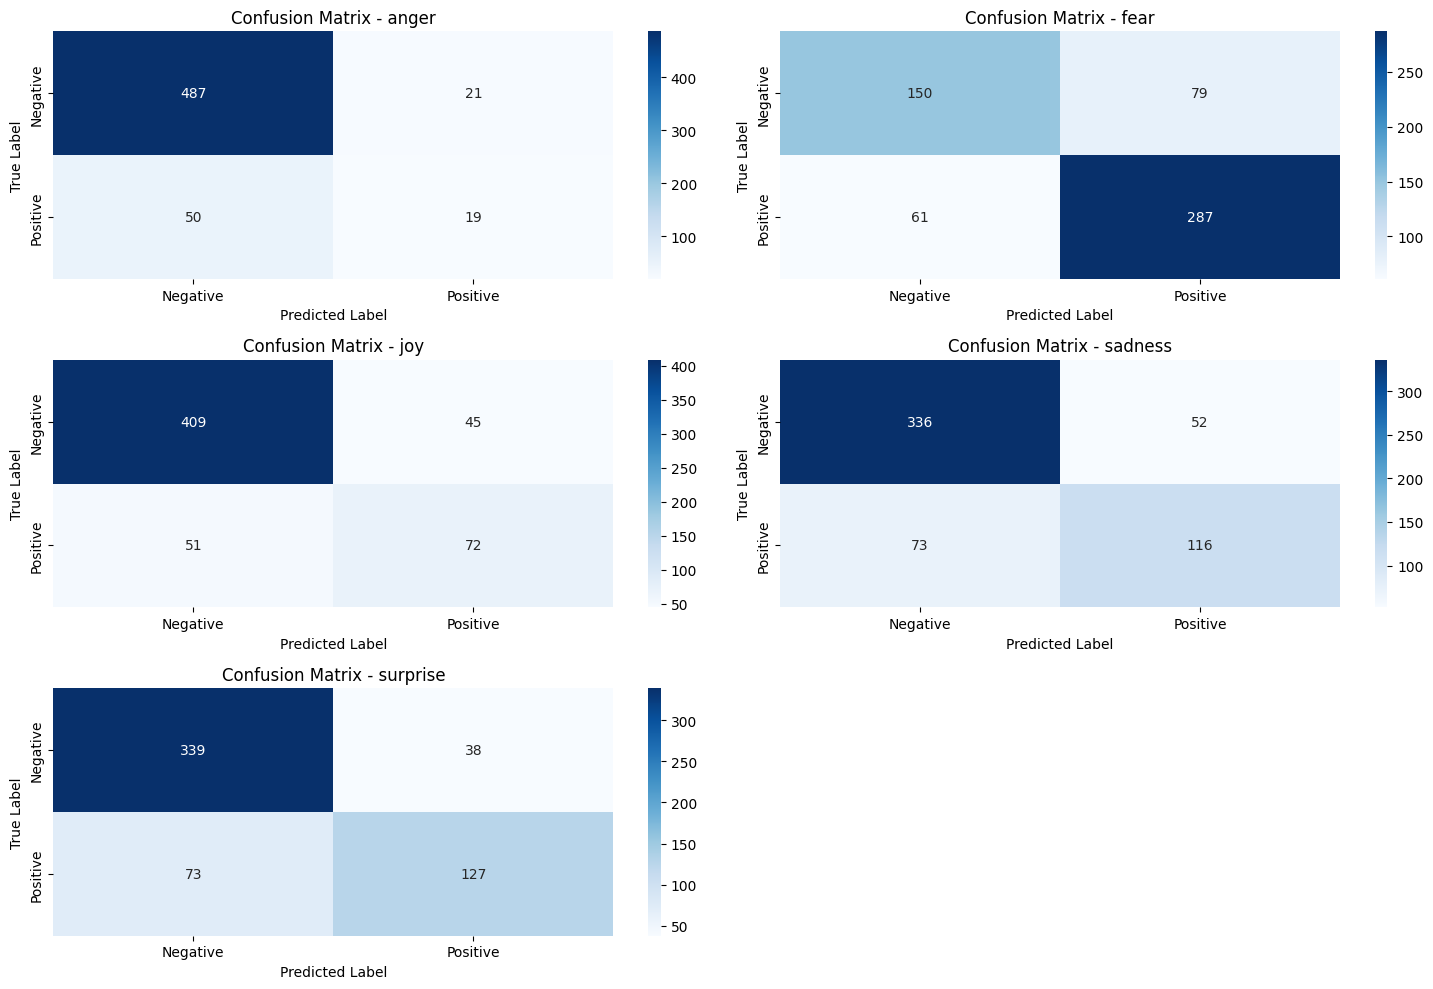


Analyzing sample text for interpretability (LIME):
Text: {{{Yeah...welcome to being 25, btw...it is awful thus far...but...SHIT at least I get to be 25!
Target emotion: anger

Explanation for anger:
  SHIT: -0.2121
  25: 0.0895
  least: 0.0891
  at: -0.0642
  Yeah: 0.0512
  to: -0.0504
  be: 0.0350
  welcome: -0.0345
  is: 0.0328
  far: 0.0274

Explanation for fear:
  SHIT: 0.2121
  25: -0.0895
  least: -0.0891
  at: 0.0642
  Yeah: -0.0512
  to: 0.0504
  be: -0.0350
  welcome: 0.0345
  is: -0.0328
  far: -0.0274

Explanation for joy:
  awful: -0.1225
  25: 0.0919
  SHIT: -0.0810
  welcome: 0.0542
  be: 0.0427
  Yeah: 0.0348
  far: 0.0317
  least: 0.0280
  being: 0.0266
  thus: -0.0178

Explanation for sadness:
  awful: 0.1225
  25: -0.0919
  SHIT: 0.0810
  welcome: -0.0542
  be: -0.0427
  Yeah: -0.0348
  far: -0.0317
  least: -0.0280
  being: -0.0266
  thus: 0.0178

Explanation for surprise:
  awful: 0.2294
  SHIT: 0.1507
  25: -0.0993
  welcome: -0.0519
  be: -0.0499
  Yeah: -0.0485


<Figure size 1000x400 with 0 Axes>

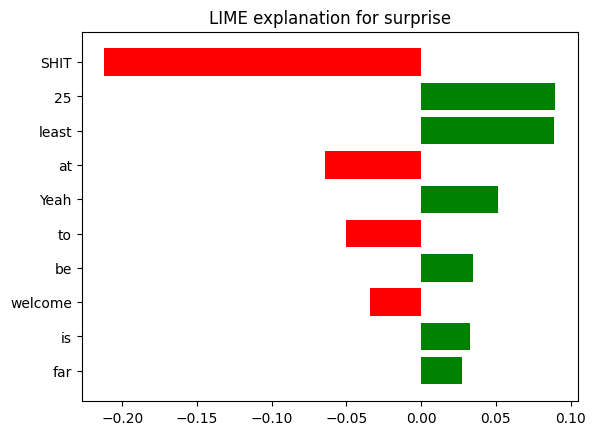


Visualizing attention weights:


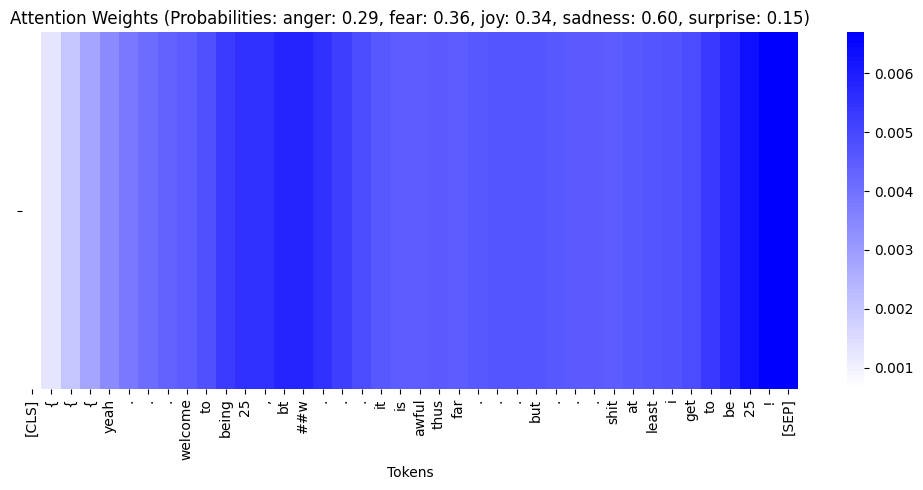


Analyzing sample text for interpretability (LIME):
Text: So, again, I tried to eat my lunch, my stomach in knots, an unseen hand gripping my heart.
Target emotion: fear

Explanation for anger:
  knots: -0.0272
  lunch: 0.0240
  I: 0.0208
  my: -0.0193
  to: -0.0191
  heart: 0.0155
  hand: 0.0139
  in: -0.0119
  unseen: -0.0105
  again: -0.0104

Explanation for fear:
  knots: 0.0272
  lunch: -0.0240
  I: -0.0208
  my: 0.0193
  to: 0.0191
  heart: -0.0155
  hand: -0.0139
  in: 0.0119
  unseen: 0.0105
  again: 0.0104

Explanation for joy:
  knots: -0.1352
  unseen: -0.1103
  stomach: -0.0950
  tried: -0.0903
  gripping: -0.0619
  lunch: 0.0599
  in: -0.0464
  heart: 0.0389
  I: 0.0365
  to: -0.0287

Explanation for sadness:
  knots: 0.1352
  unseen: 0.1103
  stomach: 0.0950
  tried: 0.0903
  gripping: 0.0619
  lunch: -0.0599
  in: 0.0464
  heart: -0.0389
  I: -0.0365
  to: 0.0287

Explanation for surprise:
  knots: 0.0978
  unseen: 0.0739
  tried: 0.0673
  stomach: 0.0672
  lunch: -0.041

<Figure size 1000x400 with 0 Axes>

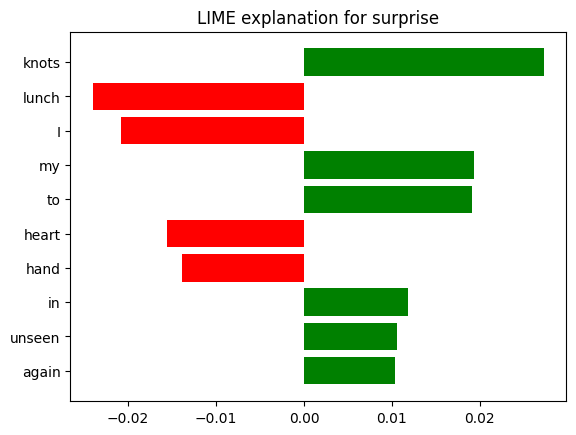


Visualizing attention weights:


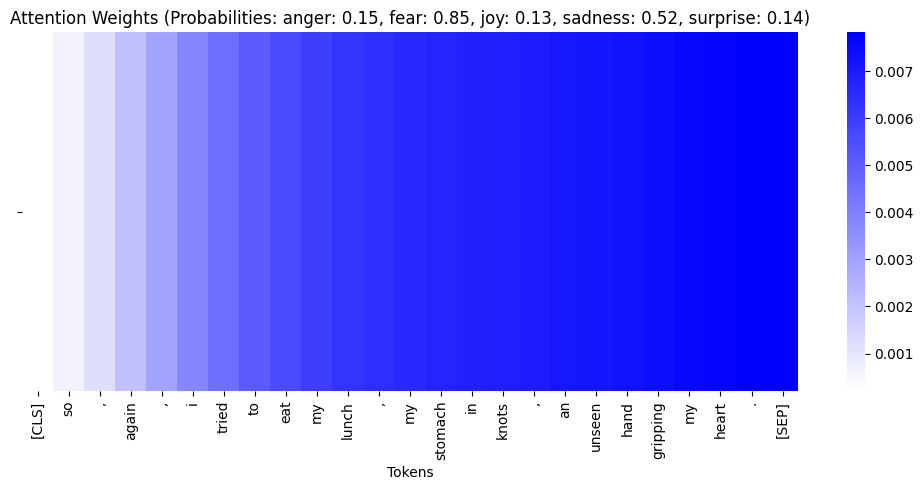


Analyzing sample text for interpretability (LIME):
Text: Its like a dream, flying through my head.
Target emotion: joy

Explanation for anger:
  through: -0.0531
  dream: 0.0478
  flying: -0.0439
  Its: 0.0220
  head: 0.0067
  my: 0.0044
  a: -0.0032
  like: -0.0016

Explanation for fear:
  through: 0.0531
  dream: -0.0478
  flying: 0.0439
  Its: -0.0220
  head: -0.0067
  my: -0.0044
  a: 0.0032
  like: 0.0016

Explanation for joy:
  through: -0.2109
  head: -0.1242
  like: -0.0966
  my: -0.0909
  flying: -0.0687
  Its: 0.0410
  dream: 0.0163
  a: -0.0129

Explanation for sadness:
  through: 0.2109
  head: 0.1242
  like: 0.0966
  my: 0.0909
  flying: 0.0687
  Its: -0.0410
  dream: -0.0163
  a: 0.0129

Explanation for surprise:
  through: 0.1982
  head: 0.0991
  like: 0.0805
  my: 0.0736
  Its: -0.0540
  dream: -0.0500
  a: 0.0138
  flying: -0.0122


<Figure size 1000x400 with 0 Axes>

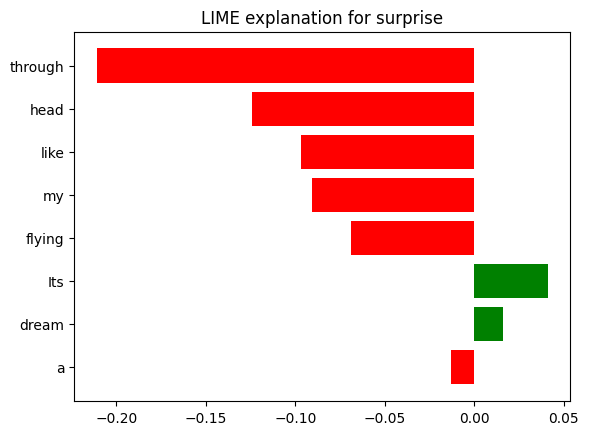


Visualizing attention weights:


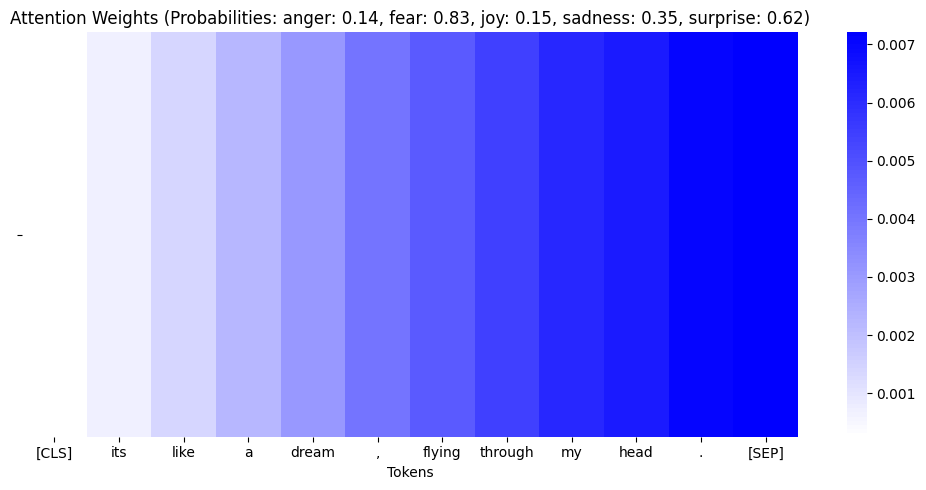


Analyzing sample text for interpretability (LIME):
Text: After dragging myself through all of those sets, my stomach being upset, and my body feeling entirely fatigued $ the LAST thing I wanted to do was hop on the treadmill for some incline walking.
Target emotion: sadness

Explanation for anger:
  upset: -0.0436
  walking: 0.0215
  LAST: -0.0186
  fatigued: 0.0172
  incline: 0.0169
  treadmill: 0.0152
  some: 0.0138
  being: 0.0136
  the: -0.0120
  feeling: 0.0120

Explanation for fear:
  upset: 0.0436
  walking: -0.0215
  LAST: 0.0186
  fatigued: -0.0172
  incline: -0.0169
  treadmill: -0.0152
  some: -0.0138
  being: -0.0136
  the: 0.0120
  feeling: -0.0120

Explanation for joy:
  fatigued: -0.0907
  dragging: -0.0650
  upset: -0.0602
  stomach: -0.0558
  body: -0.0349
  treadmill: -0.0279
  After: 0.0229
  sets: 0.0228
  being: 0.0181
  all: 0.0167

Explanation for sadness:
  fatigued: 0.0907
  dragging: 0.0650
  upset: 0.0602
  stomach: 0.0558
  body: 0.0349
  treadmill: 0.0279


<Figure size 1000x400 with 0 Axes>

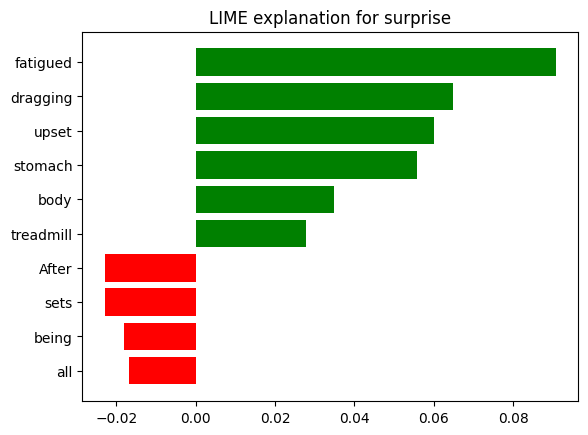


Visualizing attention weights:


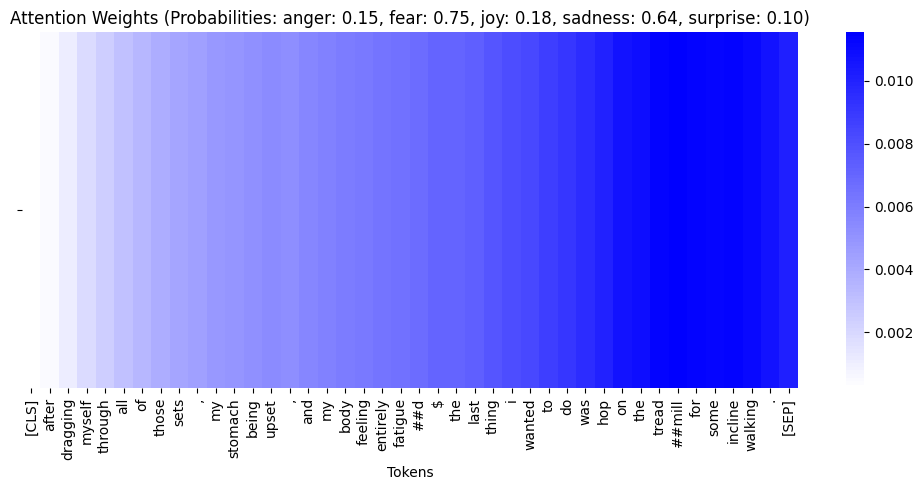


Analyzing sample text for interpretability (LIME):
Text: My jaw nearly dropped.
Target emotion: surprise

Explanation for anger:
  dropped: -0.1743
  My: 0.0845
  nearly: 0.0447
  jaw: -0.0204

Explanation for fear:
  dropped: 0.1743
  My: -0.0845
  nearly: -0.0447
  jaw: 0.0204

Explanation for joy:
  nearly: -0.1969
  dropped: -0.1544
  My: -0.1002
  jaw: -0.0828

Explanation for sadness:
  nearly: 0.1969
  dropped: 0.1544
  My: 0.1002
  jaw: 0.0828

Explanation for surprise:
  dropped: 0.1154
  jaw: 0.0662
  nearly: 0.0604
  My: 0.0549


<Figure size 1000x400 with 0 Axes>

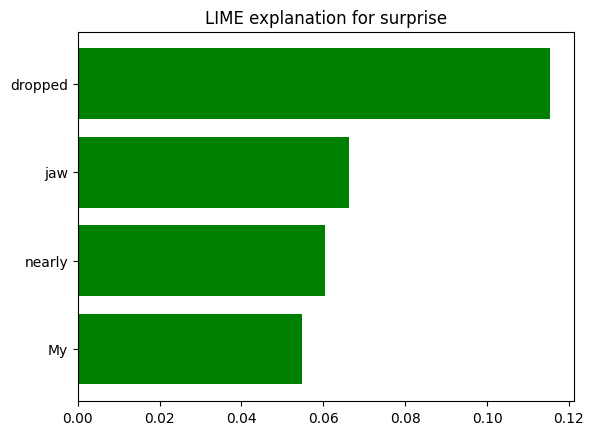


Visualizing attention weights:


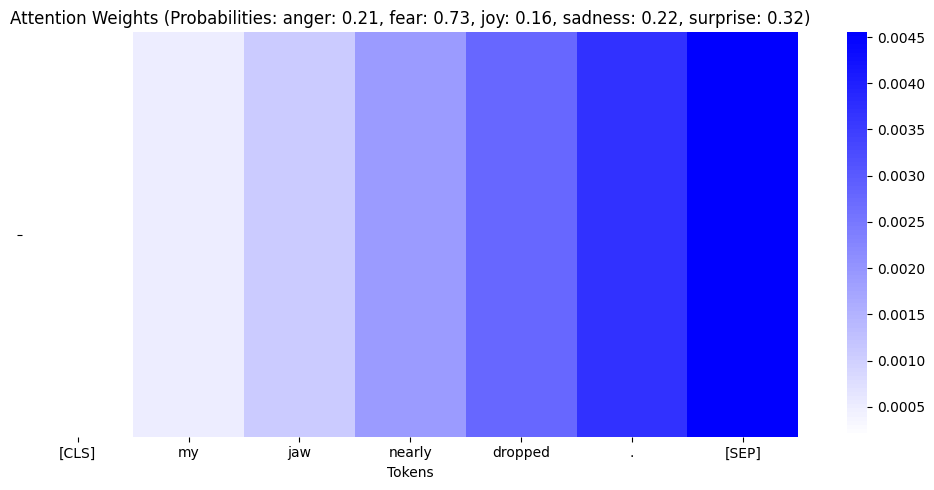


Training model for language: en
Using model: distilbert-base-uncased
Loss function: weighted_bce
Verifying extracted dataset structure in ./data/track_a...

Extracted dataset structure is correct!
Found files:
  ./data/track_a/train/en/data.csv
  ./data/track_a/train/hi/data.csv
  ./data/track_a/train/mr/data.csv
  ./data/track_a/dev/en/data.csv
  ./data/track_a/dev/hi/data.csv
  ./data/track_a/dev/mr/data.csv
  ./data/track_a/test/en/data.csv
  ./data/track_a/test/hi/data.csv
  ./data/track_a/test/mr/data.csv

Dataset for language 'en':
Shape: (2884, 7)
Columns: ['id', 'text', 'anger', 'fear', 'joy', 'sadness', 'surprise']

Class distribution:
anger: 349 (12.10%)
fear: 1674 (58.04%)
joy: 705 (24.45%)
sadness: 913 (31.66%)
surprise: 870 (30.17%)
Training set: 2076 samples
Validation set: 231 samples
Test set: 577 samples

Epoch 1/5


Evaluating: 100%|██████████| 15/15 [00:01<00:00, 13.29it/s]


Train Loss: 0.5823
Val Loss: 0.5112
F1 Macro: 0.1360
Precision Macro: 0.1030
Recall Macro: 0.2000
Hamming Loss: 0.2952
Jaccard Score: 0.2958
New best model saved with F1 Macro: 0.1360

Epoch 2/5


Evaluating: 100%|██████████| 15/15 [00:01<00:00, 13.45it/s]


Train Loss: 0.4701
Val Loss: 0.4181
F1 Macro: 0.3960
Precision Macro: 0.5142
Recall Macro: 0.3704
Hamming Loss: 0.2320
Jaccard Score: 0.4051
New best model saved with F1 Macro: 0.3960

Epoch 3/5


...

Train Loss: 0.3067
Val Loss: 0.3788
F1 Macro: 0.6051
Precision Macro: 0.7240
Recall Macro: 0.5682
Hamming Loss: 0.1939
Jaccard Score: 0.5133
New best model saved with F1 Macro: 0.6051

Epoch 5/5


Evaluating: 100%|██████████| 15/15 [00:01<00:00, 13.47it/s]


Train Loss: 0.2697
Val Loss: 0.3827
F1 Macro: 0.6407
Precision Macro: 0.7465
Recall Macro: 0.5969
Hamming Loss: 0.1835
Jaccard Score: 0.5397
New best model saved with F1 Macro: 0.6407


Evaluating: 100%|██████████| 37/37 [00:02<00:00, 13.32it/s]



Test Results:
F1 Macro: 0.5792
Precision Macro: 0.6614
Recall Macro: 0.5470
Hamming Loss: 0.2139
Jaccard Score: 0.5095

Detailed Classification Report:
              precision    recall  f1-score   support

       anger       0.56      0.39      0.46        69
        fear       0.72      0.88      0.79       348
         joy       0.61      0.59      0.60       123
     sadness       0.66      0.58      0.62       189
    surprise       0.76      0.30      0.43       200

   micro avg       0.69      0.62      0.65       929
   macro avg       0.66      0.55      0.58       929
weighted avg       0.69      0.62      0.63       929
 samples avg       0.63      0.58      0.58       929



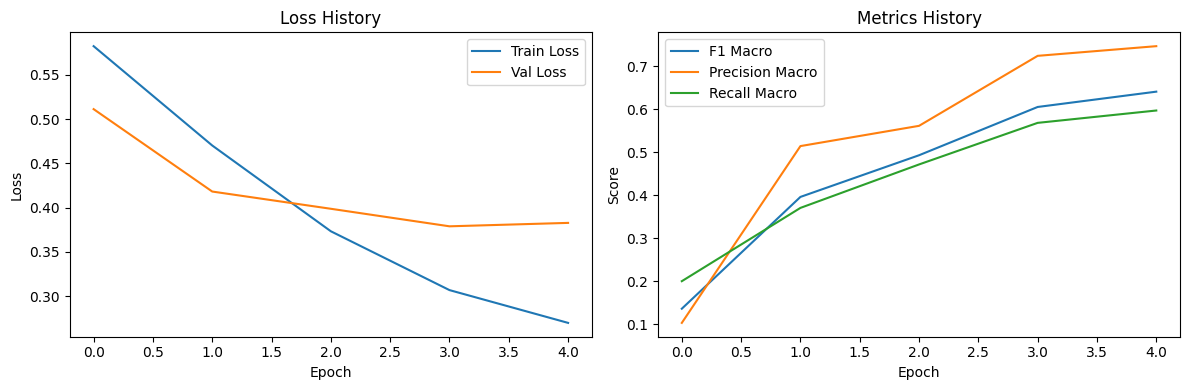

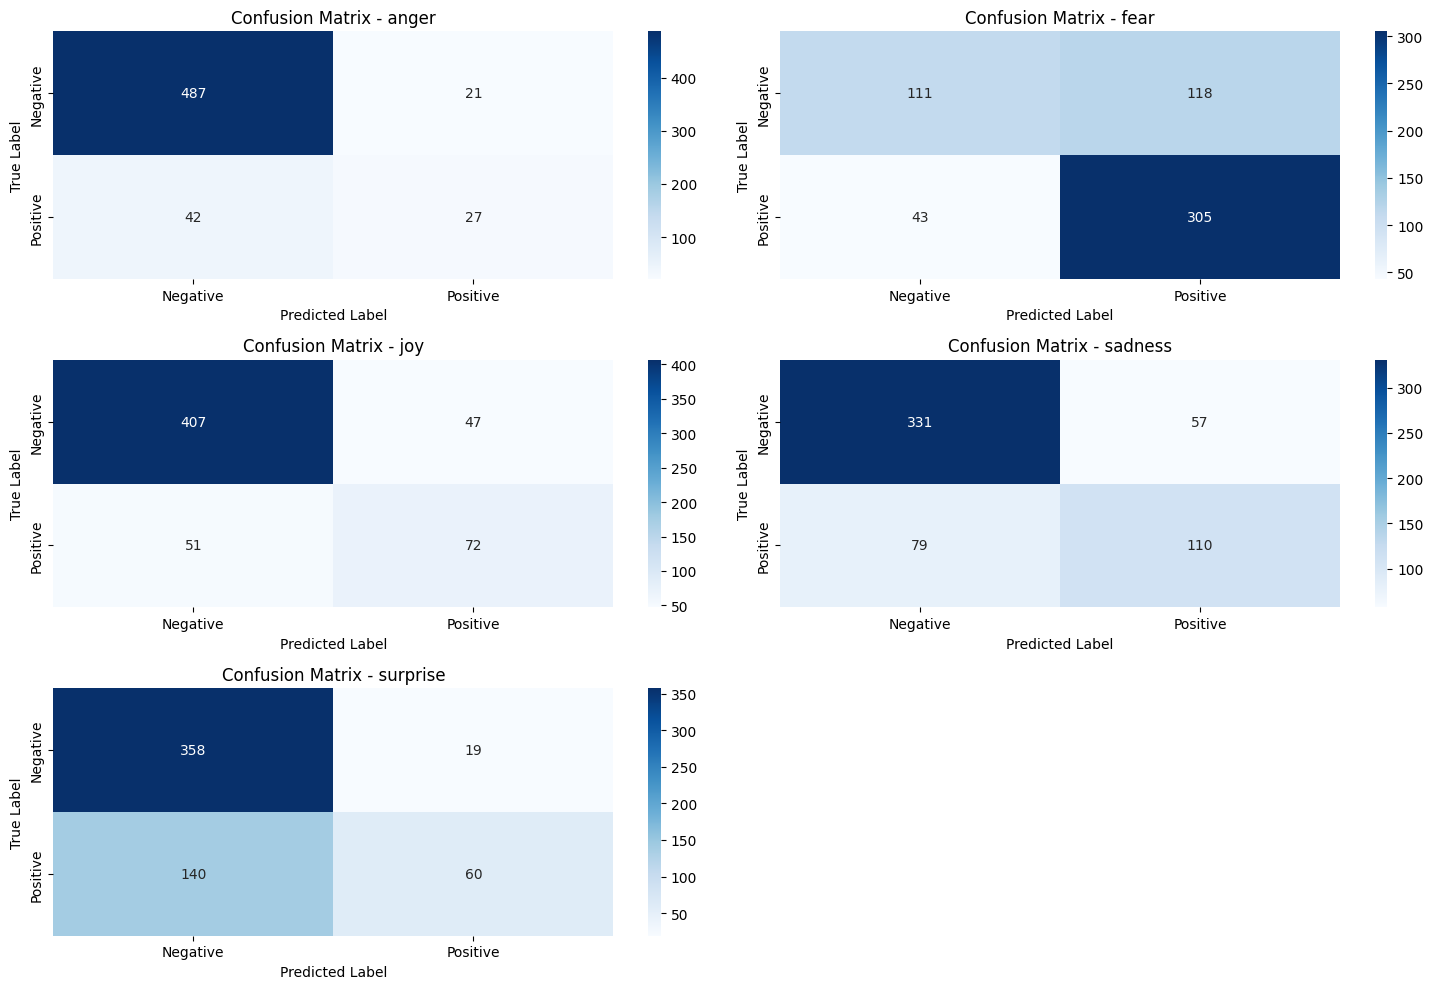


Analyzing sample text for interpretability (LIME):
Text: This girl faked a miscarriage.
Target emotion: anger

Explanation for anger:
  miscarriage: 0.2965
  faked: -0.1954
  This: -0.0420
  girl: -0.0055
  a: 0.0005

Explanation for fear:
  miscarriage: -0.2965
  faked: 0.1954
  This: 0.0420
  girl: 0.0055
  a: -0.0005

Explanation for joy:
  miscarriage: -0.2085
  faked: -0.1487
  girl: 0.0114
  This: -0.0093
  a: -0.0087

Explanation for sadness:
  miscarriage: 0.2085
  faked: 0.1487
  girl: -0.0114
  This: 0.0093
  a: 0.0087

Explanation for surprise:
  miscarriage: 0.1870
  faked: 0.1740
  girl: -0.0338
  a: 0.0109
  This: 0.0083


<Figure size 1000x400 with 0 Axes>

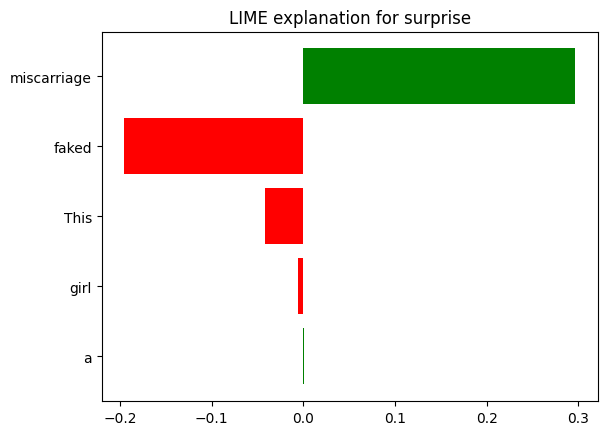


Visualizing attention weights:


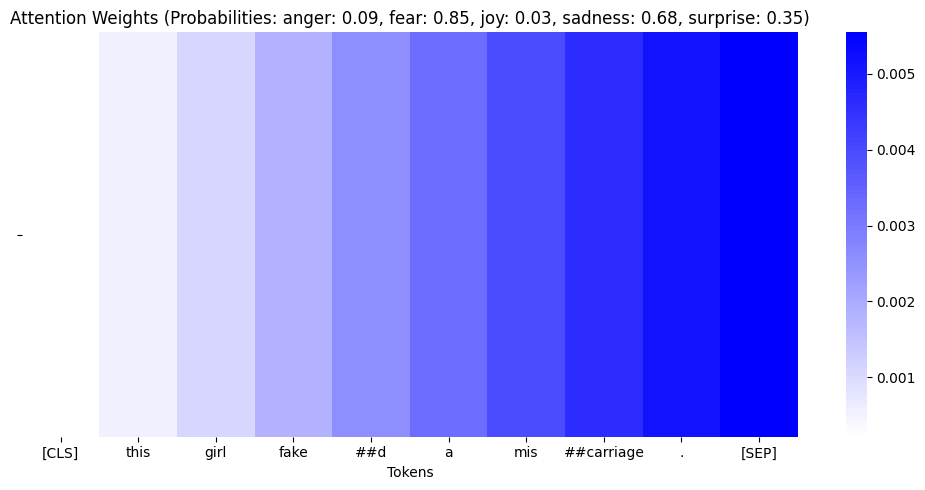


Analyzing sample text for interpretability (LIME):
Text: The police were called.
Target emotion: fear

Explanation for anger:
  police: -0.0169
  called: -0.0055
  The: -0.0020
  were: 0.0008

Explanation for fear:
  police: 0.0169
  called: 0.0055
  The: 0.0020
  were: -0.0008

Explanation for joy:
  police: -0.1698
  called: -0.0630
  The: -0.0430
  were: -0.0261

Explanation for sadness:
  police: 0.1698
  called: 0.0630
  The: 0.0430
  were: 0.0261

Explanation for surprise:
  police: 0.0988
  called: 0.0400
  The: 0.0296
  were: 0.0160


<Figure size 1000x400 with 0 Axes>

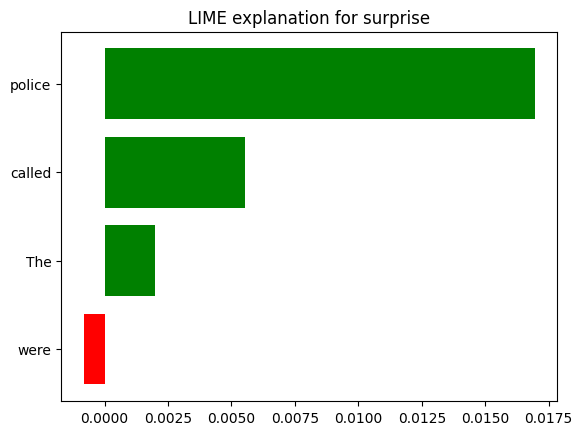


Visualizing attention weights:


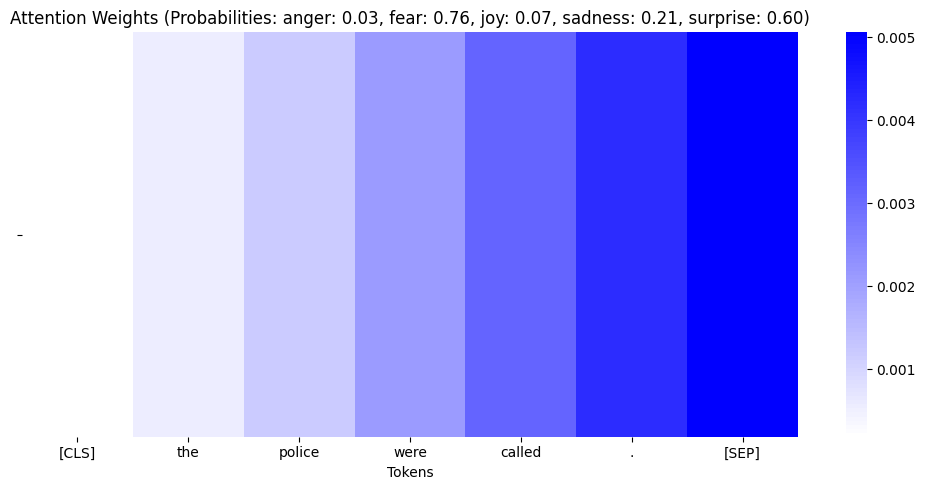


Analyzing sample text for interpretability (LIME):
Text: ), and I've imagined an entire life for him, his family, and his friends.
Target emotion: joy

Explanation for anger:
  life: 0.0050
  for: -0.0030
  friends: -0.0021
  an: -0.0018
  him: -0.0016
  imagined: 0.0012
  entire: 0.0011
  his: 0.0009
  family: 0.0008
  I: 0.0007

Explanation for fear:
  life: -0.0050
  for: 0.0030
  friends: 0.0021
  an: 0.0018
  him: 0.0016
  imagined: -0.0012
  entire: -0.0011
  his: -0.0009
  family: -0.0008
  I: -0.0007

Explanation for joy:
  for: 0.0172
  friends: 0.0161
  family: 0.0074
  I: 0.0065
  entire: -0.0054
  an: 0.0051
  ve: 0.0037
  life: 0.0033
  imagined: -0.0025
  his: 0.0025

Explanation for sadness:
  for: -0.0172
  friends: -0.0161
  family: -0.0074
  I: -0.0065
  entire: 0.0054
  an: -0.0051
  ve: -0.0037
  life: -0.0033
  imagined: 0.0025
  his: -0.0025

Explanation for surprise:
  for: -0.0422
  friends: -0.0395
  an: -0.0157
  entire: 0.0138
  family: -0.0134
  I: -0.0098


<Figure size 1000x400 with 0 Axes>

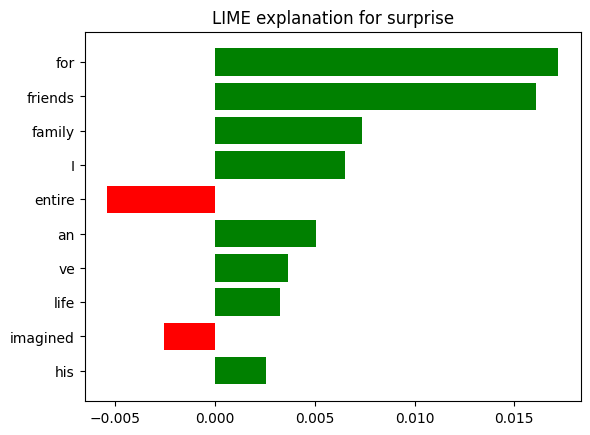


Visualizing attention weights:


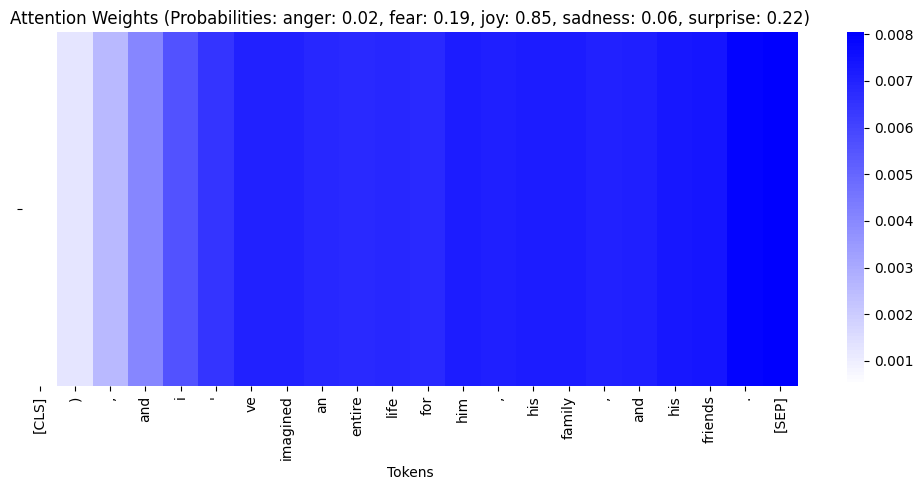


Analyzing sample text for interpretability (LIME):
Text: So no surgery due to blood clot because I have to take injections and pills to thin my blood way out so the clot doesn't break off and go to my lungs or brain.
Target emotion: sadness

Explanation for anger:
  my: 0.0306
  surgery: 0.0304
  pills: 0.0257
  lungs: 0.0241
  break: -0.0198
  So: -0.0154
  due: 0.0154
  t: 0.0140
  the: 0.0140
  no: -0.0091

Explanation for fear:
  my: -0.0306
  surgery: -0.0304
  pills: -0.0257
  lungs: -0.0241
  break: 0.0198
  So: 0.0154
  due: -0.0154
  t: -0.0140
  the: -0.0140
  no: 0.0091

Explanation for joy:
  clot: -0.0200
  surgery: 0.0128
  because: -0.0126
  blood: -0.0118
  t: 0.0078
  way: -0.0071
  injections: -0.0062
  I: 0.0061
  brain: -0.0053
  no: 0.0052

Explanation for sadness:
  clot: 0.0200
  surgery: -0.0128
  because: 0.0126
  blood: 0.0118
  t: -0.0078
  way: 0.0071
  injections: 0.0062
  I: -0.0061
  brain: 0.0053
  no: -0.0052

Explanation for surprise:
  clot: 0.0054
 

<Figure size 1000x400 with 0 Axes>

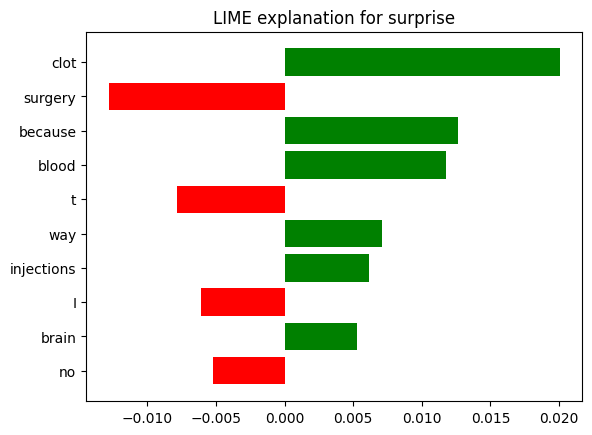


Visualizing attention weights:


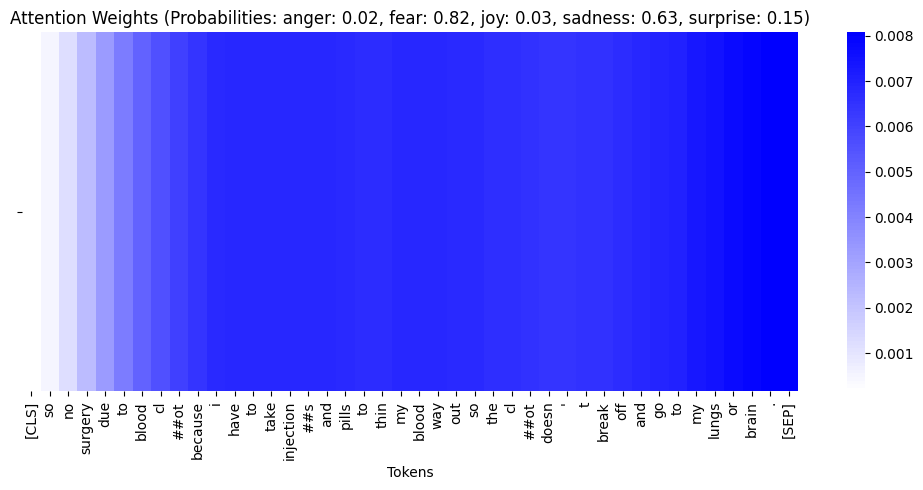


Analyzing sample text for interpretability (LIME):
Text: After like two seconds of that, we start *flying* forward and *smash through the parking barrier*, stopping *right by* the edge of the street.
Target emotion: surprise

Explanation for anger:
  smash: -0.2063
  start: 0.0978
  forward: 0.0886
  we: 0.0793
  the: -0.0784
  parking: -0.0573
  stopping: 0.0526
  seconds: -0.0431
  right: -0.0345
  barrier: -0.0222

Explanation for fear:
  smash: 0.2063
  start: -0.0978
  forward: -0.0886
  we: -0.0793
  the: 0.0784
  parking: 0.0573
  stopping: -0.0526
  seconds: 0.0431
  right: 0.0345
  barrier: 0.0222

Explanation for joy:
  smash: -0.1757
  the: -0.0543
  seconds: -0.0475
  flying: -0.0462
  barrier: -0.0451
  we: 0.0413
  street: -0.0357
  start: 0.0357
  through: -0.0325
  forward: 0.0323

Explanation for sadness:
  smash: 0.1757
  the: 0.0543
  seconds: 0.0475
  flying: 0.0462
  barrier: 0.0451
  we: -0.0413
  street: 0.0357
  start: -0.0357
  through: 0.0325
  forward: -0.03

<Figure size 1000x400 with 0 Axes>

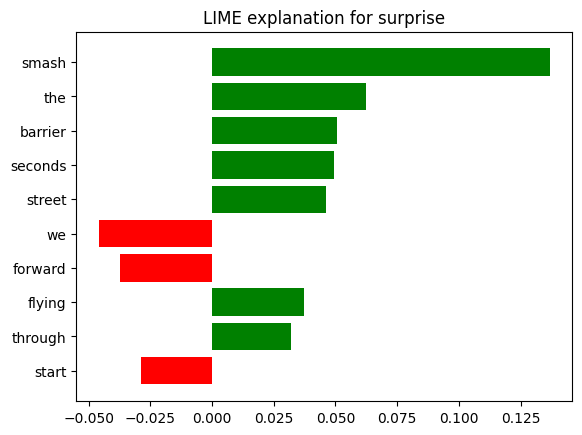


Visualizing attention weights:


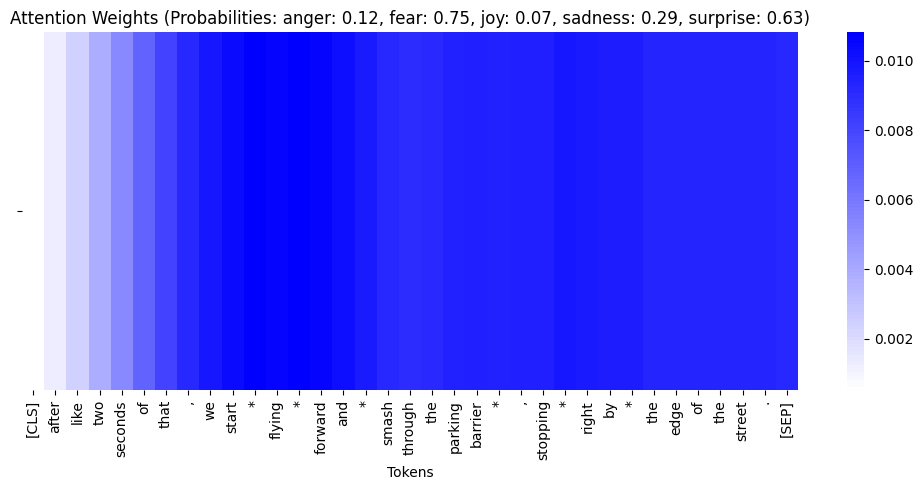


Training model for language: en
Using model: distilbert-base-uncased
Loss function: asymmetric_focal
Verifying extracted dataset structure in ./data/track_a...

Extracted dataset structure is correct!
Found files:
  ./data/track_a/train/en/data.csv
  ./data/track_a/train/hi/data.csv
  ./data/track_a/train/mr/data.csv
  ./data/track_a/dev/en/data.csv
  ./data/track_a/dev/hi/data.csv
  ./data/track_a/dev/mr/data.csv
  ./data/track_a/test/en/data.csv
  ./data/track_a/test/hi/data.csv
  ./data/track_a/test/mr/data.csv

Dataset for language 'en':
Shape: (2884, 7)
Columns: ['id', 'text', 'anger', 'fear', 'joy', 'sadness', 'surprise']

Class distribution:
anger: 349 (12.10%)
fear: 1674 (58.04%)
joy: 705 (24.45%)
sadness: 913 (31.66%)
surprise: 870 (30.17%)
Training set: 2076 samples
Validation set: 231 samples
Test set: 577 samples

Epoch 1/5


Evaluating: 100%|██████████| 15/15 [00:01<00:00, 13.43it/s]


Train Loss: 0.0604
Val Loss: 0.0512
F1 Macro: 0.1457
Precision Macro: 0.1353
Recall Macro: 0.1580
Hamming Loss: 0.2589
Jaccard Score: 0.2229
New best model saved with F1 Macro: 0.1457

Epoch 2/5


Evaluating: 100%|██████████| 15/15 [00:01<00:00, 13.48it/s]


Train Loss: 0.0461
Val Loss: 0.0452
F1 Macro: 0.4653
Precision Macro: 0.6795
Recall Macro: 0.3828
Hamming Loss: 0.1974
Jaccard Score: 0.4087
New best model saved with F1 Macro: 0.4653

Epoch 3/5


...

Train Loss: 0.0298
Val Loss: 0.0436
F1 Macro: 0.6828
Precision Macro: 0.8277
Recall Macro: 0.6021
Hamming Loss: 0.1532
Jaccard Score: 0.5624
New best model saved with F1 Macro: 0.6828

Epoch 5/5


Evaluating: 100%|██████████| 15/15 [00:01<00:00, 13.45it/s]


Train Loss: 0.0254
Val Loss: 0.0440
F1 Macro: 0.6864
Precision Macro: 0.8339
Recall Macro: 0.6073
Hamming Loss: 0.1506
Jaccard Score: 0.5696
New best model saved with F1 Macro: 0.6864


Evaluating: 100%|██████████| 37/37 [00:02<00:00, 13.33it/s]



Test Results:
F1 Macro: 0.6031
Precision Macro: 0.7016
Recall Macro: 0.5475
Hamming Loss: 0.1813
Jaccard Score: 0.5364

Detailed Classification Report:
              precision    recall  f1-score   support

       anger       0.54      0.19      0.28        69
        fear       0.82      0.81      0.81       348
         joy       0.67      0.54      0.60       123
     sadness       0.71      0.58      0.64       189
    surprise       0.77      0.62      0.69       200

   micro avg       0.76      0.64      0.69       929
   macro avg       0.70      0.55      0.60       929
weighted avg       0.74      0.64      0.68       929
 samples avg       0.65      0.60      0.60       929



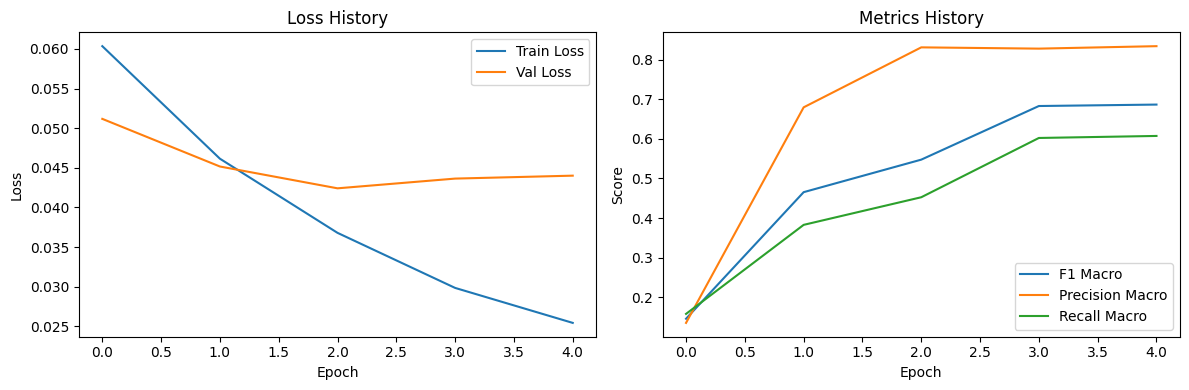

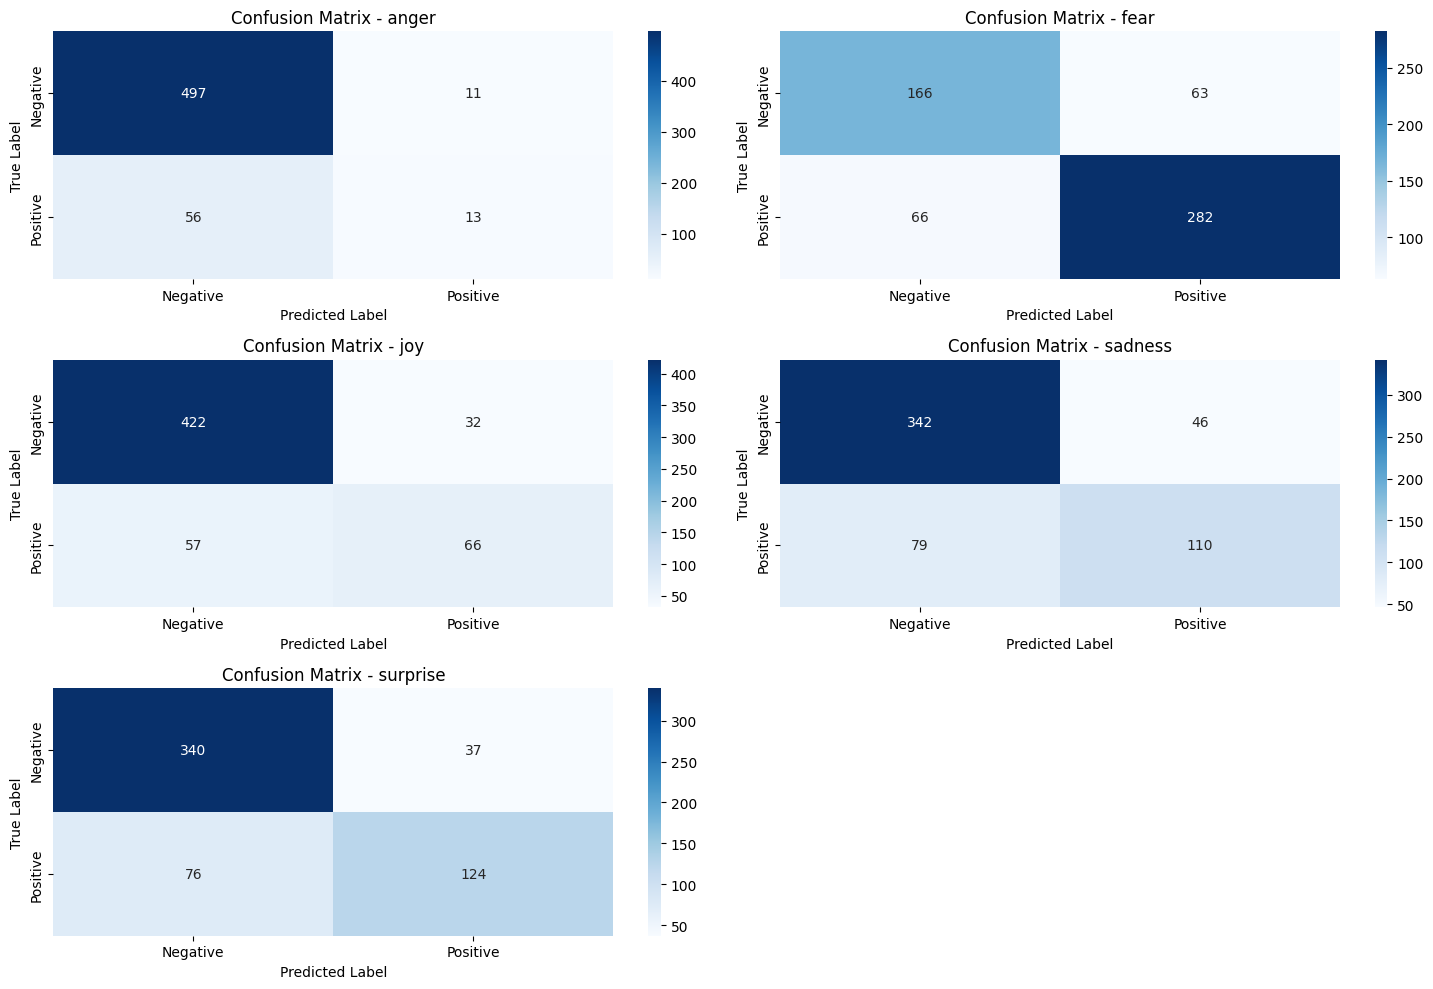


Analyzing sample text for interpretability (LIME):
Text: The second time I saw her, she told me she was a registered sex offender.
Target emotion: anger

Explanation for anger:
  offender: -0.1957
  sex: -0.0423
  registered: 0.0370
  saw: 0.0364
  she: -0.0233
  I: 0.0172
  me: -0.0123
  her: -0.0122
  second: -0.0121
  a: -0.0110

Explanation for fear:
  offender: 0.1957
  sex: 0.0423
  registered: -0.0370
  saw: -0.0364
  she: 0.0233
  I: -0.0172
  me: 0.0123
  her: 0.0122
  second: 0.0121
  a: 0.0110

Explanation for joy:
  offender: -0.2655
  saw: -0.0681
  told: -0.0465
  second: -0.0218
  I: -0.0191
  was: -0.0170
  registered: -0.0155
  a: 0.0102
  sex: 0.0089
  me: 0.0072

Explanation for sadness:
  offender: 0.2655
  saw: 0.0681
  told: 0.0465
  second: 0.0218
  I: 0.0191
  was: 0.0170
  registered: 0.0155
  a: -0.0102
  sex: -0.0089
  me: -0.0072

Explanation for surprise:
  offender: 0.1751
  she: -0.0234
  told: 0.0169
  was: 0.0124
  sex: -0.0120
  I: 0.0114
  second: 0.

<Figure size 1000x400 with 0 Axes>

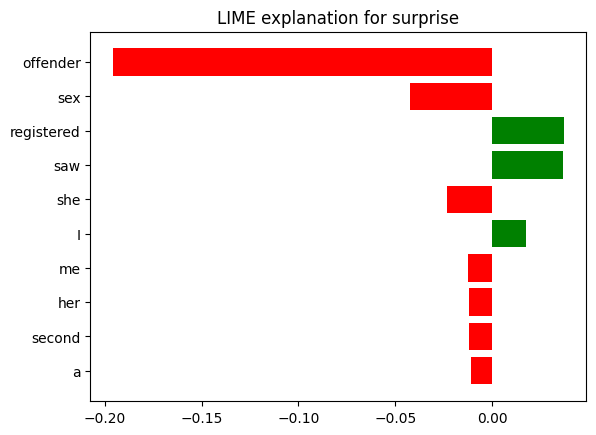


Visualizing attention weights:


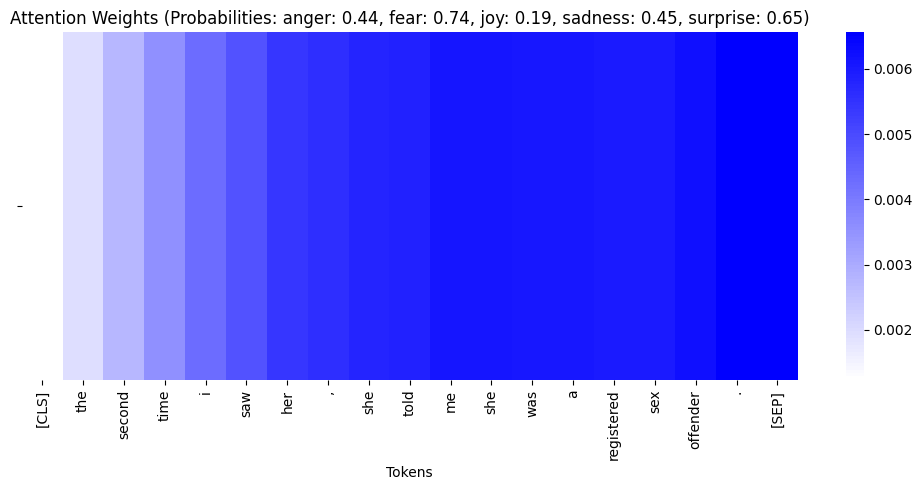


Analyzing sample text for interpretability (LIME):
Text: I had my hand on the side of my face when I was drawing, and then I moved it and was like ` OH MY GOD I 'M BLEEDING OUT MY EARS AHHHHH!
Target emotion: fear

Explanation for anger:
  BLEEDING: -0.1179
  OUT: -0.0416
  MY: -0.0242
  drawing: 0.0241
  AHHHHH: 0.0193
  I: 0.0183
  OH: 0.0120
  my: 0.0116
  hand: 0.0114
  moved: 0.0110

Explanation for fear:
  BLEEDING: 0.1179
  OUT: 0.0416
  MY: 0.0242
  drawing: -0.0241
  AHHHHH: -0.0193
  I: -0.0183
  OH: -0.0120
  my: -0.0116
  hand: -0.0114
  moved: -0.0110

Explanation for joy:
  BLEEDING: -0.4559
  AHHHHH: -0.0344
  OH: -0.0315
  GOD: -0.0275
  OUT: -0.0274
  MY: 0.0270
  I: 0.0224
  of: -0.0224
  drawing: 0.0169
  when: 0.0118

Explanation for sadness:
  BLEEDING: 0.4559
  AHHHHH: 0.0344
  OH: 0.0315
  GOD: 0.0275
  OUT: 0.0274
  MY: -0.0270
  I: -0.0224
  of: 0.0224
  drawing: -0.0169
  when: -0.0118

Explanation for surprise:
  BLEEDING: 0.2742
  I: -0.0319
  M: 0.0245
  O

<Figure size 1000x400 with 0 Axes>

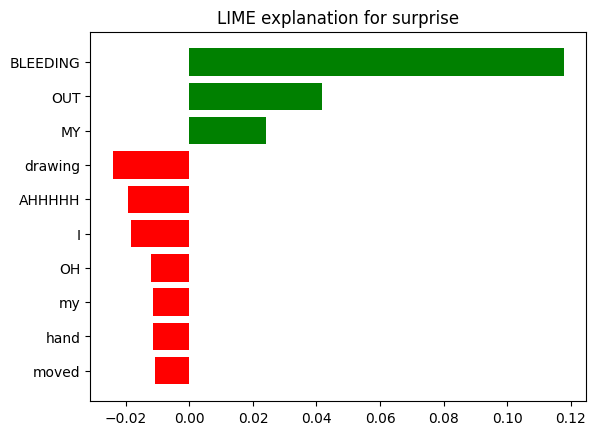


Visualizing attention weights:


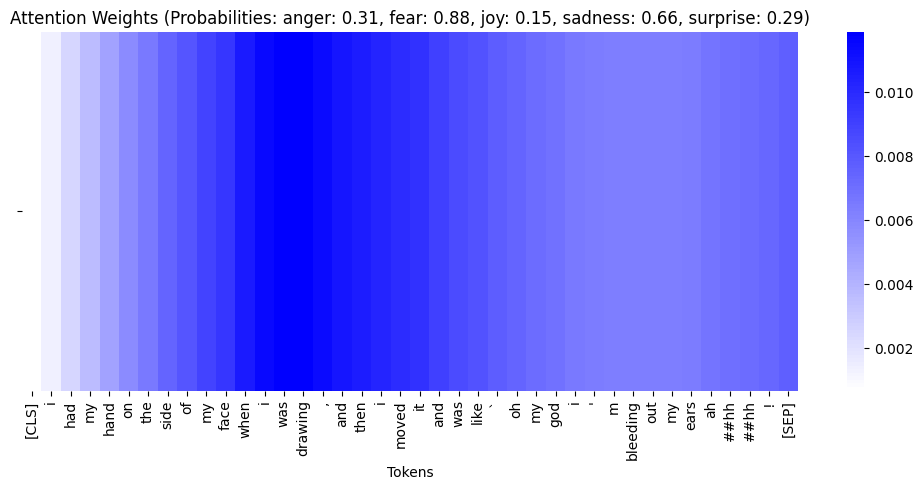


Analyzing sample text for interpretability (LIME):
Text: ; ) In the evening we did go down and put our feet in the water-I got to about my waist actually.
Target emotion: joy

Explanation for anger:
  feet: 0.0134
  water: 0.0125
  waist: 0.0100
  to: 0.0089
  evening: 0.0076
  did: -0.0070
  we: 0.0065
  I: 0.0063
  got: 0.0053
  actually: -0.0050

Explanation for fear:
  feet: -0.0134
  water: -0.0125
  waist: -0.0100
  to: -0.0089
  evening: -0.0076
  did: 0.0070
  we: -0.0065
  I: -0.0063
  got: -0.0053
  actually: 0.0050

Explanation for joy:
  evening: 0.0745
  down: -0.0364
  we: 0.0359
  to: -0.0358
  about: -0.0289
  feet: -0.0281
  put: 0.0227
  in: -0.0205
  our: 0.0169
  go: -0.0110

Explanation for sadness:
  evening: -0.0745
  down: 0.0364
  we: -0.0359
  to: 0.0358
  about: 0.0289
  feet: 0.0281
  put: -0.0227
  in: 0.0205
  our: -0.0169
  go: 0.0110

Explanation for surprise:
  to: 0.0655
  evening: -0.0599
  about: 0.0510
  we: -0.0494
  got: -0.0467
  down: 0.0451
  

<Figure size 1000x400 with 0 Axes>

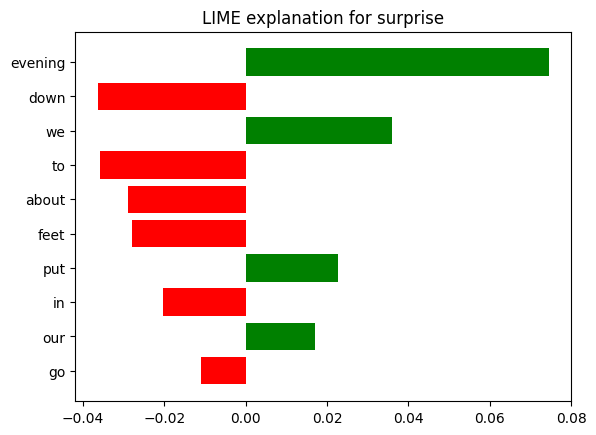


Visualizing attention weights:


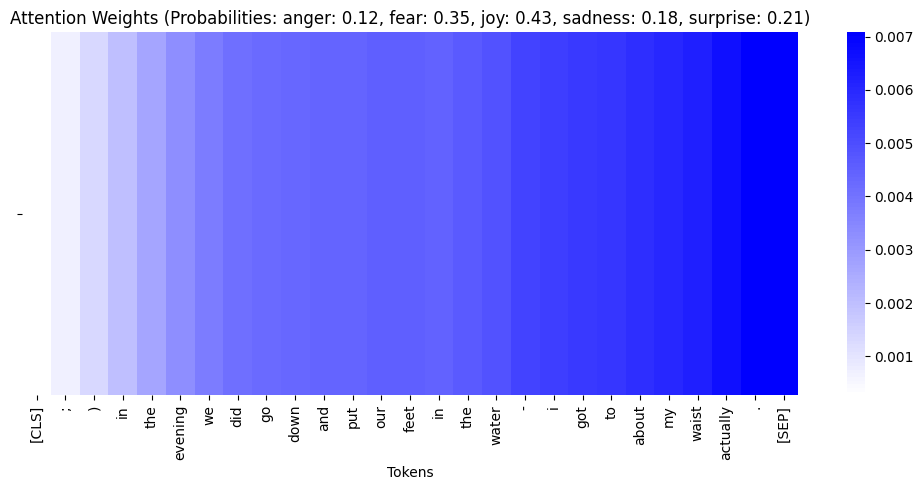


Analyzing sample text for interpretability (LIME):
Text: I could still feel glass showering down and now the cut on my head was bleeding pretty badly, I could taste the blood as it ran down my face and mixed with my sweat and hit my lips.
Target emotion: sadness

Explanation for anger:
  blood: -0.0403
  hit: -0.0317
  and: -0.0299
  bleeding: -0.0263
  sweat: 0.0258
  I: 0.0253
  my: 0.0173
  glass: -0.0172
  still: 0.0138
  now: 0.0112

Explanation for fear:
  blood: 0.0403
  hit: 0.0317
  and: 0.0299
  bleeding: 0.0263
  sweat: -0.0258
  I: -0.0253
  my: -0.0173
  glass: 0.0172
  still: -0.0138
  now: -0.0112

Explanation for joy:
  bleeding: -0.1048
  blood: -0.0841
  badly: -0.0522
  pretty: 0.0470
  sweat: -0.0421
  hit: -0.0411
  glass: -0.0239
  lips: 0.0160
  still: 0.0140
  as: 0.0108

Explanation for sadness:
  bleeding: 0.1048
  blood: 0.0841
  badly: 0.0522
  pretty: -0.0470
  sweat: 0.0421
  hit: 0.0411
  glass: 0.0239
  lips: -0.0160
  still: -0.0140
  as: -0.0108

Expl

<Figure size 1000x400 with 0 Axes>

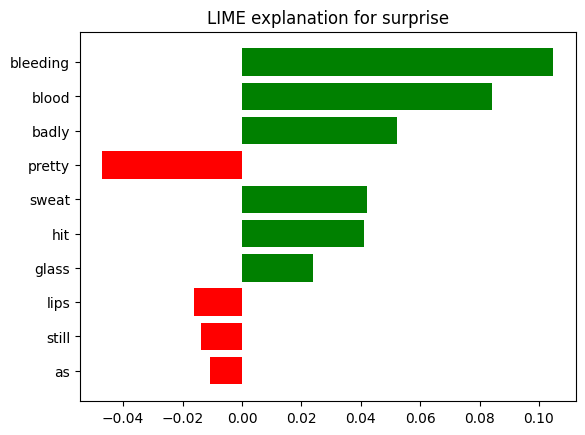


Visualizing attention weights:


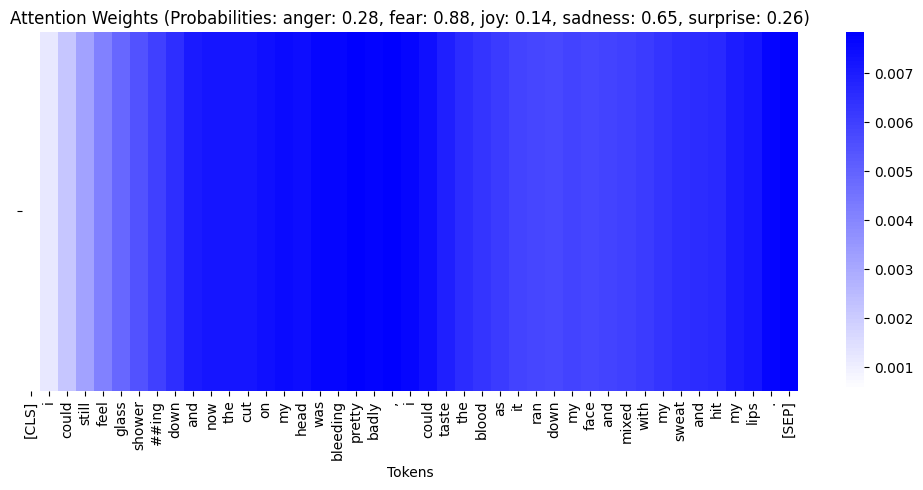


Analyzing sample text for interpretability (LIME):
Text: Not exactly an objection but very close.
Target emotion: surprise

Explanation for anger:
  objection: -0.1558
  close: 0.1013
  an: -0.0667
  very: 0.0181
  but: -0.0146
  exactly: -0.0049
  Not: 0.0048

Explanation for fear:
  objection: 0.1558
  close: -0.1013
  an: 0.0667
  very: -0.0181
  but: 0.0146
  exactly: 0.0049
  Not: -0.0048

Explanation for joy:
  close: -0.0964
  Not: 0.0572
  objection: 0.0282
  an: 0.0266
  but: -0.0251
  exactly: -0.0166
  very: -0.0082

Explanation for sadness:
  close: 0.0964
  Not: -0.0572
  objection: -0.0282
  an: -0.0266
  but: 0.0251
  exactly: 0.0166
  very: 0.0082

Explanation for surprise:
  close: 0.0319
  objection: 0.0198
  Not: -0.0155
  an: -0.0129
  but: 0.0049
  very: -0.0011
  exactly: 0.0001


<Figure size 1000x400 with 0 Axes>

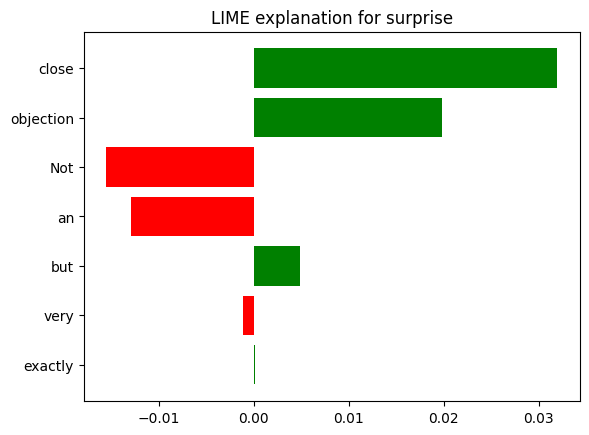


Visualizing attention weights:


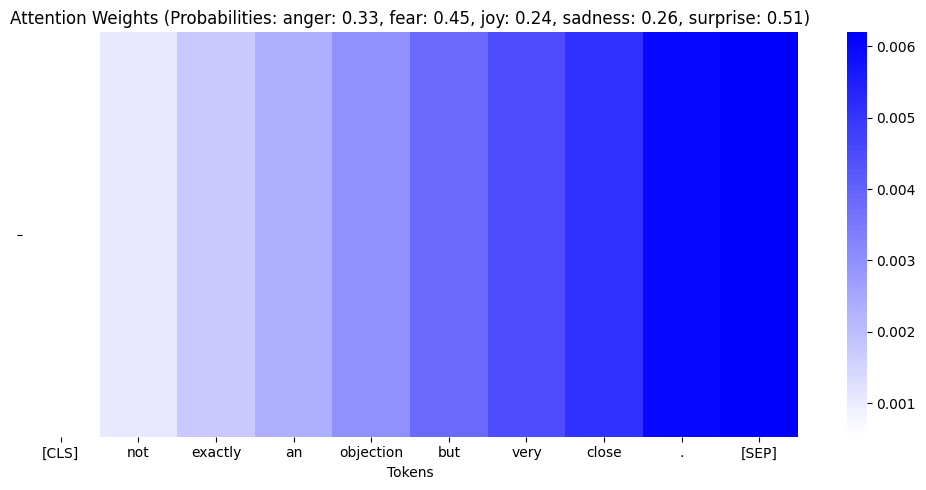


Training multilingual model for languages: hi, mr
Using model: bert-base-multilingual-uncased
Loss function: focal
Verifying extracted dataset structure in ./data/track_a...

Extracted dataset structure is correct!
Found files:
  ./data/track_a/train/en/data.csv
  ./data/track_a/train/hi/data.csv
  ./data/track_a/train/mr/data.csv
  ./data/track_a/dev/en/data.csv
  ./data/track_a/dev/hi/data.csv
  ./data/track_a/dev/mr/data.csv
  ./data/track_a/test/en/data.csv
  ./data/track_a/test/hi/data.csv
  ./data/track_a/test/mr/data.csv

Dataset for language 'hi':
Shape: (2656, 8)
Columns: ['id', 'text', 'anger', 'disgust', 'fear', 'joy', 'sadness', 'surprise']

Class distribution:
anger: 438 (16.49%)
disgust: 275 (10.35%)
fear: 394 (14.83%)
joy: 453 (17.06%)
sadness: 466 (17.55%)
surprise: 287 (10.81%)
Verifying extracted dataset structure in ./data/track_a...

Extracted dataset structure is correct!
Found files:
  ./data/track_a/train/en/data.csv
  ./data/track_a/train/hi/data.csv
  ./data/t

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/872k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.72M [00:00<?, ?B/s]

...

Train Loss: 0.0611
Val Loss: 0.1033
F1 Macro: 0.8215
Precision Macro: 0.8608
Recall Macro: 0.7886
Hamming Loss: 0.0645
Jaccard Score: 0.6714
New best model saved with F1 Macro: 0.8215

Epoch 5/5


Evaluating: 100%|██████████| 55/55 [00:07<00:00,  7.38it/s]


Train Loss: 0.0441
Val Loss: 0.1053
F1 Macro: 0.8303
Precision Macro: 0.8683
Recall Macro: 0.8004
Hamming Loss: 0.0603
Jaccard Score: 0.6892
New best model saved with F1 Macro: 0.8303


Evaluating: 100%|██████████| 137/137 [00:18<00:00,  7.36it/s]



Test Results:
F1 Macro: 0.8111
Precision Macro: 0.8504
Recall Macro: 0.7786
Hamming Loss: 0.0697
Jaccard Score: 0.6678

Detailed Classification Report:
              precision    recall  f1-score   support

       anger       0.77      0.69      0.73       315
     disgust       0.92      0.70      0.80       117
        fear       0.87      0.90      0.89       825
         joy       0.84      0.76      0.80       462
     sadness       0.82      0.79      0.80       542
    surprise       0.88      0.84      0.86       475

   micro avg       0.85      0.81      0.83      2736
   macro avg       0.85      0.78      0.81      2736
weighted avg       0.85      0.81      0.83      2736
 samples avg       0.71      0.69      0.69      2736



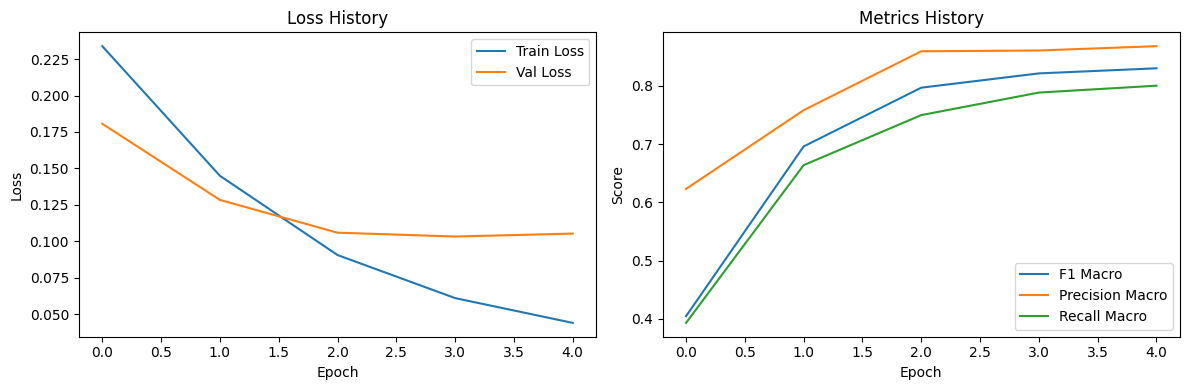

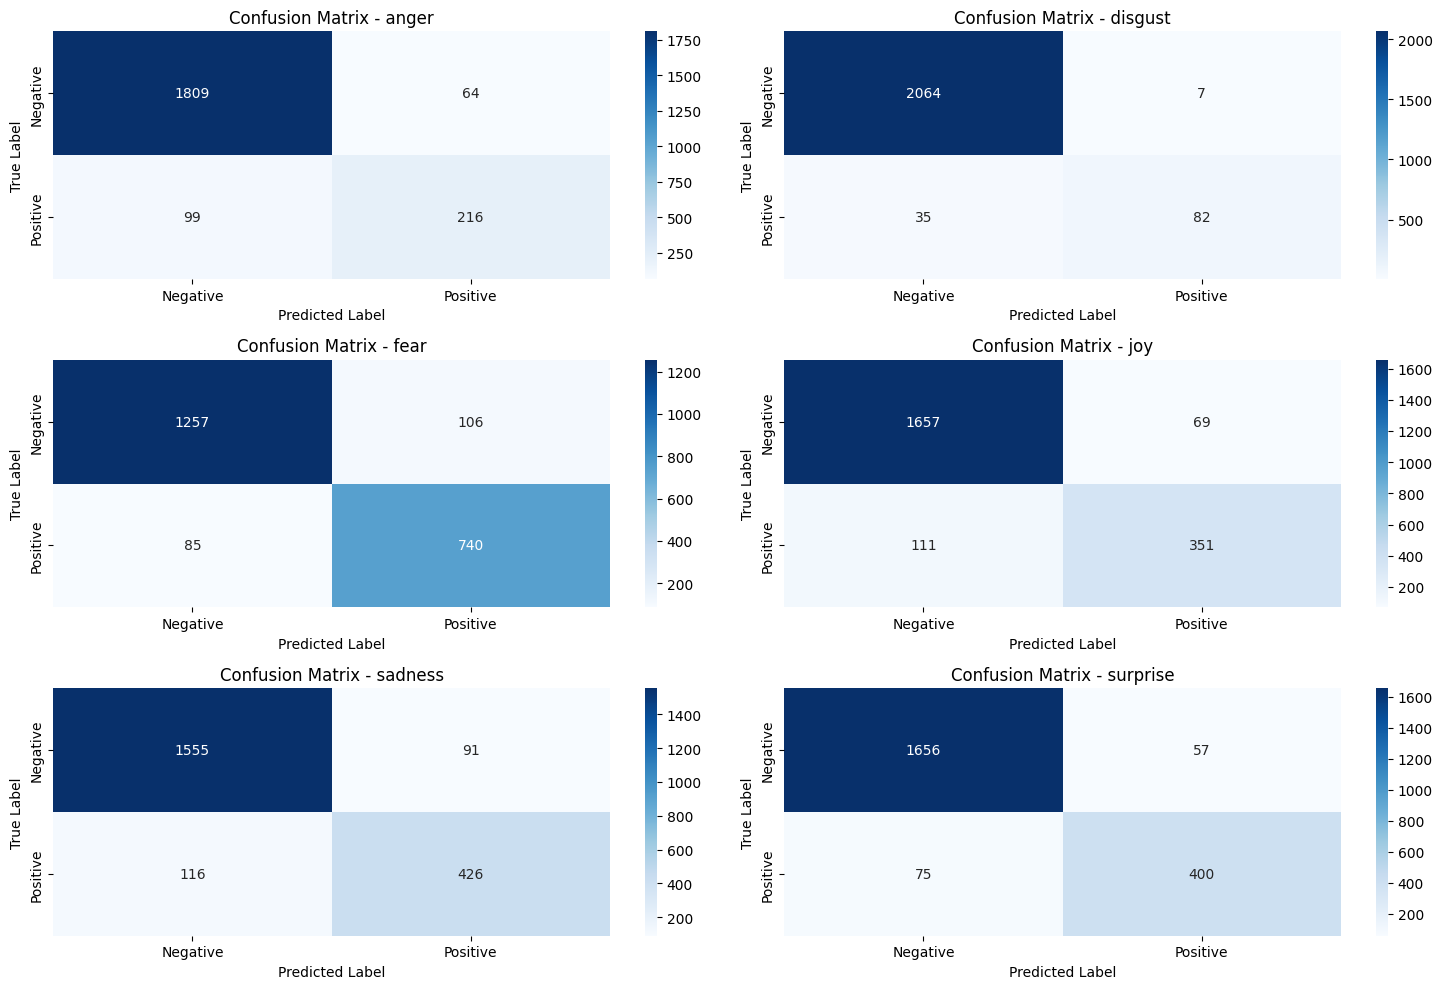


Analyzing sample text for interpretability (LIME):
Text: भाई, तुमने खुद घर छोड़ने का डिसीज़न लिया था, अब मुझे दोष मत दो !! और वैसे भी, मेरी कोई बात सुनते कब हो तुम ??
Target emotion: anger

Explanation for anger:
  र: -0.0992
  थ: 0.0927
  ब: -0.0780
  ह: -0.0664
  क: -0.0603
  भ: -0.0542
  अब: -0.0426
  नत: -0.0393
  कब: 0.0368
  म: 0.0238

Explanation for disgust:
  र: 0.0992
  थ: -0.0927
  ब: 0.0780
  ह: 0.0664
  क: 0.0603
  भ: 0.0542
  अब: 0.0426
  नत: 0.0393
  कब: -0.0368
  म: -0.0238

Explanation for fear:
  कब: -0.0377
  द: 0.0267
  ब: -0.0241
  र: -0.0210
  और: -0.0201
  म: 0.0195
  स: -0.0183
  ष: 0.0175
  थ: 0.0150
  मत: -0.0141

Explanation for joy:
  कब: 0.0377
  द: -0.0267
  ब: 0.0241
  र: 0.0210
  और: 0.0201
  म: -0.0195
  स: 0.0183
  ष: -0.0175
  थ: -0.0150
  मत: 0.0141

Explanation for sadness:
  स: 0.0419
  द: -0.0292
  त: 0.0223
  अब: -0.0217
  भ: -0.0216
  ह: -0.0202
  और: 0.0185
  नत: -0.0182
  क: -0.0153
  म: -0.0143

Explanation for surprise:
  स: -0.0419
  द: 0.02

<Figure size 1000x400 with 0 Axes>

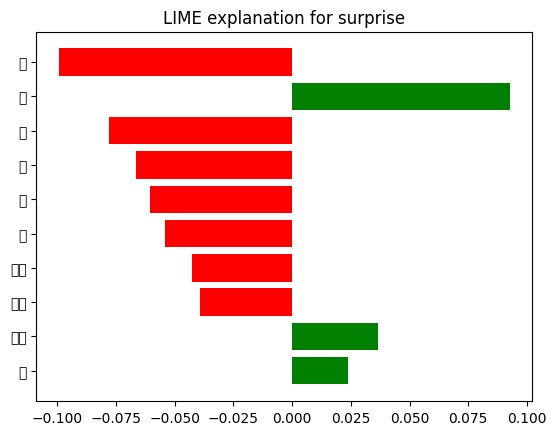


Visualizing attention weights:


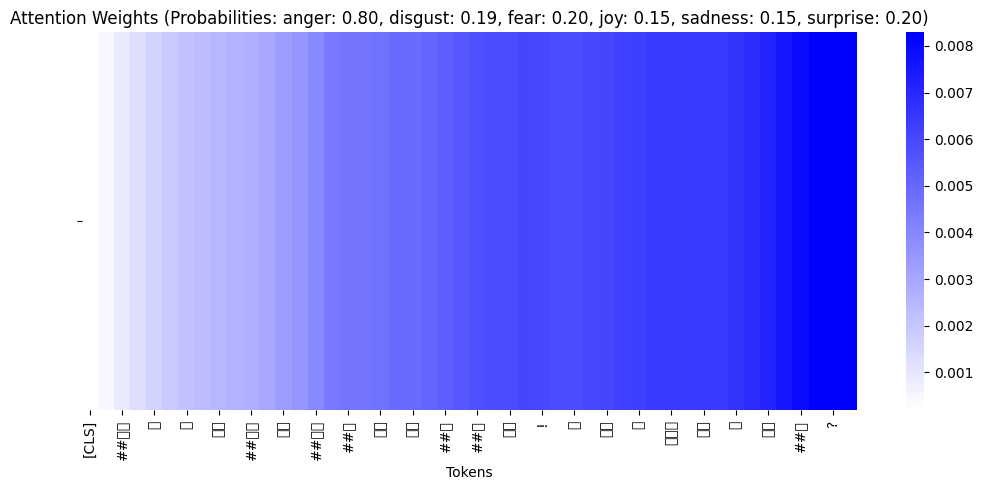


Analyzing sample text for interpretability (LIME):
Text: पहले विश्व युद्ध की विभीषिका ने मानवता को झकझोर दिया, और सैकड़ों हजारों लोगों को गहरे दुख में डाल दिया।
Target emotion: disgust

Explanation for anger:
  ल: -0.1191
  न: -0.0979
  म: -0.0891
  र: 0.0792
  स: 0.0764
  य: -0.0645
  द: 0.0588
  झकझ: -0.0548
  ड: 0.0519
  व: 0.0494

Explanation for disgust:
  ल: 0.1191
  न: 0.0979
  म: 0.0891
  र: -0.0792
  स: -0.0764
  य: 0.0645
  द: -0.0588
  झकझ: 0.0548
  ड: -0.0519
  व: -0.0494

Explanation for fear:
  द: 0.0566
  य: 0.0351
  स: 0.0318
  व: 0.0294
  नवत: 0.0245
  ख: -0.0215
  ग: 0.0192
  श: 0.0184
  ल: -0.0178
  ड: 0.0160

Explanation for joy:
  द: -0.0566
  य: -0.0351
  स: -0.0318
  व: -0.0294
  नवत: -0.0245
  ख: 0.0215
  ग: -0.0192
  श: -0.0184
  ल: 0.0178
  ड: -0.0160

Explanation for sadness:
  द: -0.0835
  व: -0.0667
  ल: 0.0666
  भ: -0.0654
  ड: -0.0609
  झकझ: -0.0444
  ष: -0.0396
  य: 0.0371
  क: -0.0362
  हज: 0.0250

Explanation for surprise:
  द: 0.0835
  व: 0.0667
  ल:

<Figure size 1000x400 with 0 Axes>

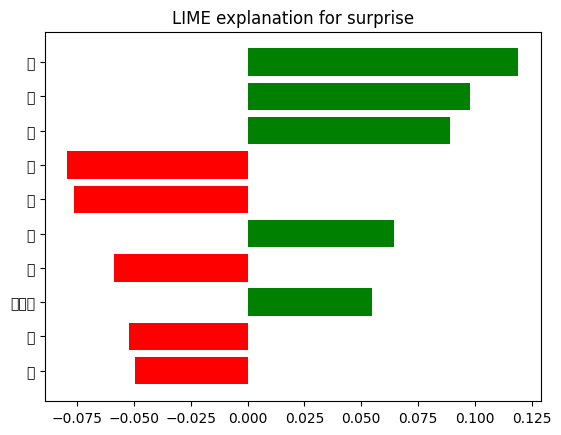


Visualizing attention weights:


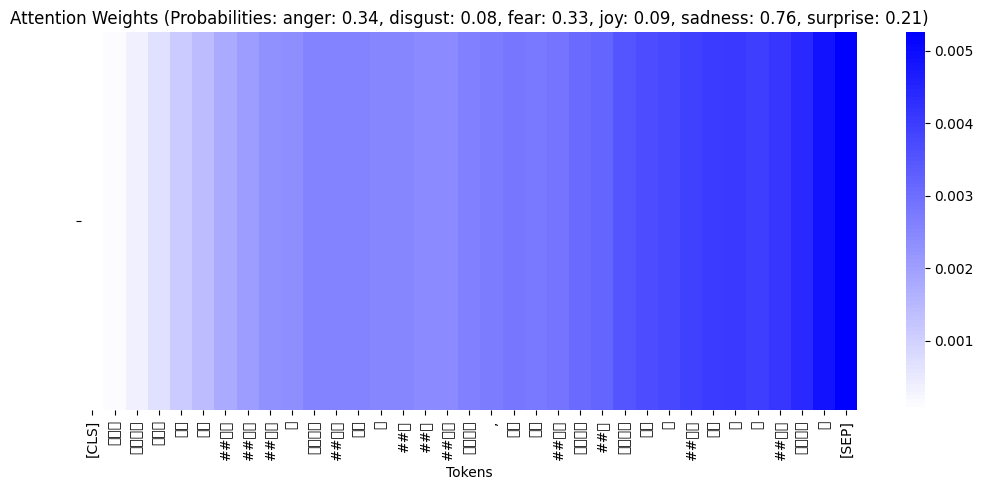


Analyzing sample text for interpretability (LIME):
Text: She left in a huge hurry leaving me with the overflowing toilet after her giant dump.
Target emotion: fear

Explanation for anger:
  dump: -0.3930
  me: -0.0815
  hurry: 0.0690
  her: -0.0599
  leaving: -0.0486
  toilet: 0.0424
  She: -0.0342
  in: 0.0198
  left: -0.0196
  after: -0.0163

Explanation for disgust:
  dump: 0.3930
  me: 0.0815
  hurry: -0.0690
  her: 0.0599
  leaving: 0.0486
  toilet: -0.0424
  She: 0.0342
  in: -0.0198
  left: 0.0196
  after: 0.0163

Explanation for fear:
  dump: -0.0209
  hurry: 0.0089
  She: -0.0067
  her: -0.0066
  overflowing: 0.0056
  me: -0.0052
  in: 0.0036
  giant: -0.0036
  leaving: 0.0034
  huge: -0.0027

Explanation for joy:
  dump: 0.0209
  hurry: -0.0089
  She: 0.0067
  her: 0.0066
  overflowing: -0.0056
  me: 0.0052
  in: -0.0036
  giant: 0.0036
  leaving: -0.0034
  huge: 0.0027

Explanation for sadness:
  hurry: -0.1501
  overflowing: -0.1459
  leaving: -0.0885
  her: 0.0748
  huge:

<Figure size 1000x400 with 0 Axes>

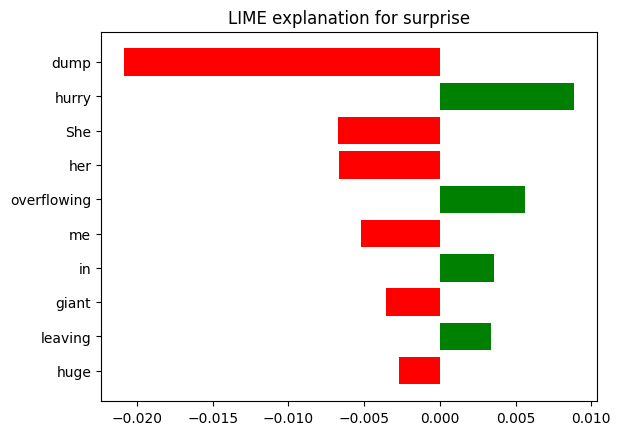


Visualizing attention weights:


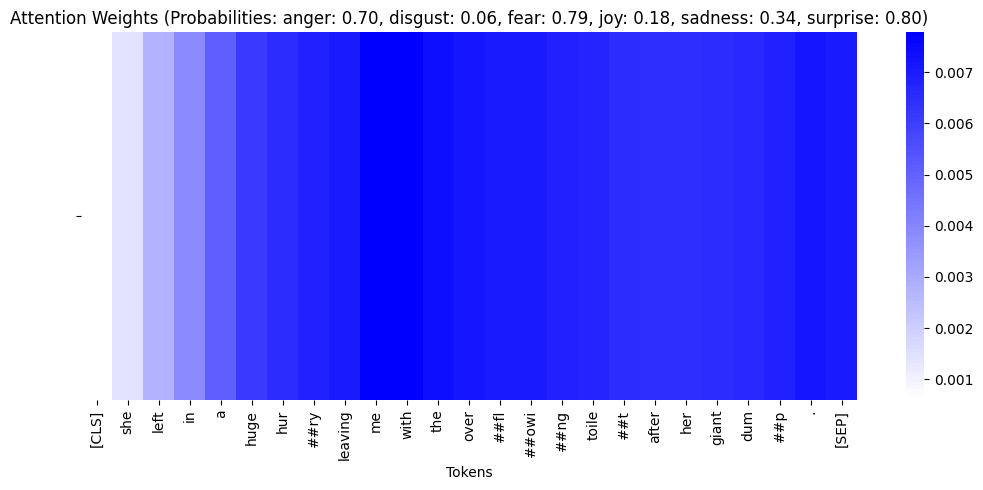


Analyzing sample text for interpretability (LIME):
Text: See, I saw the movie trailer first, and it looked interesting, ( and, yes, I do have a bit of a crush on Pattinson ) and in my head I made up my own story.
Target emotion: joy

Explanation for anger:
  my: 0.0366
  crush: -0.0351
  head: 0.0196
  looked: 0.0178
  story: 0.0166
  Pattinson: 0.0117
  a: -0.0085
  movie: 0.0070
  made: -0.0063
  yes: -0.0062

Explanation for disgust:
  my: -0.0366
  crush: 0.0351
  head: -0.0196
  looked: -0.0178
  story: -0.0166
  Pattinson: -0.0117
  a: 0.0085
  movie: -0.0070
  made: 0.0063
  yes: 0.0062

Explanation for fear:
  my: 0.0086
  head: 0.0083
  interesting: -0.0072
  Pattinson: -0.0048
  See: -0.0037
  story: 0.0030
  trailer: 0.0028
  bit: -0.0021
  yes: -0.0021
  made: -0.0020

Explanation for joy:
  my: -0.0086
  head: -0.0083
  interesting: 0.0072
  Pattinson: 0.0048
  See: 0.0037
  story: -0.0030
  trailer: -0.0028
  bit: 0.0021
  yes: 0.0021
  made: 0.0020

Explanation for sadn

<Figure size 1000x400 with 0 Axes>

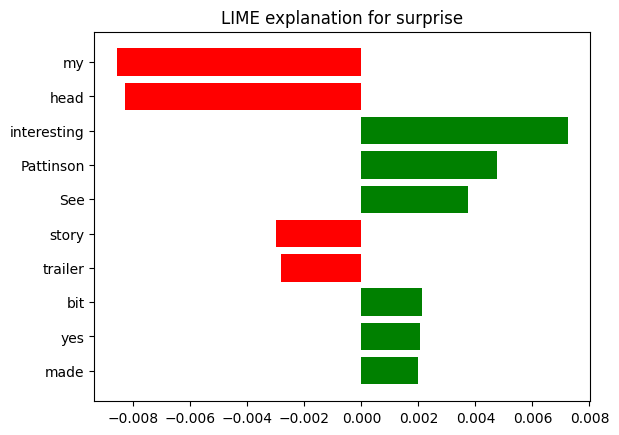


Visualizing attention weights:


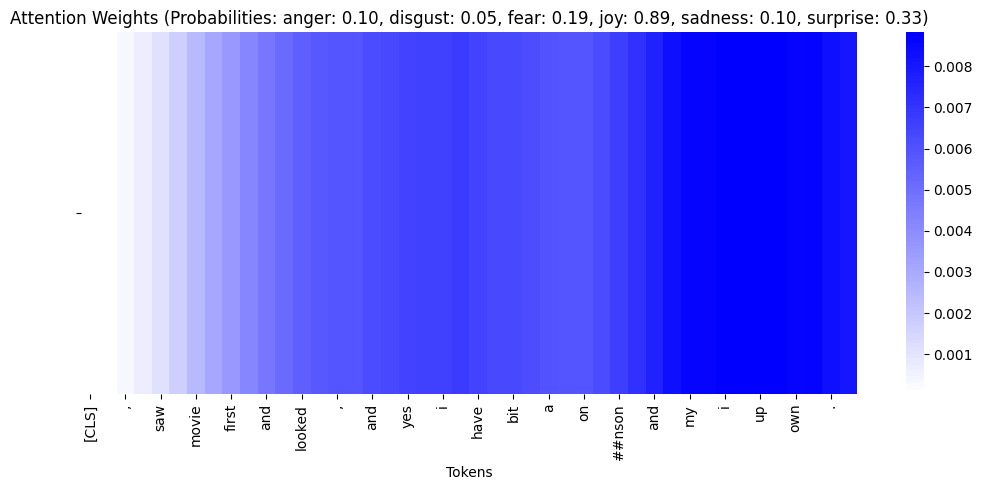


Analyzing sample text for interpretability (LIME):
Text: The whole house and the people and the flame seemed to vanish and leave me in an endless darkness as soon as my eyes were closed.
Target emotion: sadness

Explanation for anger:
  vanish: -0.0190
  seemed: 0.0175
  eyes: 0.0160
  me: -0.0153
  my: 0.0146
  leave: -0.0137
  closed: -0.0128
  the: 0.0095
  flame: -0.0088
  as: 0.0070

Explanation for disgust:
  vanish: 0.0190
  seemed: -0.0175
  eyes: -0.0160
  me: 0.0153
  my: -0.0146
  leave: 0.0137
  closed: 0.0128
  the: -0.0095
  flame: 0.0088
  as: -0.0070

Explanation for fear:
  my: -0.0034
  closed: 0.0028
  darkness: 0.0019
  me: -0.0017
  house: -0.0011
  seemed: 0.0011
  the: -0.0011
  as: -0.0011
  soon: 0.0010
  The: -0.0009

Explanation for joy:
  my: 0.0034
  closed: -0.0028
  darkness: -0.0019
  me: 0.0017
  house: 0.0011
  seemed: -0.0011
  the: 0.0011
  as: 0.0011
  soon: -0.0010
  The: 0.0009

Explanation for sadness:
  darkness: -0.1900
  vanish: -0.1025
  end

<Figure size 1000x400 with 0 Axes>

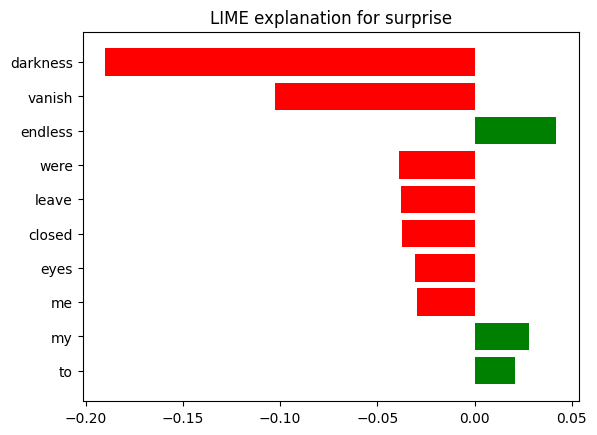


Visualizing attention weights:


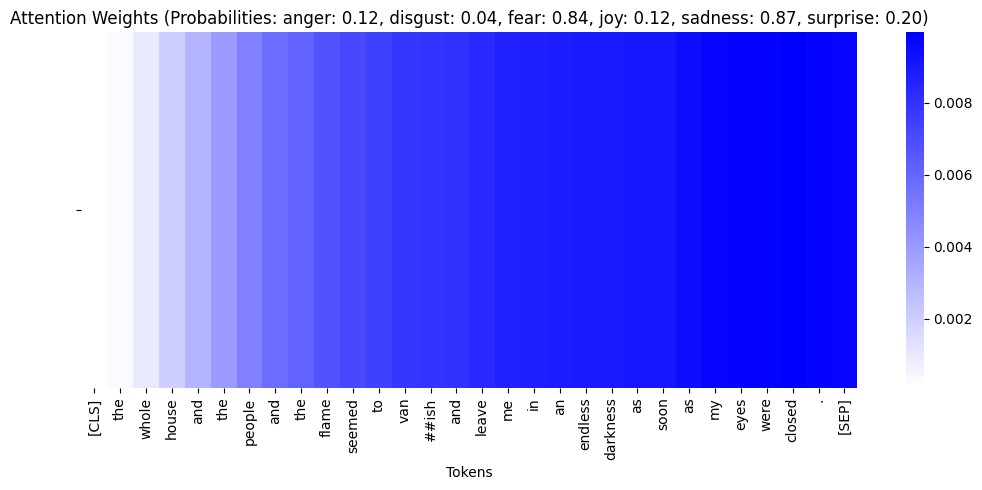


Training multilingual model for languages: hi, mr
Using model: bert-base-multilingual-uncased
Loss function: weighted_bce
Verifying extracted dataset structure in ./data/track_a...

Extracted dataset structure is correct!
Found files:
  ./data/track_a/train/en/data.csv
  ./data/track_a/train/hi/data.csv
  ./data/track_a/train/mr/data.csv
  ./data/track_a/dev/en/data.csv
  ./data/track_a/dev/hi/data.csv
  ./data/track_a/dev/mr/data.csv
  ./data/track_a/test/en/data.csv
  ./data/track_a/test/hi/data.csv
  ./data/track_a/test/mr/data.csv

Dataset for language 'hi':
Shape: (2656, 8)
Columns: ['id', 'text', 'anger', 'disgust', 'fear', 'joy', 'sadness', 'surprise']

Class distribution:
anger: 438 (16.49%)
disgust: 275 (10.35%)
fear: 394 (14.83%)
joy: 453 (17.06%)
sadness: 466 (17.55%)
surprise: 287 (10.81%)
Verifying extracted dataset structure in ./data/track_a...

Extracted dataset structure is correct!
Found files:
  ./data/track_a/train/en/data.csv
  ./data/track_a/train/hi/data.csv
  .

Evaluating: 100%|██████████| 55/55 [00:07<00:00,  7.40it/s]


Train Loss: 0.4083
Val Loss: 0.3152
F1 Macro: 0.2270
Precision Macro: 0.2102
Recall Macro: 0.2475
Hamming Loss: 0.1830
Jaccard Score: 0.2077
New best model saved with F1 Macro: 0.2270

Epoch 2/5


Evaluating: 100%|██████████| 55/55 [00:07<00:00,  7.39it/s]


Train Loss: 0.2717
Val Loss: 0.2282
F1 Macro: 0.5447
Precision Macro: 0.8191
Recall Macro: 0.4865
Hamming Loss: 0.1360
Jaccard Score: 0.4273
New best model saved with F1 Macro: 0.5447

Epoch 3/5


...

Train Loss: 0.1421
Val Loss: 0.1799
F1 Macro: 0.7420
Precision Macro: 0.8164
Recall Macro: 0.6913
Hamming Loss: 0.0997
Jaccard Score: 0.5657
New best model saved with F1 Macro: 0.7420

Epoch 5/5


Evaluating: 100%|██████████| 55/55 [00:07<00:00,  7.36it/s]


Train Loss: 0.1145
Val Loss: 0.1757
F1 Macro: 0.7637
Precision Macro: 0.8220
Recall Macro: 0.7179
Hamming Loss: 0.0917
Jaccard Score: 0.5992
New best model saved with F1 Macro: 0.7637


Evaluating: 100%|██████████| 137/137 [00:18<00:00,  7.37it/s]



Test Results:
F1 Macro: 0.7577
Precision Macro: 0.8237
Recall Macro: 0.7046
Hamming Loss: 0.0932
Jaccard Score: 0.5889

Detailed Classification Report:
              precision    recall  f1-score   support

       anger       0.74      0.60      0.66       315
     disgust       0.94      0.72      0.82       117
        fear       0.80      0.84      0.82       825
         joy       0.83      0.68      0.74       462
     sadness       0.77      0.65      0.71       542
    surprise       0.86      0.74      0.79       475

   micro avg       0.81      0.72      0.76      2736
   macro avg       0.82      0.70      0.76      2736
weighted avg       0.81      0.72      0.76      2736
 samples avg       0.65      0.63      0.62      2736



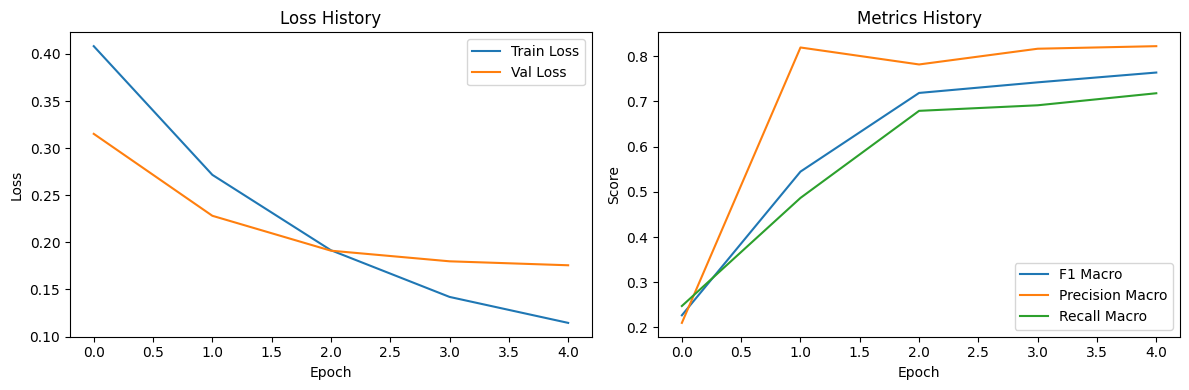

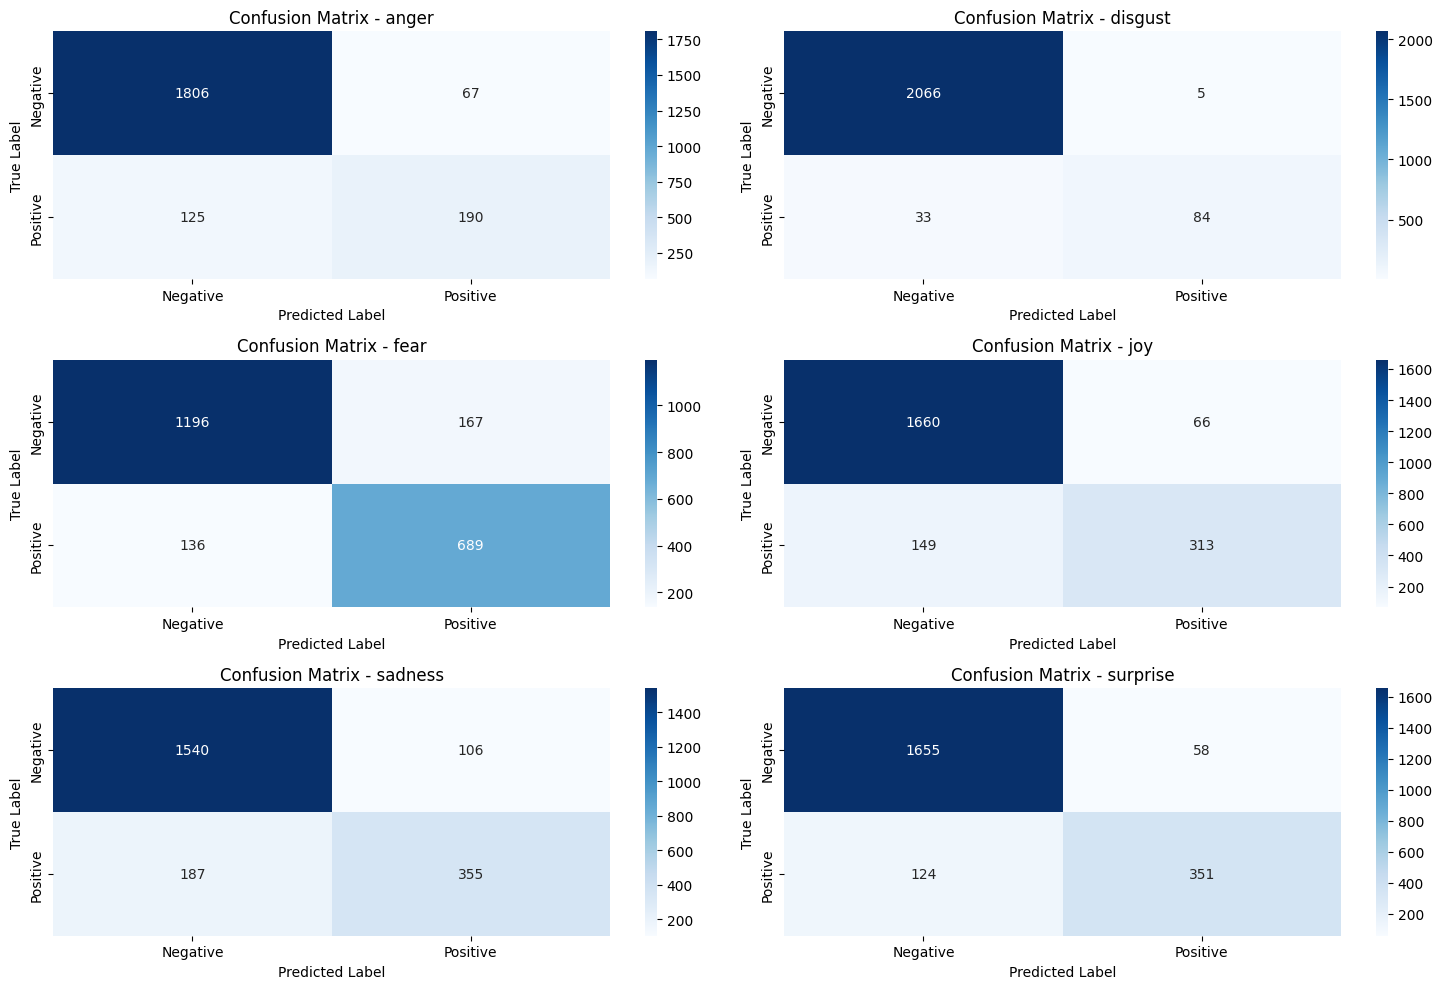


Analyzing sample text for interpretability (LIME):
Text: घराची सजावट इतकी बेजबाबदारपणे केली आहे, पाहून मला खूप राग आला.
Target emotion: anger

Explanation for anger:
  र: -0.5627
  ग: -0.5361
  च: 0.0537
  आल: -0.0467
  बद: -0.0367
  ल: -0.0330
  क: -0.0250
  वट: 0.0212
  प: 0.0166
  न: 0.0133

Explanation for disgust:
  र: 0.5627
  ग: 0.5361
  च: -0.0537
  आल: 0.0467
  बद: 0.0367
  ल: 0.0330
  क: 0.0250
  वट: -0.0212
  प: -0.0166
  न: -0.0133

Explanation for fear:
  र: -0.0139
  ग: -0.0110
  च: 0.0026
  वट: 0.0018
  बद: -0.0016
  क: -0.0015
  प: -0.0014
  घर: -0.0011
  न: 0.0010
  आह: 0.0009

Explanation for joy:
  र: 0.0139
  ग: 0.0110
  च: -0.0026
  वट: -0.0018
  बद: 0.0016
  क: 0.0015
  प: 0.0014
  घर: 0.0011
  न: -0.0010
  आह: -0.0009

Explanation for sadness:
  ग: 0.1012
  र: 0.0509
  ख: -0.0320
  ब: 0.0294
  आल: -0.0281
  मल: -0.0241
  बद: 0.0210
  न: 0.0208
  च: -0.0180
  प: -0.0157

Explanation for surprise:
  ग: -0.1012
  र: -0.0509
  ख: 0.0320
  ब: -0.0294
  आल: 0.0281
  म

<Figure size 1000x400 with 0 Axes>

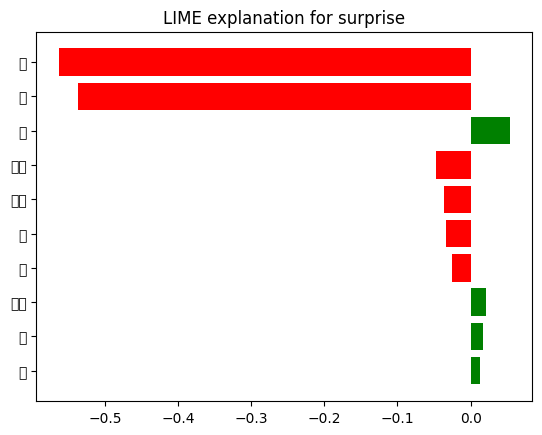


Visualizing attention weights:


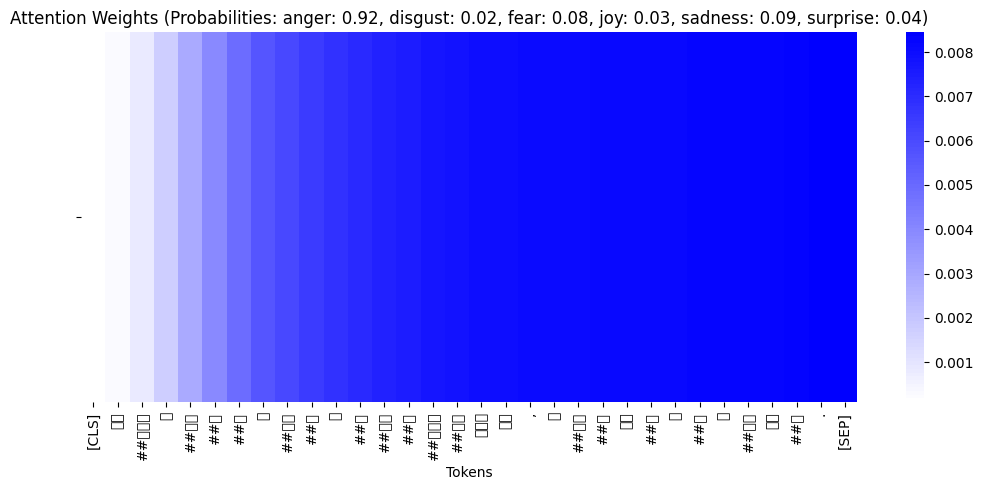


Analyzing sample text for interpretability (LIME):
Text: कुटुंबातील वादांमुळे इतक्या कुरूप घटना घडत आहेत हे पाहून माझ्या मनात अपार तिरस्कार आणि घृणा निर्माण झाली आहे.
Target emotion: disgust

Explanation for anger:
  घ: 0.1092
  रस: 0.0609
  ण: 0.0553
  ट: -0.0423
  क: 0.0397
  घडत: -0.0360
  अप: -0.0337
  म: 0.0275
  प: 0.0260
  इतक: 0.0207

Explanation for disgust:
  घ: -0.1092
  रस: -0.0609
  ण: -0.0553
  ट: 0.0423
  क: -0.0397
  घडत: 0.0360
  अप: 0.0337
  म: -0.0275
  प: -0.0260
  इतक: -0.0207

Explanation for fear:
  घ: -0.4658
  ण: -0.2688
  त: -0.2119
  रस: -0.2001
  क: -0.1321
  आह: -0.0709
  आण: -0.0648
  द: 0.0609
  व: 0.0365
  अप: 0.0299

Explanation for joy:
  घ: 0.4658
  ण: 0.2688
  त: 0.2119
  रस: 0.2001
  क: 0.1321
  आह: 0.0709
  आण: 0.0648
  द: -0.0609
  व: -0.0365
  अप: -0.0299

Explanation for sadness:
  घ: 0.0855
  ण: 0.0344
  त: 0.0318
  रस: 0.0298
  आण: 0.0266
  ब: 0.0226
  द: -0.0206
  न: -0.0181
  व: -0.0172
  इतक: -0.0133

Explanation for surprise:
  घ: -0.0855

<Figure size 1000x400 with 0 Axes>

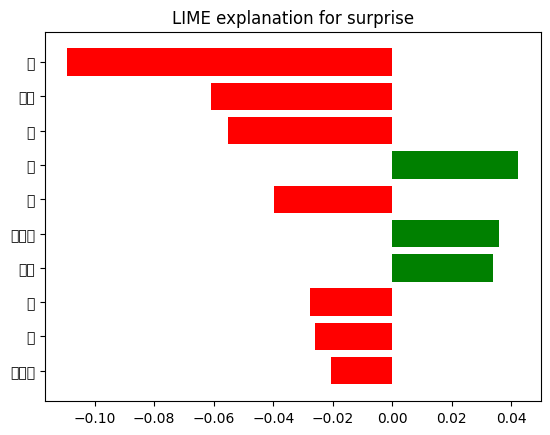


Visualizing attention weights:


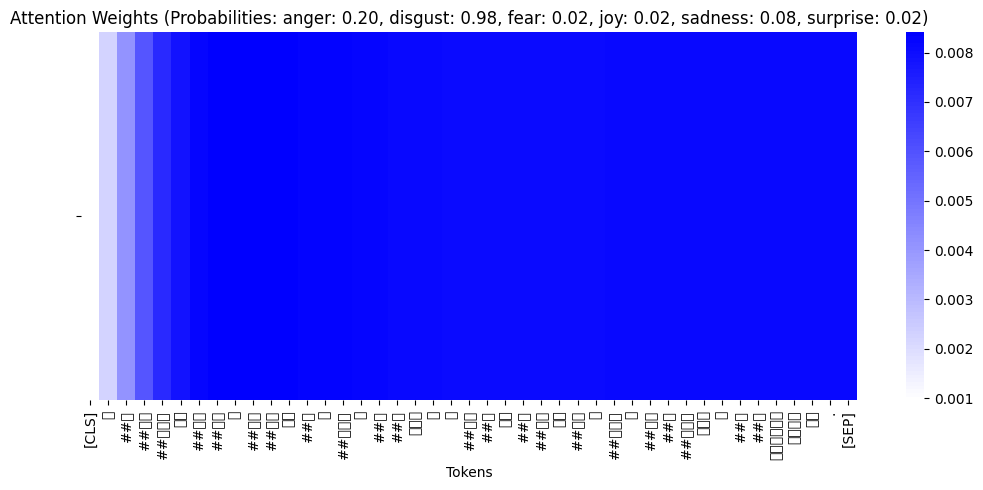


Analyzing sample text for interpretability (LIME):
Text: .....[dispatcher must be talking]
Target emotion: fear

Explanation for anger:
  dispatcher: 0.0569
  be: 0.0398
  talking: 0.0125
  must: -0.0120

Explanation for disgust:
  dispatcher: -0.0569
  be: -0.0398
  talking: -0.0125
  must: 0.0120

Explanation for fear:
  talking: 0.0002
  be: 0.0002
  must: 0.0001
  dispatcher: 0.0000

Explanation for joy:
  talking: -0.0002
  be: -0.0002
  must: -0.0001
  dispatcher: -0.0000

Explanation for sadness:
  must: -0.1804
  talking: -0.1200
  be: -0.0232
  dispatcher: 0.0218

Explanation for surprise:
  must: 0.1804
  talking: 0.1200
  be: 0.0232
  dispatcher: -0.0218


<Figure size 1000x400 with 0 Axes>

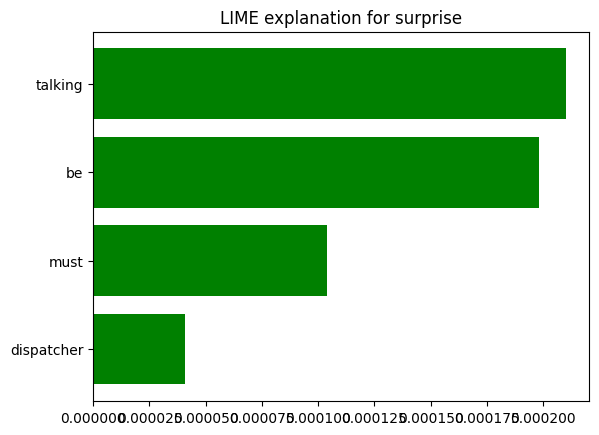


Visualizing attention weights:


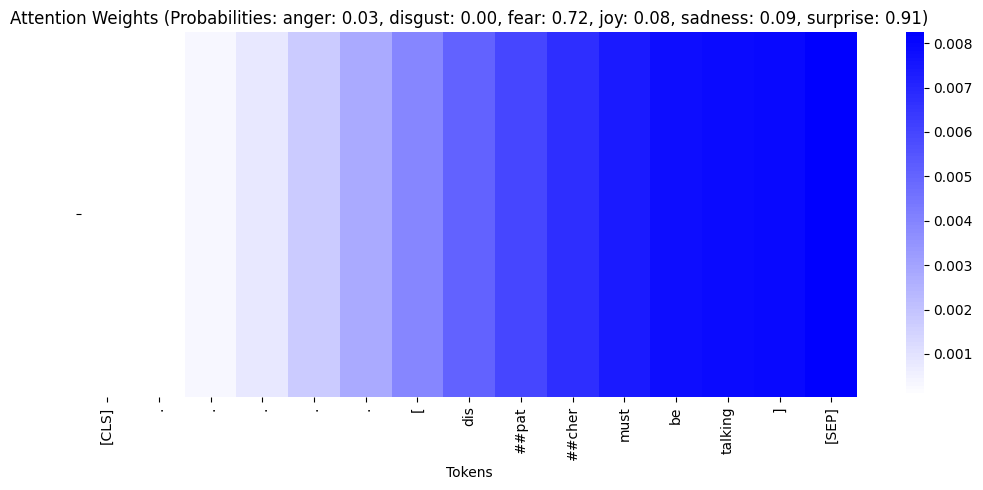


Analyzing sample text for interpretability (LIME):
Text: योग आणि ध्यानामुळे मानसिक शांती मिळते आणि शारीरिक स्वास्थ्यही सुधारते.
Target emotion: joy

Explanation for anger:
  रत: 0.0263
  ध: 0.0223
  श: 0.0175
  म: -0.0152
  आण: -0.0147
  क: 0.0141
  नस: 0.0128
  ळ: -0.0126
  र: 0.0111
  ग: -0.0094

Explanation for disgust:
  रत: -0.0263
  ध: -0.0223
  श: -0.0175
  म: 0.0152
  आण: 0.0147
  क: -0.0141
  नस: -0.0128
  ळ: 0.0126
  र: -0.0111
  ग: 0.0094

Explanation for fear:
  रत: 0.0008
  य: -0.0007
  श: 0.0007
  आण: -0.0007
  ध: 0.0006
  नस: 0.0005
  र: 0.0003
  यह: 0.0003
  स: -0.0003
  म: -0.0002

Explanation for joy:
  रत: -0.0008
  य: 0.0007
  श: -0.0007
  आण: 0.0007
  ध: -0.0006
  नस: -0.0005
  र: -0.0003
  यह: -0.0003
  स: 0.0003
  म: 0.0002

Explanation for sadness:
  य: 0.0341
  स: 0.0267
  श: -0.0208
  आण: 0.0198
  र: -0.0169
  ध: 0.0152
  म: -0.0132
  त: -0.0119
  ळ: -0.0093
  व: 0.0077

Explanation for surprise:
  य: -0.0341
  स: -0.0267
  श: 0.0208
  आण: -0.0198
  र: 0.0169

<Figure size 1000x400 with 0 Axes>

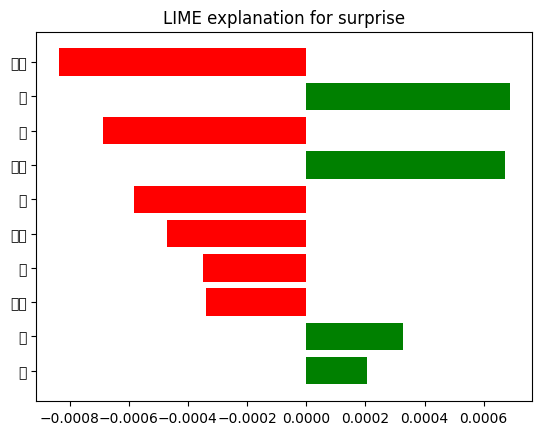


Visualizing attention weights:


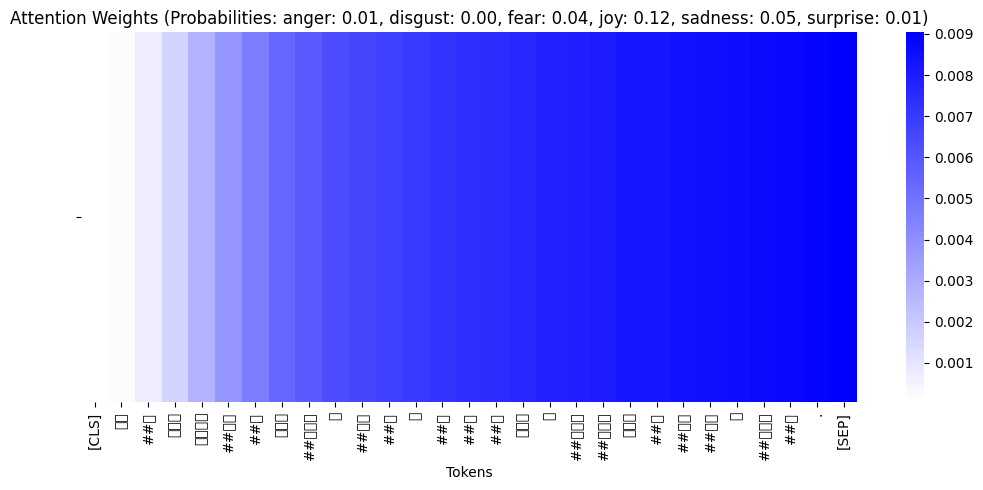


Analyzing sample text for interpretability (LIME):
Text: Guess it's more sad than creepy.
Target emotion: sadness

Explanation for anger:
  creepy: 0.0117
  than: -0.0056
  it: 0.0053
  sad: 0.0037
  more: 0.0034
  s: 0.0016
  Guess: -0.0004

Explanation for disgust:
  creepy: -0.0117
  than: 0.0056
  it: -0.0053
  sad: -0.0037
  more: -0.0034
  s: -0.0016
  Guess: 0.0004

Explanation for fear:
  creepy: 0.0009
  than: -0.0003
  sad: 0.0003
  Guess: 0.0002
  more: -0.0001
  it: 0.0001
  s: 0.0000

Explanation for joy:
  creepy: -0.0009
  than: 0.0003
  sad: -0.0003
  Guess: -0.0002
  more: 0.0001
  it: -0.0001
  s: -0.0000

Explanation for sadness:
  creepy: -0.3006
  sad: -0.1883
  Guess: -0.0520
  more: 0.0443
  than: 0.0229
  s: -0.0166
  it: -0.0005

Explanation for surprise:
  creepy: 0.3006
  sad: 0.1883
  Guess: 0.0520
  more: -0.0443
  than: -0.0229
  s: 0.0166
  it: 0.0005


<Figure size 1000x400 with 0 Axes>

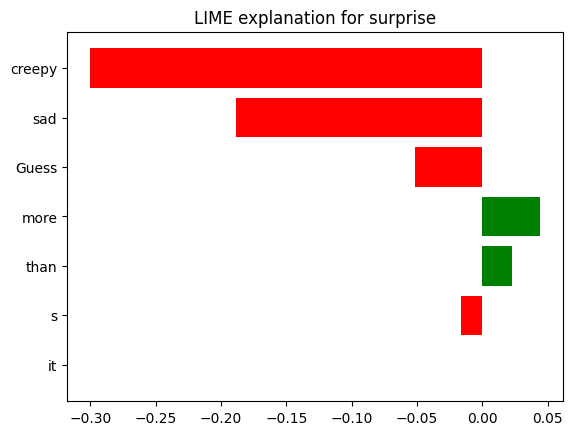


Visualizing attention weights:


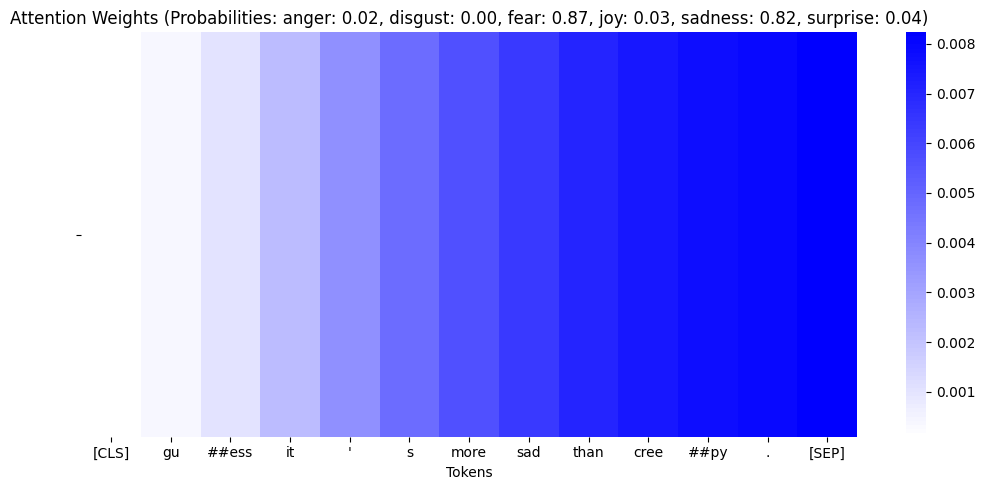


Training multilingual model for languages: hi, mr
Using model: bert-base-multilingual-uncased
Loss function: comet
Verifying extracted dataset structure in ./data/track_a...

Extracted dataset structure is correct!
Found files:
  ./data/track_a/train/en/data.csv
  ./data/track_a/train/hi/data.csv
  ./data/track_a/train/mr/data.csv
  ./data/track_a/dev/en/data.csv
  ./data/track_a/dev/hi/data.csv
  ./data/track_a/dev/mr/data.csv
  ./data/track_a/test/en/data.csv
  ./data/track_a/test/hi/data.csv
  ./data/track_a/test/mr/data.csv

Dataset for language 'hi':
Shape: (2656, 8)
Columns: ['id', 'text', 'anger', 'disgust', 'fear', 'joy', 'sadness', 'surprise']

Class distribution:
anger: 438 (16.49%)
disgust: 275 (10.35%)
fear: 394 (14.83%)
joy: 453 (17.06%)
sadness: 466 (17.55%)
surprise: 287 (10.81%)
Verifying extracted dataset structure in ./data/track_a...

Extracted dataset structure is correct!
Found files:
  ./data/track_a/train/en/data.csv
  ./data/track_a/train/hi/data.csv
  ./data/t

Evaluating: 100%|██████████| 55/55 [00:07<00:00,  6.94it/s]


Train Loss: 0.2361
Val Loss: 0.1910
F1 Macro: 0.3687
Precision Macro: 0.4757
Recall Macro: 0.3748
Hamming Loss: 0.1625
Jaccard Score: 0.3595
New best model saved with F1 Macro: 0.3687

Epoch 2/5


Evaluating: 100%|██████████| 55/55 [00:07<00:00,  7.29it/s]


Train Loss: 0.1538
Val Loss: 0.1382
F1 Macro: 0.6583
Precision Macro: 0.7584
Recall Macro: 0.6241
Hamming Loss: 0.1060
Jaccard Score: 0.5468
New best model saved with F1 Macro: 0.6583

Epoch 3/5


...

Train Loss: 0.0653
Val Loss: 0.1061
F1 Macro: 0.8263
Precision Macro: 0.8659
Recall Macro: 0.7940
Hamming Loss: 0.0632
Jaccard Score: 0.6759
New best model saved with F1 Macro: 0.8263

Epoch 5/5


Evaluating: 100%|██████████| 55/55 [00:07<00:00,  7.38it/s]


Train Loss: 0.0467
Val Loss: 0.1060
F1 Macro: 0.8313
Precision Macro: 0.8662
Recall Macro: 0.8034
Hamming Loss: 0.0618
Jaccard Score: 0.6809
New best model saved with F1 Macro: 0.8313


Evaluating: 100%|██████████| 137/137 [00:18<00:00,  7.31it/s]



Test Results:
F1 Macro: 0.8043
Precision Macro: 0.8494
Recall Macro: 0.7678
Hamming Loss: 0.0722
Jaccard Score: 0.6593

Detailed Classification Report:
              precision    recall  f1-score   support

       anger       0.81      0.64      0.72       315
     disgust       0.90      0.71      0.79       117
        fear       0.86      0.90      0.88       825
         joy       0.85      0.74      0.79       462
     sadness       0.80      0.78      0.79       542
    surprise       0.88      0.83      0.85       475

   micro avg       0.85      0.80      0.82      2736
   macro avg       0.85      0.77      0.80      2736
weighted avg       0.84      0.80      0.82      2736
 samples avg       0.70      0.69      0.68      2736



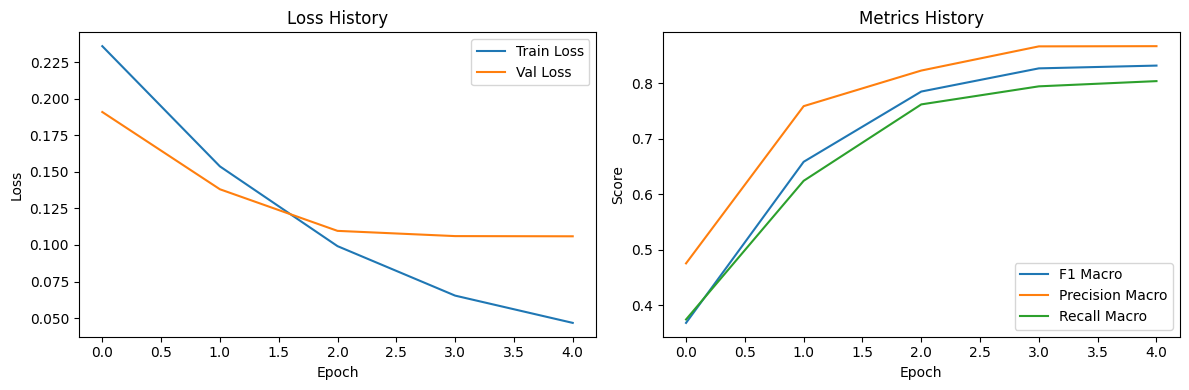

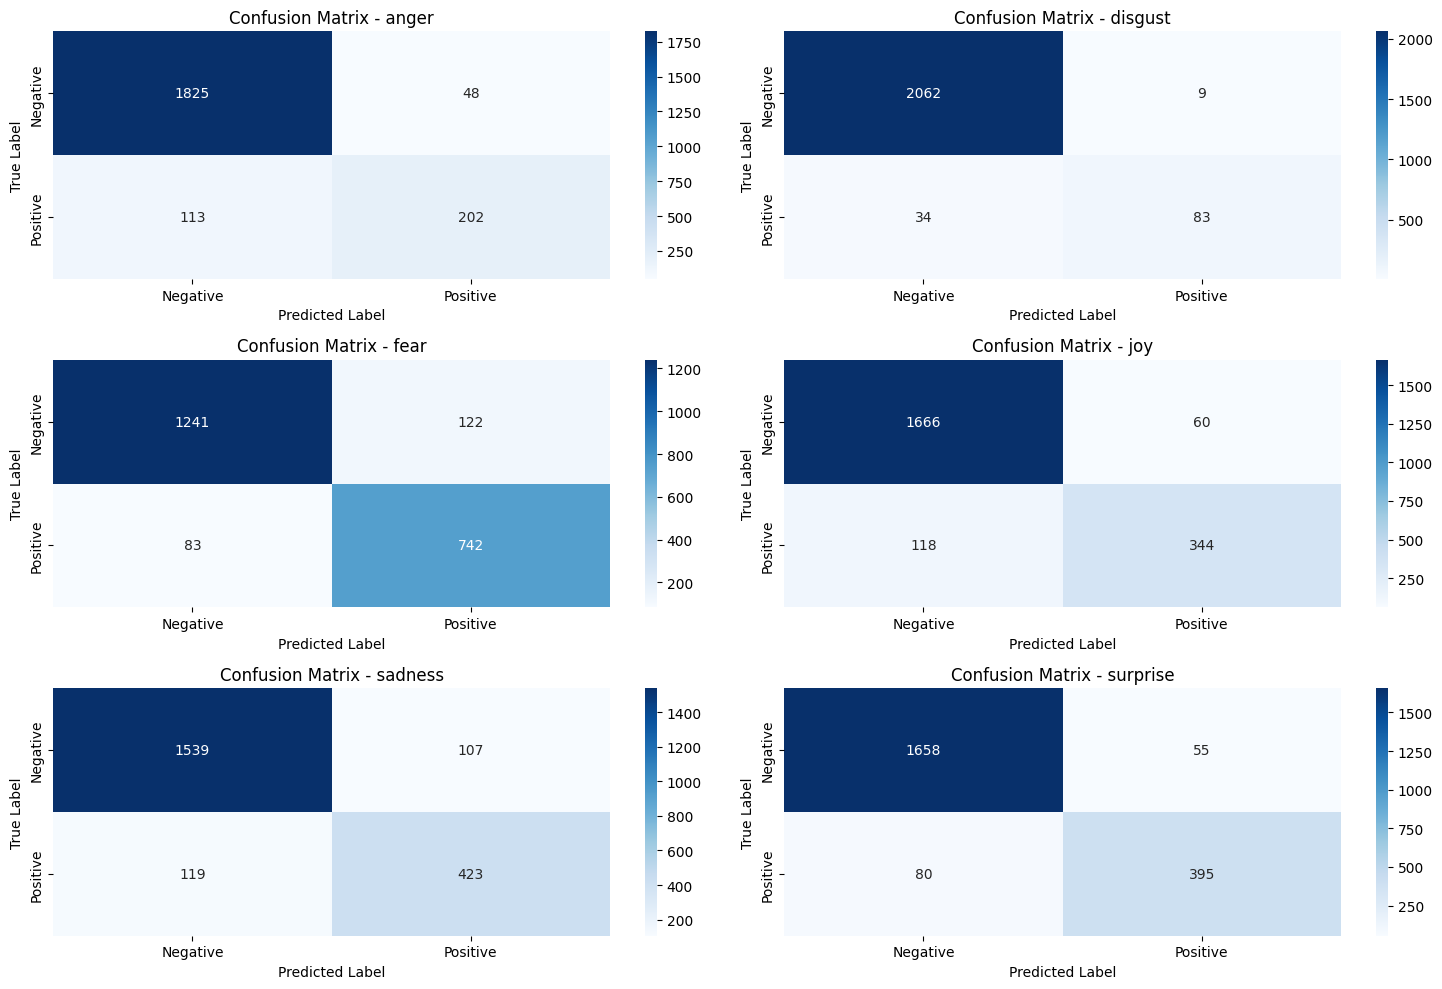


Analyzing sample text for interpretability (LIME):
Text: After that we took a taxi home... Right now my leg hurts and while im typing this the photos are uploading... see ya...
Target emotion: anger

Explanation for anger:
  uploading: -0.2355
  hurts: -0.2104
  my: 0.1302
  typing: -0.0978
  see: 0.0611
  photos: 0.0566
  are: -0.0466
  now: 0.0396
  ya: -0.0379
  this: -0.0342

Explanation for disgust:
  uploading: 0.2355
  hurts: 0.2104
  my: -0.1302
  typing: 0.0978
  see: -0.0611
  photos: -0.0566
  are: 0.0466
  now: -0.0396
  ya: 0.0379
  this: 0.0342

Explanation for fear:
  hurts: -0.0214
  uploading: -0.0123
  typing: -0.0090
  my: 0.0085
  see: 0.0051
  taxi: 0.0041
  and: -0.0035
  while: 0.0031
  photos: 0.0030
  are: -0.0029

Explanation for joy:
  hurts: 0.0214
  uploading: 0.0123
  typing: 0.0090
  my: -0.0085
  see: -0.0051
  taxi: -0.0041
  and: 0.0035
  while: -0.0031
  photos: -0.0030
  are: 0.0029

Explanation for sadness:
  hurts: -0.2386
  uploading: -0.1193
  t

<Figure size 1000x400 with 0 Axes>

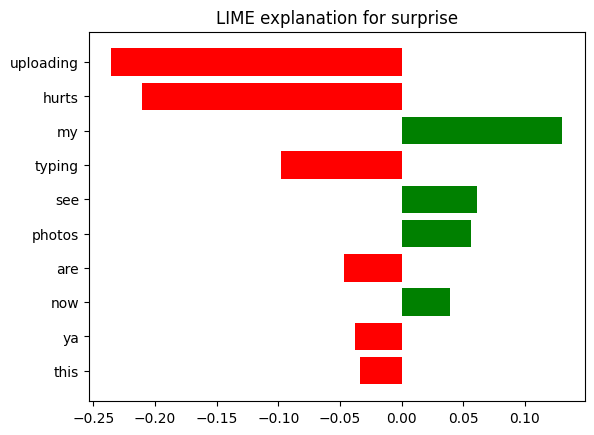


Visualizing attention weights:


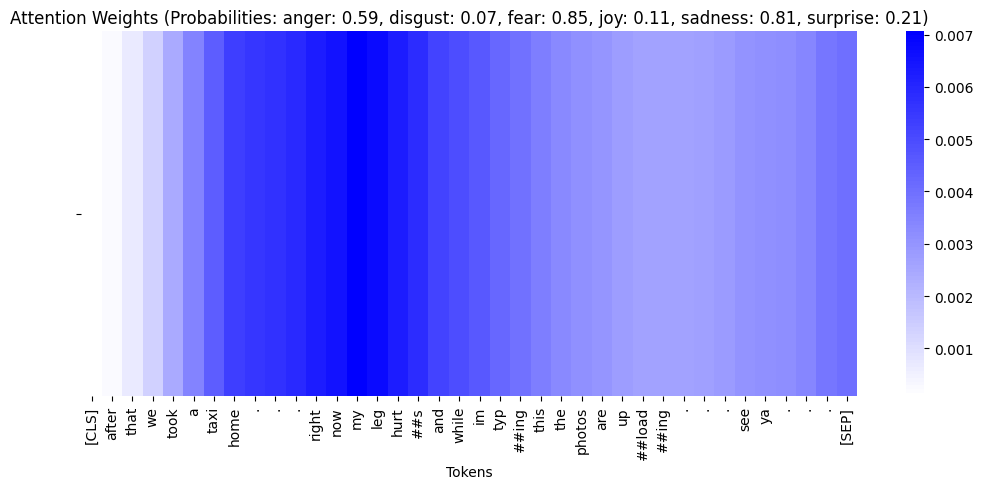


Analyzing sample text for interpretability (LIME):
Text: हे शूज माझ्या लुकला खराब करत आहेत; त्याकडे बघूनदेखील मला शिसारी येते आहे
Target emotion: disgust

Explanation for anger:
  ब: -0.0532
  स: -0.0522
  खर: -0.0351
  बघ: -0.0276
  ह: -0.0270
  कड: -0.0256
  करत: -0.0242
  ज: -0.0216
  ख: -0.0212
  आह: 0.0181

Explanation for disgust:
  ब: 0.0532
  स: 0.0522
  खर: 0.0351
  बघ: 0.0276
  ह: 0.0270
  कड: 0.0256
  करत: 0.0242
  ज: 0.0216
  ख: 0.0212
  आह: -0.0181

Explanation for fear:
  खर: -0.1277
  श: -0.1269
  बघ: -0.1110
  मल: -0.1083
  ब: -0.0838
  स: -0.0809
  र: -0.0587
  ल: -0.0397
  आह: -0.0396
  कड: -0.0387

Explanation for joy:
  खर: 0.1277
  श: 0.1269
  बघ: 0.1110
  मल: 0.1083
  ब: 0.0838
  स: 0.0809
  र: 0.0587
  ल: 0.0397
  आह: 0.0396
  कड: 0.0387

Explanation for sadness:
  श: -0.0421
  स: -0.0268
  र: 0.0236
  मल: 0.0203
  य: -0.0186
  खर: -0.0176
  त: -0.0167
  करत: -0.0166
  म: -0.0147
  कड: -0.0104

Explanation for surprise:
  श: 0.0421
  स: 0.0268
  र: -0.0236
  मल:

<Figure size 1000x400 with 0 Axes>

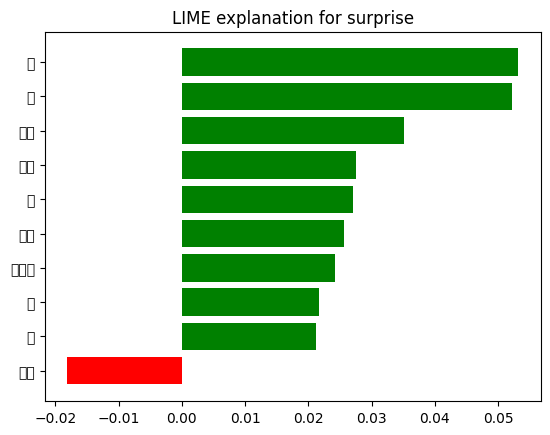


Visualizing attention weights:


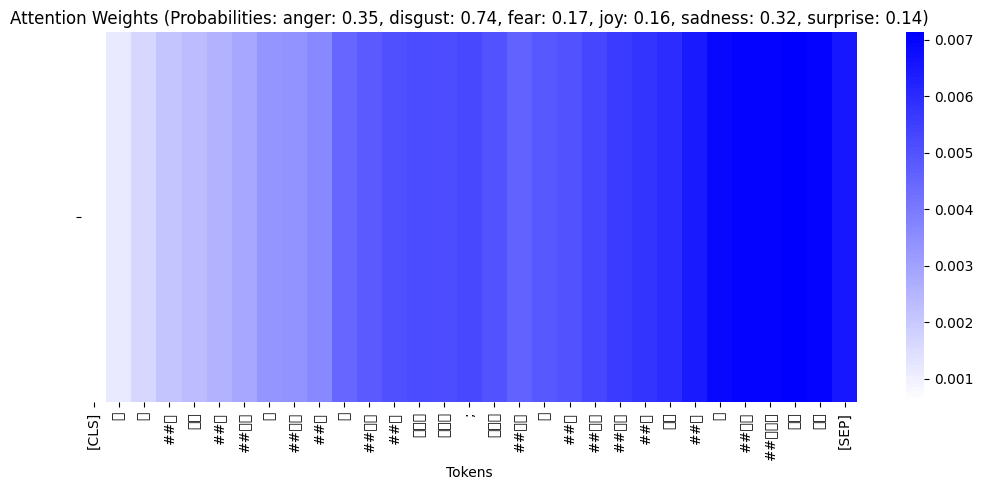


Analyzing sample text for interpretability (LIME):
Text: Circus clown wallpaper, circus clown figurines, paintings of circus clowns, small statues of circus clowns.
Target emotion: fear

Explanation for anger:
  of: 0.0244
  clown: -0.0237
  statues: 0.0106
  paintings: 0.0081
  figurines: 0.0078
  clowns: -0.0053
  small: 0.0052
  wallpaper: -0.0035
  circus: -0.0029
  Circus: -0.0027

Explanation for disgust:
  of: -0.0244
  clown: 0.0237
  statues: -0.0106
  paintings: -0.0081
  figurines: -0.0078
  clowns: 0.0053
  small: -0.0052
  wallpaper: 0.0035
  circus: 0.0029
  Circus: 0.0027

Explanation for fear:
  small: 0.0044
  statues: 0.0040
  wallpaper: 0.0026
  of: -0.0017
  Circus: 0.0013
  circus: 0.0011
  clowns: 0.0008
  clown: -0.0007
  figurines: 0.0006
  paintings: 0.0003

Explanation for joy:
  small: -0.0044
  statues: -0.0040
  wallpaper: -0.0026
  of: 0.0017
  Circus: -0.0013
  circus: -0.0011
  clowns: -0.0008
  clown: 0.0007
  figurines: -0.0006
  paintings: -0.0003

E

<Figure size 1000x400 with 0 Axes>

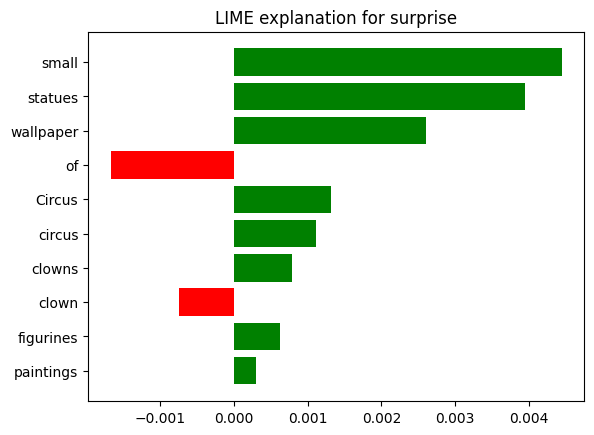


Visualizing attention weights:


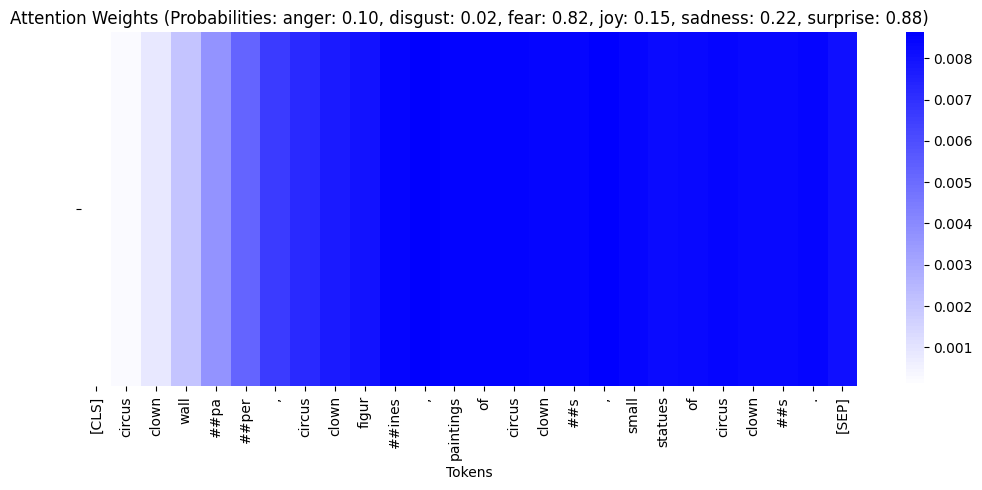


Analyzing sample text for interpretability (LIME):
Text: Block Island holds a very special place in my heart.
Target emotion: joy

Explanation for anger:
  my: 0.0128
  heart: 0.0085
  place: 0.0064
  special: -0.0029
  Island: 0.0027
  holds: -0.0026
  Block: 0.0024
  very: 0.0021
  a: 0.0012
  in: -0.0000

Explanation for disgust:
  my: -0.0128
  heart: -0.0085
  place: -0.0064
  special: 0.0029
  Island: -0.0027
  holds: 0.0026
  Block: -0.0024
  very: -0.0021
  a: -0.0012
  in: 0.0000

Explanation for fear:
  heart: -0.0088
  very: -0.0063
  place: 0.0031
  Block: 0.0029
  Island: -0.0023
  my: 0.0017
  special: 0.0014
  holds: -0.0007
  a: -0.0004
  in: 0.0001

Explanation for joy:
  heart: 0.0088
  very: 0.0063
  place: -0.0031
  Block: -0.0029
  Island: 0.0023
  my: -0.0017
  special: -0.0014
  holds: 0.0007
  a: 0.0004
  in: -0.0001

Explanation for sadness:
  heart: 0.0350
  very: 0.0310
  Island: 0.0221
  my: 0.0199
  a: 0.0161
  holds: 0.0156
  place: 0.0145
  Block: -0.014

<Figure size 1000x400 with 0 Axes>

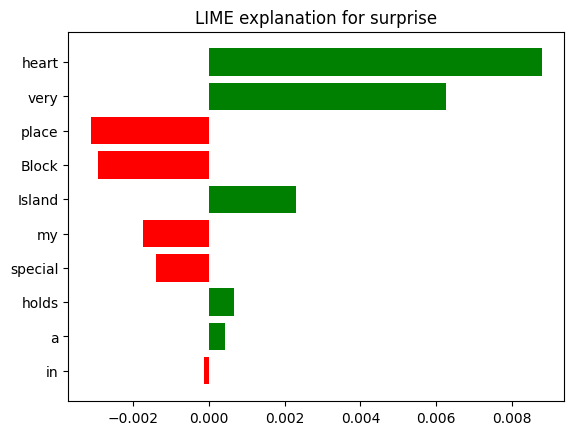


Visualizing attention weights:


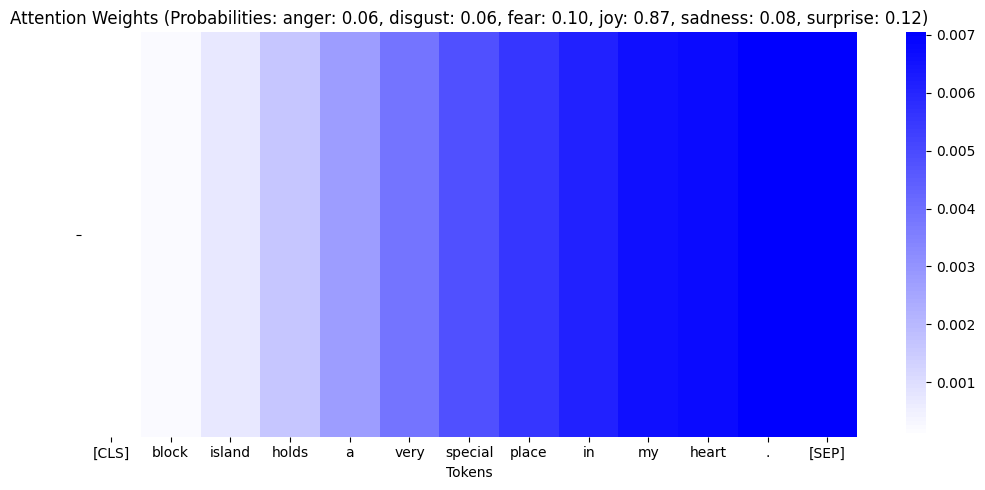


Analyzing sample text for interpretability (LIME):
Text: आज हवामान स्नॉर्कलिंगसाठी योग्य नसल्यामुळे मी निराश आहे.
Target emotion: sadness

Explanation for anger:
  य: -0.0298
  नसल: -0.0287
  न: 0.0262
  आह: -0.0258
  श: -0.0231
  ठ: 0.0216
  र: 0.0142
  म: -0.0137
  कल: -0.0095
  ग: 0.0079

Explanation for disgust:
  य: 0.0298
  नसल: 0.0287
  न: -0.0262
  आह: 0.0258
  श: 0.0231
  ठ: -0.0216
  र: -0.0142
  म: 0.0137
  कल: 0.0095
  ग: -0.0079

Explanation for fear:
  आह: -0.0232
  न: 0.0175
  य: -0.0154
  ळ: -0.0146
  ठ: 0.0136
  नसल: -0.0134
  हव: -0.0074
  ग: -0.0070
  श: 0.0059
  आज: -0.0052

Explanation for joy:
  आह: 0.0232
  न: -0.0175
  य: 0.0154
  ळ: 0.0146
  ठ: -0.0136
  नसल: 0.0134
  हव: 0.0074
  ग: 0.0070
  श: -0.0059
  आज: 0.0052

Explanation for sadness:
  न: -0.0435
  य: -0.0245
  ळ: -0.0139
  र: 0.0125
  आज: 0.0113
  नसल: -0.0112
  म: -0.0088
  श: 0.0063
  हव: -0.0060
  ठ: 0.0056

Explanation for surprise:
  न: 0.0435
  य: 0.0245
  ळ: 0.0139
  र: -0.0125
  आज: -0.0113
  

<Figure size 1000x400 with 0 Axes>

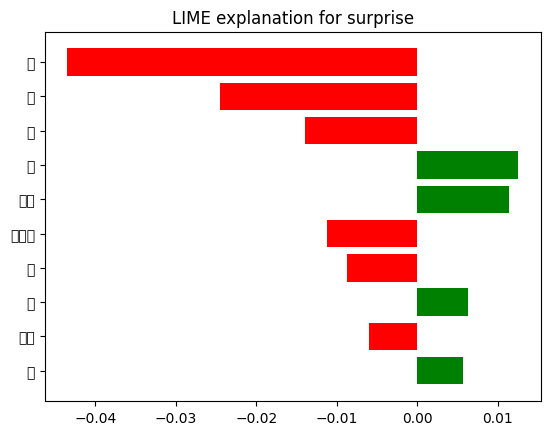


Visualizing attention weights:


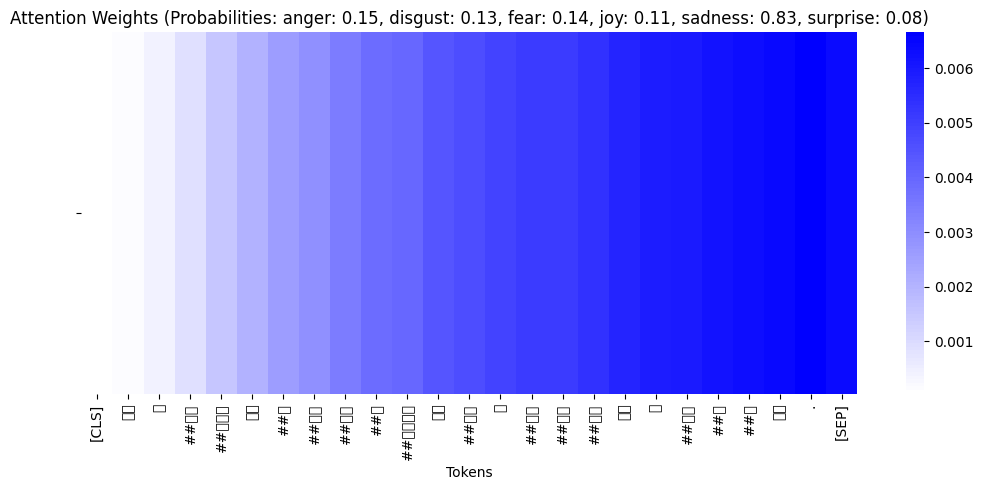


Testing model for: en_focal

Testing with example texts:

Text: After we were done, I could barely even move my fingers and I think I am going to be sick in a few days.
Predicted emotions: [0 1 0 1 0]
Probabilities:
  anger: 0.1817
  fear: 0.8003
  joy: 0.1435
  sadness: 0.7561
  surprise: 0.1488
Detected emotions: fear, sadness

Text: I have major slip ups, like, letting the wrong person close to my heart and getting burned.
Predicted emotions: [0 1 0 1 0]
Probabilities:
  anger: 0.3848
  fear: 0.6983
  joy: 0.1586
  sadness: 0.7263
  surprise: 0.1523
Detected emotions: fear, sadness

Text: I got my first raspberry from a crowd surfer falling and my face hitting the monitor, battle wounds.
Predicted emotions: [0 1 0 0 1]
Probabilities:
  anger: 0.4333
  fear: 0.7173
  joy: 0.2062
  sadness: 0.4831
  surprise: 0.7105
Detected emotions: fear, surprise

Text: I hung my head in shame, feeling like the lowest of mothers.
Predicted emotions: [0 0 0 1 0]
Probabilities:
  anger: 0.3659
  fea

In [25]:
# Main execution
if __name__ == "__main__":  # Check main execution
    print("Ensure all required packages are installed: torch, transformers, pandas, numpy, sklearn, matplotlib, seaborn, tqdm, lime")  # Log package requirement
    print("Run in Google Colab with GPU enabled for best performance.")  # Log runtime suggestion

    languages = ['en', 'hi', 'mr']  # Define languages
    loss_functions_en = ['focal', 'weighted_bce', 'asymmetric_focal']  # Define English losses
    loss_functions_multi = ['focal', 'weighted_bce', 'comet']  # Define multilingual losses

    models = {}  # Initialize models dictionary

    # Train separate model for English
    for loss_type in loss_functions_en:  # Iterate English losses
        model_results = train_and_evaluate(  # Train model
            language='en',
            model_name="distilbert-base-uncased",  # Set model name
            num_epochs=5,  # Set epochs
            batch_size=16,  # Set batch size
            learning_rate=2e-5,  # Set learning rate
            loss_type=loss_type  # Set loss type
        )
        if model_results:  # Check results
            models[f'en_{loss_type}'] = model_results  # Store model

    # Train multilingual model for Hindi and Marathi
    for loss_type in loss_functions_multi:  # Iterate multilingual losses
        model_results = train_multilingual(  # Train model
            languages=['hi', 'mr'],  # Set languages
            model_name="bert-base-multilingual-uncased",  # Set model name
            num_epochs=5,  # Set epochs
            batch_size=16,  # Set batch size
            learning_rate=2e-5,  # Set learning rate
            loss_type=loss_type  # Set loss type
        )
        if model_results:  # Check results
            models[f'multilingual_{loss_type}'] = model_results  # Store model

    for key, (model, tokenizer, test_df, emotion_labels) in models.items():  # Iterate models
        print(f"\n{'='*50}")  # Print separator
        print(f"Testing model for: {key}")  # Log model key
        print(f"{'='*50}")  # Print separator

        # MODIFIED: Sample native texts for multilingual models to ensure Devanagari for Hindi
        if key.startswith('multilingual'):  # Check multilingual model
            # Try to sample non-tagged (native Hindi/Marathi) texts first
            native_df = test_df[~test_df['text'].str.startswith('[hi]') & ~test_df['text'].str.startswith('[mr]')]  # Filter native texts
            if len(native_df) >= 5:  # Check enough texts
                sample_texts = native_df['text'].sample(5, random_state=42).values  # Sample texts
            else:  # Not enough texts
                print(f"Warning: Not enough native texts for {key}. Using mixed sampling.")  # Log warning
                sample_texts = test_df['text'].sample(5, random_state=42).values  # Sample mixed texts
        else:  # English model
            sample_texts = test_df['text'].sample(5, random_state=42).values  # Sample texts

        print("\nTesting with example texts:")  # Log testing
        for text in sample_texts:  # Iterate texts
            encoding = tokenizer(  # Encode text
                text,
                add_special_tokens=True,  # Add special tokens
                max_length=128,  # Set max length
                padding='max_length',  # Pad to max length
                truncation=True,  # Truncate if needed
                return_attention_mask=True,  # Return attention mask
                return_tensors='pt'  # Return tensors
            )

            input_ids = encoding['input_ids'].to(device)  # Get input IDs
            attention_mask = encoding['attention_mask'].to(device)  # Get attention mask

            model.eval()  # Set evaluation mode
            with torch.no_grad():  # Disable gradients
                outputs = model(input_ids=input_ids, attention_mask=attention_mask)  # Forward pass
                probs = torch.sigmoid(outputs).cpu().numpy()[0]  # Compute probabilities
                preds = (probs >= 0.5).astype(int)  # Binarize predictions

            print(f"\nText: {text}")  # Log text
            print(f"Predicted emotions: {preds}")  # Log predictions
            print("Probabilities:")  # Log probabilities
            for emotion, prob in zip(emotion_labels, probs):  # Iterate emotions
                print(f"  {emotion}: {prob:.4f}")  # Log probability

            detected = [emotion_labels[i] for i, p in enumerate(preds) if p == 1]  # Get detected emotions
            if detected:  # Check detected emotions
                print(f"Detected emotions: {', '.join(detected)}")  # Log detected emotions
            else:  # No emotions
                print("No emotions detected.")  # Log no emotions

    print("\nProject completed successfully!")  # Log completion